In [1]:
import sys
import os
import random
# Compute the project root directory (adjust the number of ".." as needed)
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

import pandas as pd
from src.timeseries.preprocessing.preprocessing import DatasetInfo, TimeSeriesMissingHandler, convert_row_df_to_column_df
from src.timeseries.preprocessing.data_loader import convert_tsf_to_dataframe

In [2]:
DATA_DIR = "../data/"
RAW_DATASETS_DIR = DATA_DIR + "raw_datasets/"

dataset_info = DatasetInfo()

# Housing

**Dataset Summary:**  
This dataset explores supply and demand factors influencing US home prices over the past 20 years, split into two files: Supply and Demand. Data includes metrics like housing permits, interest rates, and consumer sentiment.  

### Features - Supply:  
- **DATE:** Date of observation.  
- **PERMIT:** Housing permits authorized (thousands, seasonally adjusted).  
- **MSACSR:** Monthly supply of new houses (seasonally adjusted).  
- **TLRESCONS:** Total residential construction spending (millions, seasonally adjusted).  
- **EVACANTUSQ176N:** Vacant housing inventory estimate (thousands, not seasonally adjusted).  
- **CSUSHPISA:** Home price index (indexed, seasonally adjusted).  

### Features - Demand:  
- **DATE:** Date of observation.  
- **INTDSRUSM193N:** Interest rates for the US (billions, seasonally adjusted).  
- **UMCSENT:** Consumer sentiment (University of Michigan).  
- **GDP:** Gross domestic product (billions, seasonally adjusted).  
- **MORTGAGE15US:** Average 30-year fixed mortgage rate (%).  
- **CSUSHPISA:** Home price index (indexed, seasonally adjusted).  
- **MSPUS:** Median house sales price (not seasonally adjusted).  

**Source:** [Kaggle - Factors Influencing House Prices in the US](https://www.kaggle.com/datasets/utkarshx27/factors-influence-house-price-in-us/data)  

In [13]:
demand = pd.read_csv(RAW_DATASETS_DIR + 'Housing/demand.csv')
supply = pd.read_csv(RAW_DATASETS_DIR + 'Housing/supply.csv')

In [14]:
demand.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 81 entries, 0 to 80
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   DATE           81 non-null     object 
 1   CSUSHPISA      80 non-null     float64
 2   MORTGAGE30US   81 non-null     float64
 3   UMCSENT        81 non-null     float64
 4   INTDSRUSM193N  74 non-null     float64
 5   MSPUS          81 non-null     int64  
 6   GDP            81 non-null     float64
dtypes: float64(5), int64(1), object(1)
memory usage: 4.6+ KB


In [15]:
supply.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 82 entries, 0 to 81
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   DATE            82 non-null     object
 1   CSUSHPISA       82 non-null     object
 2   MSACSR          82 non-null     object
 3   PERMIT          82 non-null     object
 4   TLRESCONS       82 non-null     object
 5   EVACANTUSQ176N  82 non-null     object
dtypes: object(6)
memory usage: 4.0+ KB


In [16]:
df = demand.merge(supply, on='DATE')
df.drop(columns=['CSUSHPISA_y'], inplace=True)
df.drop(index=80, inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 80 entries, 0 to 79
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   DATE            80 non-null     object 
 1   CSUSHPISA_x     80 non-null     float64
 2   MORTGAGE30US    80 non-null     float64
 3   UMCSENT         80 non-null     float64
 4   INTDSRUSM193N   74 non-null     float64
 5   MSPUS           80 non-null     int64  
 6   GDP             80 non-null     float64
 7   MSACSR          80 non-null     object 
 8   PERMIT          80 non-null     object 
 9   TLRESCONS       80 non-null     object 
 10  EVACANTUSQ176N  80 non-null     object 
dtypes: float64(5), int64(1), object(5)
memory usage: 7.0+ KB


In [17]:
df.rename(columns={'CSUSHPISA_x': 'CSUSHPISA', 'DATE': 'date'}, inplace=True)

TimeSeriesMissingHandler initialized. DataFrame shape: (80, 11)
Date column 'date' identified.

--- Missing Value Analysis ---
Columns with missing values (%):
- INTDSRUSM193N: 7.50% (6 values)

Displaying Missing Value Heatmap...


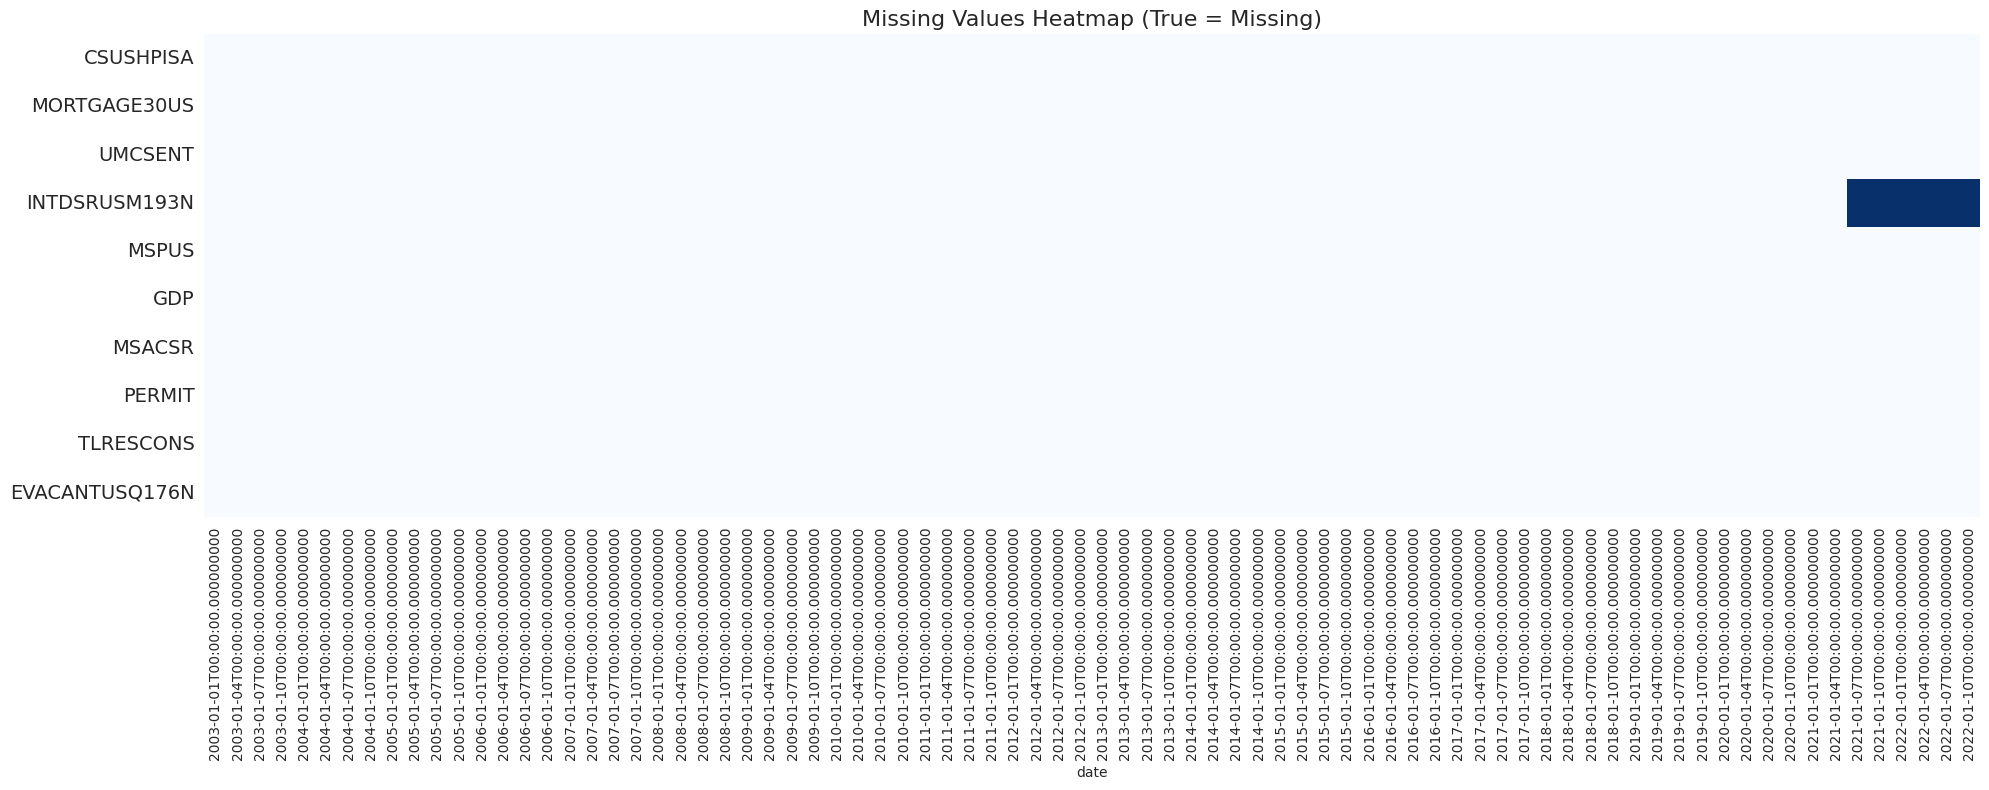

--- End of Analysis ---



In [18]:
missing_handler = TimeSeriesMissingHandler(df)
missing_handler.base_analysis()

In [19]:
df.dropna(axis=0, inplace=True)

In [20]:
dataset_info.add_dataset('housing', 'economic', df, ['CSUSHPISA', 'MSPUS'], date_format='%d-%m-%Y')

Processed DataFrame saved to: /workspaces/foundation-covariate-forecasting/data/prepared_datasets/housing.csv


,dataset_name,domain,granularity,ts_length,num_ts,ts_names,targets,num_targets,past_covariates,num_past_covariates,future_covariates,num_future_covariates,categorical_covariates,num_categorical_covariates
0,housing,economic,QS-OCT,74,1,[_single_series_],"[CSUSHPISA, MSPUS]",2,"[EVACANTUSQ176N, GDP, INTDSRUSM193N, MORTGAGE3...",8,[],0,[],0


# Electricity


**Dataset Summary:**  
This dataset examines electricity demand and pricing in Victoria, Australia, from January 2015 to October 2020. It includes weather, pricing, and demand metrics, capturing variations like negative retail prices and pandemic effects.  

### Features:  
- **date:** Date of observation (datetime).  
- **demand:** Total daily electricity demand (MWh).  
- **RRP:** Recommended retail price (AUD$/MWh).  
- **demand_pos_RRP:** Daily demand at positive RRP (MWh).  
- **RRP_positive:** Weighted average of positive RRP (AUD$/MWh).  
- **demand_neg_RRP:** Daily demand at negative RRP (MWh).  
- **RRP_negative:** Weighted average of negative RRP (AUD$/MWh).  
- **frac_at_neg_RRP:** Fraction of the day with demand traded at negative RRP.  
- **min_temperature:** Minimum daily temperature (°C).  
- **max_temperature:** Maximum daily temperature (°C).  
- **solar_exposure:** Total daily sunlight energy (MJ/m²).  
- **rainfall:** Daily rainfall (mm).  
- **school_day:** Indicates if students attended school (boolean).  
- **holiday:** Indicates if the day was a holiday (boolean).  

**Source:** [Kaggle - Electricity Demand in Victoria, Australia](https://www.kaggle.com/datasets/aramacus/electricity-demand-in-victoria-australia)  

In [21]:
df = pd.read_csv(RAW_DATASETS_DIR  + 'Electricity/complete_dataset.csv')
df.head()

,date,demand,RRP,demand_pos_RRP,RRP_positive,demand_neg_RRP,RRP_negative,frac_at_neg_RRP,min_temperature,max_temperature,solar_exposure,rainfall,school_day,holiday
0,2015-01-01,99635.030,25.633696,97319.240,26.415953,2315.790,-7.240000,0.020833,13.3,26.9,23.6,0.0,N,Y
1,2015-01-02,129606.010,33.138988,121082.015,38.837661,8523.995,-47.809777,0.062500,15.4,38.8,26.8,0.0,N,N
2,2015-01-03,142300.540,34.564855,142300.540,34.564855,0.000,0.000000,0.000000,20.0,38.2,26.5,0.0,N,N
3,2015-01-04,104330.715,25.005560,104330.715,25.005560,0.000,0.000000,0.000000,16.3,21.4,25.2,4.2,N,N
4,2015-01-05,118132.200,26.724176,118132.200,26.724176,0.000,0.000000,0.000000,15.0,22.0,30.7,0.0,N,N


In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2106 entries, 0 to 2105
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   date             2106 non-null   object 
 1   demand           2106 non-null   float64
 2   RRP              2106 non-null   float64
 3   demand_pos_RRP   2106 non-null   float64
 4   RRP_positive     2106 non-null   float64
 5   demand_neg_RRP   2106 non-null   float64
 6   RRP_negative     2106 non-null   float64
 7   frac_at_neg_RRP  2106 non-null   float64
 8   min_temperature  2106 non-null   float64
 9   max_temperature  2106 non-null   float64
 10  solar_exposure   2105 non-null   float64
 11  rainfall         2103 non-null   float64
 12  school_day       2106 non-null   object 
 13  holiday          2106 non-null   object 
dtypes: float64(11), object(3)
memory usage: 230.5+ KB


In [23]:
df['school_day'] = df['school_day'].replace({'N': 0, 'Y': 1})
df['holiday'] = df['holiday'].replace({'N': 0, 'Y': 1})

/tmp/ipykernel_1736/508363664.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['school_day'] = df['school_day'].replace({'N': 0, 'Y': 1})
/tmp/ipykernel_1736/508363664.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['holiday'] = df['holiday'].replace({'N': 0, 'Y': 1})


TimeSeriesMissingHandler initialized. DataFrame shape: (2106, 14)
Date column 'date' identified.

--- Missing Value Analysis ---
Columns with missing values (%):
- rainfall: 0.14% (3 values)
- solar_exposure: 0.05% (1 values)

Displaying Missing Value Heatmap...


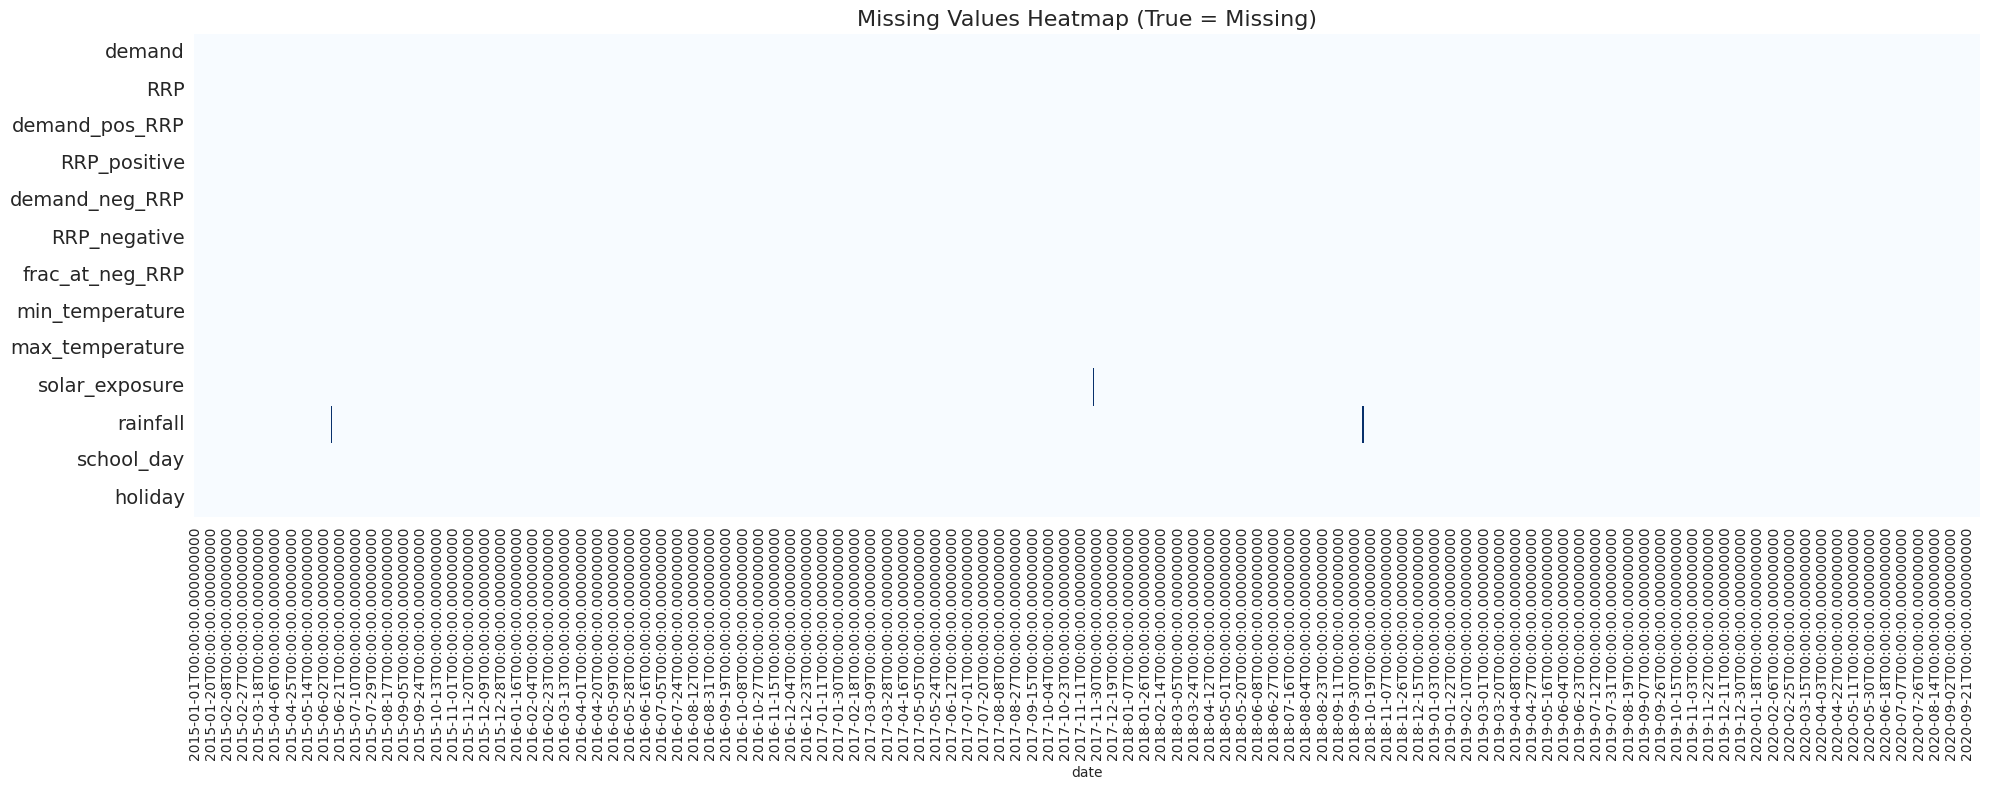

--- End of Analysis ---



In [24]:
missing_handler = TimeSeriesMissingHandler(df)
missing_handler.base_analysis()

In [25]:
missing_handler.apply_imputation('ffill')
df = missing_handler.processed_df


--- Applying Imputation ---
Applying single strategy 'ffill' to all data columns.
  Column 'demand' has no missing values. Skipping.
  Column 'RRP' has no missing values. Skipping.
  Column 'demand_pos_RRP' has no missing values. Skipping.
  Column 'RRP_positive' has no missing values. Skipping.
  Column 'demand_neg_RRP' has no missing values. Skipping.
  Column 'RRP_negative' has no missing values. Skipping.
  Column 'frac_at_neg_RRP' has no missing values. Skipping.
  Column 'min_temperature' has no missing values. Skipping.
  Column 'max_temperature' has no missing values. Skipping.
  Applying method 'ffill' to column 'solar_exposure'...
    Filled using forward fill.
  Applying method 'ffill' to column 'rainfall'...
    Filled using forward fill.
  Column 'school_day' has no missing values. Skipping.
  Column 'holiday' has no missing values. Skipping.
--- Imputation Complete ---



/workspaces/foundation-covariate-forecasting/src/timeseries/preprocessing/preprocessing.py:782: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  self.df[col_name].ffill(inplace=True)


In [26]:
dataset_info.add_dataset('electricity', 'energy', df, ['demand', 'RRP'], future_covariates=['school_day', 'holiday'], categorical_covariates=['school_day', 'holiday'])

Processed DataFrame saved to: /workspaces/foundation-covariate-forecasting/data/prepared_datasets/electricity.csv


,dataset_name,domain,granularity,ts_length,num_ts,ts_names,targets,num_targets,past_covariates,num_past_covariates,future_covariates,num_future_covariates,categorical_covariates,num_categorical_covariates
0,housing,economic,QS-OCT,74,1,[_single_series_],"[CSUSHPISA, MSPUS]",2,"[EVACANTUSQ176N, GDP, INTDSRUSM193N, MORTGAGE3...",8,[],0,[],0
1,electricity,energy,D,2106,1,[_single_series_],"[RRP, demand]",2,"[RRP_negative, RRP_positive, demand_neg_RRP, d...",9,"[school_day, holiday]",2,"[school_day, holiday]",2


# Bikesharing


**Dataset Summary:**  
This dataset explores the factors influencing hourly bike rentals in Seoul, considering weather conditions, seasonal variations, and operational factors. It provides insight into the relationship between environmental factors and rental demand.  

### Features:  
- **Rented Bike Count:** Number of bikes rented per hour.  
- **Temperature(°C):** Hourly temperature in Celsius.  
- **Humidity(%):** Hourly humidity percentage.  
- **Wind speed (m/s):** Hourly wind speed in meters per second.  
- **Visibility (10m):** Visibility level (measured in units of 10 meters).  
- **Dew point temperature(°C):** Hourly dew point temperature in Celsius.  
- **Solar Radiation (MJ/m²):** Hourly solar radiation energy (MJ/m²).  
- **Rainfall(mm):** Hourly rainfall in millimeters.  
- **Snowfall (cm):** Hourly snowfall in centimeters.  
- **Seasons:** Season indicator (Spring, Summer, Autumn, Winter).  
- **Holiday:** Indicates if the day is a holiday (boolean).  
- **Functioning Day:** Indicates if bike-sharing services operated that day (boolean).  
- **date:** Date of observation.  

**Source:** [Kaggle - Seoul Bike Sharing Demand Prediction](https://www.kaggle.com/datasets/saurabhshahane/seoul-bike-sharing-demand-prediction)  

In [27]:
df = pd.read_csv(RAW_DATASETS_DIR + 'Bikesharing/SeoulBikeData.csv', encoding= 'latin1')
df.head()

,Date,Rented Bike Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day
0,01/12/2017,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
1,01/12/2017,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
2,01/12/2017,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes
3,01/12/2017,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
4,01/12/2017,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,Yes


In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Date                       8760 non-null   object 
 1   Rented Bike Count          8760 non-null   int64  
 2   Hour                       8760 non-null   int64  
 3   Temperature(°C)            8760 non-null   float64
 4   Humidity(%)                8760 non-null   int64  
 5   Wind speed (m/s)           8760 non-null   float64
 6   Visibility (10m)           8760 non-null   int64  
 7   Dew point temperature(°C)  8760 non-null   float64
 8   Solar Radiation (MJ/m2)    8760 non-null   float64
 9   Rainfall(mm)               8760 non-null   float64
 10  Snowfall (cm)              8760 non-null   float64
 11  Seasons                    8760 non-null   object 
 12  Holiday                    8760 non-null   object 
 13  Functioning Day            8760 non-null   objec

In [29]:
df['DateTime'] = pd.to_datetime(df['Date'] + ' ' + df['Hour'].astype(str) + ':00', format='%d/%m/%Y %H:%M')
df.drop(['Date', 'Hour'], axis=1, inplace=True)
df.head()

,Rented Bike Count,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day,DateTime
0,254,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes,2017-12-01 00:00:00
1,204,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes,2017-12-01 01:00:00
2,173,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes,2017-12-01 02:00:00
3,107,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes,2017-12-01 03:00:00
4,78,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,Yes,2017-12-01 04:00:00


In [30]:
df['Seasons'].unique()

array(['Winter', 'Spring', 'Summer', 'Autumn'], dtype=object)

In [31]:
df['Holiday'].unique()

array(['No Holiday', 'Holiday'], dtype=object)

In [32]:
df['Functioning Day'].unique()

array(['Yes', 'No'], dtype=object)

In [33]:
df['Functioning Day'] = df['Functioning Day'].replace({'No': 0, 'Yes': 1})
df['Holiday'] = df['Holiday'].replace({'No Holiday': 0, 'Holiday': 1})
df['Seasons'] = df['Seasons'].replace({'Winter': 0, 'Spring': 1, 'Summer': 2, 'Autumn': 3})
df

/tmp/ipykernel_1736/480944707.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Functioning Day'] = df['Functioning Day'].replace({'No': 0, 'Yes': 1})
/tmp/ipykernel_1736/480944707.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Holiday'] = df['Holiday'].replace({'No Holiday': 0, 'Holiday': 1})
/tmp/ipykernel_1736/480944707.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt

,Rented Bike Count,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day,DateTime
0,254,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,0,0,1,2017-12-01 00:00:00
1,204,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,0,0,1,2017-12-01 01:00:00
2,173,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,0,0,1,2017-12-01 02:00:00
3,107,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,0,0,1,2017-12-01 03:00:00
4,78,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,0,0,1,2017-12-01 04:00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...
8755,1003,4.2,34,2.6,1894,-10.3,0.0,0.0,0.0,3,0,1,2018-11-30 19:00:00
8756,764,3.4,37,2.3,2000,-9.9,0.0,0.0,0.0,3,0,1,2018-11-30 20:00:00
8757,694,2.6,39,0.3,1968,-9.9,0.0,0.0,0.0,3,0,1,2018-11-30 21:00:00
8758,712,2.1,41,1.0,1859,-9.8,0.0,0.0,0.0,3,0,1,2018-11-30 22:00:00


In [34]:
df.rename(columns={'DateTime': 'date'}, inplace=True)

In [35]:
dataset_info.add_dataset('bike_sharing', 'human', df, ['Rented Bike Count'], future_covariates=['Seasons', 'Holiday', 'Functioning Day'], categorical_covariates=['Seasons', 'Holiday', 'Functioning Day'])

Processed DataFrame saved to: /workspaces/foundation-covariate-forecasting/data/prepared_datasets/bike_sharing.csv


,dataset_name,domain,granularity,ts_length,num_ts,ts_names,targets,num_targets,past_covariates,num_past_covariates,future_covariates,num_future_covariates,categorical_covariates,num_categorical_covariates
0,housing,economic,QS-OCT,74,1,[_single_series_],"[CSUSHPISA, MSPUS]",2,"[EVACANTUSQ176N, GDP, INTDSRUSM193N, MORTGAGE3...",8,[],0,[],0
1,electricity,energy,D,2106,1,[_single_series_],"[RRP, demand]",2,"[RRP_negative, RRP_positive, demand_neg_RRP, d...",9,"[school_day, holiday]",2,"[school_day, holiday]",2
2,bike_sharing,human,h,8760,1,[_single_series_],[Rented Bike Count],1,"[Dew point temperature(°C), Humidity(%), Rainf...",8,"[Seasons, Holiday, Functioning Day]",3,"[Seasons, Holiday, Functioning Day]",3


# Energy

**Dataset Summary:**  
This dataset provides hourly data on Spain's electricity consumption, generation, pricing, and weather over four years. It supports analysis of energy trends, renewable adoption, and forecasting challenges in energy markets.  

### Features - Energy Generation:  
- **generation_biomass:** Electricity from biomass generation (MW).  
- **generation_fossil_brown_coal/lignite:** Fossil generation via brown coal/lignite (MW).  
- **generation_fossil_coal_derived_gas:** Fossil generation via coal-derived gas (MW).  
- **generation_fossil_gas:** Fossil generation via natural gas (MW).  
- **generation_fossil_hard_coal:** Fossil generation via hard coal (MW).  
- **generation_fossil_oil:** Fossil generation via oil (MW).  
- **generation_fossil_oil_shale:** Fossil generation via oil shale (MW).  
- **generation_fossil_peat:** Fossil generation via peat (MW).  
- **generation_geothermal:** Electricity from geothermal sources (MW).  
- **generation_hydro_pumped_storage_consumption:** Hydro storage consumption (MW).  
- **generation_hydro_run_of_river_and_poundage:** Hydro run-of-river generation (MW).  
- **generation_hydro_water_reservoir:** Hydro reservoir generation (MW).  
- **generation_marine:** Electricity from marine sources (MW).  
- **generation_nuclear:** Electricity from nuclear generation (MW).  
- **generation_other:** Miscellaneous electricity sources (MW).  
- **generation_other_renewable:** Renewable sources excluding standard categories (MW).  
- **generation_solar:** Solar power generation (MW).  
- **generation_waste:** Energy from waste (MW).  
- **generation_wind_offshore:** Offshore wind generation (MW).  
- **generation_wind_onshore:** Onshore wind generation (MW).  

### Features - Energy Demand and Pricing:  
- **total_load_actual:** Actual total electrical load (MW).  
- **price_actual:** Actual market price (EUR/MWh).  
- **date:** Date and time of observation.  

**Source:** [Kaggle - Energy Consumption, Generation, Prices, and Weather](https://www.kaggle.com/datasets/nicholasjhana/energy-consumption-generation-prices-and-weather)  

In [36]:
df = pd.read_csv(RAW_DATASETS_DIR + 'Energy/energy_dataset.csv')
df.head()

,time,generation biomass,generation fossil brown coal/lignite,generation fossil coal-derived gas,generation fossil gas,generation fossil hard coal,generation fossil oil,generation fossil oil shale,generation fossil peat,generation geothermal,...,generation waste,generation wind offshore,generation wind onshore,forecast solar day ahead,forecast wind offshore eday ahead,forecast wind onshore day ahead,total load forecast,total load actual,price day ahead,price actual
0,2015-01-01 00:00:00+01:00,447.0,329.0,0.0,4844.0,4821.0,162.0,0.0,0.0,0.0,...,196.0,0.0,6378.0,17.0,NaN,6436.0,26118.0,25385.0,50.10,65.41
1,2015-01-01 01:00:00+01:00,449.0,328.0,0.0,5196.0,4755.0,158.0,0.0,0.0,0.0,...,195.0,0.0,5890.0,16.0,NaN,5856.0,24934.0,24382.0,48.10,64.92
2,2015-01-01 02:00:00+01:00,448.0,323.0,0.0,4857.0,4581.0,157.0,0.0,0.0,0.0,...,196.0,0.0,5461.0,8.0,NaN,5454.0,23515.0,22734.0,47.33,64.48
3,2015-01-01 03:00:00+01:00,438.0,254.0,0.0,4314.0,4131.0,160.0,0.0,0.0,0.0,...,191.0,0.0,5238.0,2.0,NaN,5151.0,22642.0,21286.0,42.27,59.32
4,2015-01-01 04:00:00+01:00,428.0,187.0,0.0,4130.0,3840.0,156.0,0.0,0.0,0.0,...,189.0,0.0,4935.0,9.0,NaN,4861.0,21785.0,20264.0,38.41,56.04


In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35064 entries, 0 to 35063
Data columns (total 29 columns):
 #   Column                                       Non-Null Count  Dtype  
---  ------                                       --------------  -----  
 0   time                                         35064 non-null  object 
 1   generation biomass                           35045 non-null  float64
 2   generation fossil brown coal/lignite         35046 non-null  float64
 3   generation fossil coal-derived gas           35046 non-null  float64
 4   generation fossil gas                        35046 non-null  float64
 5   generation fossil hard coal                  35046 non-null  float64
 6   generation fossil oil                        35045 non-null  float64
 7   generation fossil oil shale                  35046 non-null  float64
 8   generation fossil peat                       35046 non-null  float64
 9   generation geothermal                        35046 non-null  float64
 10

In [38]:
df.columns = df.columns.str.replace(' ','_').str.replace('-','_')

In [39]:
df.drop(columns=['forecast_wind_offshore_eday_ahead',
                 'generation_hydro_pumped_storage_aggregated'], inplace=True)

In [40]:
df['time'] = pd.to_datetime(df['time'], utc=True)
df['date'] = df['time'].dt.tz_localize(None)
df.drop(columns=['time'], inplace=True)

In [41]:
missing_handler = TimeSeriesMissingHandler(df)
missing_handler.base_analysis(heatmap=False)

TimeSeriesMissingHandler initialized. DataFrame shape: (35064, 27)
Date column 'date' identified.

--- Missing Value Analysis ---
Columns with missing values (%):
- total_load_actual: 0.10% (36 values)
- generation_fossil_oil: 0.05% (19 values)
- generation_waste: 0.05% (19 values)
- generation_marine: 0.05% (19 values)
- generation_hydro_pumped_storage_consumption: 0.05% (19 values)
- generation_biomass: 0.05% (19 values)
- generation_hydro_run_of_river_and_poundage: 0.05% (19 values)
- generation_fossil_oil_shale: 0.05% (18 values)
- generation_fossil_peat: 0.05% (18 values)
- generation_geothermal: 0.05% (18 values)
- generation_fossil_hard_coal: 0.05% (18 values)
- generation_fossil_brown_coal/lignite: 0.05% (18 values)
- generation_hydro_water_reservoir: 0.05% (18 values)
- generation_fossil_gas: 0.05% (18 values)
- generation_other: 0.05% (18 values)
- generation_other_renewable: 0.05% (18 values)
- generation_solar: 0.05% (18 values)
- generation_fossil_coal_derived_gas: 0.05% (

In [42]:
df[df.isnull().any(axis=1)]

,generation_biomass,generation_fossil_brown_coal/lignite,generation_fossil_coal_derived_gas,generation_fossil_gas,generation_fossil_hard_coal,generation_fossil_oil,generation_fossil_oil_shale,generation_fossil_peat,generation_geothermal,generation_hydro_pumped_storage_consumption,...,generation_waste,generation_wind_offshore,generation_wind_onshore,forecast_solar_day_ahead,forecast_wind_onshore_day_ahead,total_load_forecast,total_load_actual,price_day_ahead,price_actual,date
99,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,546.0,8233.0,21912.0,21182.0,35.20,59.68,2015-01-05 02:00:00
108,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,3932.0,9258.0,23209.0,NaN,35.50,79.14,2015-01-05 11:00:00
109,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,4236.0,9156.0,23725.0,NaN,36.80,73.95,2015-01-05 12:00:00
110,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,4215.0,9072.0,23614.0,NaN,32.50,71.93,2015-01-05 13:00:00
111,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,4050.0,8779.0,22381.0,NaN,30.00,71.50,2015-01-05 14:00:00
112,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,3728.0,8426.0,21371.0,NaN,30.00,71.85,2015-01-05 15:00:00
113,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,3175.0,7946.0,20760.0,NaN,30.60,80.53,2015-01-05 16:00:00
451,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,91.0,6434.0,38642.0,39304.0,70.01,88.95,2015-01-19 18:00:00
452,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,28.0,6907.0,38758.0,39262.0,69.00,87.94,2015-01-19 19:00:00
643,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,182.0,9807.0,38968.0,38335.0,66.00,83.97,2015-01-27 18:00:00


In [43]:
df = df[662:30895]
missing_handler = TimeSeriesMissingHandler(df)
missing_handler.apply_imputation('interpolate')
df = missing_handler.processed_df

TimeSeriesMissingHandler initialized. DataFrame shape: (30233, 27)
Date column 'date' identified.

--- Applying Imputation ---
Applying single strategy 'interpolate' to all data columns.
  Applying method 'interpolate' to column 'generation_biomass'...
    Filled using linear interpolation.
  Applying method 'interpolate' to column 'generation_fossil_brown_coal/lignite'...
    Filled using linear interpolation.
  Applying method 'interpolate' to column 'generation_fossil_coal_derived_gas'...
    Filled using linear interpolation.
  Applying method 'interpolate' to column 'generation_fossil_gas'...
    Filled using linear interpolation.
  Applying method 'interpolate' to column 'generation_fossil_hard_coal'...
    Filled using linear interpolation.
  Applying method 'interpolate' to column 'generation_fossil_oil'...
    Filled using linear interpolation.
  Applying method 'interpolate' to column 'generation_fossil_oil_shale'...
    Filled using linear interpolation.
  Applying method 'i

/workspaces/foundation-covariate-forecasting/src/timeseries/preprocessing/preprocessing.py:789: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  self.df[col_name].interpolate(method='linear', inplace=True)


In [44]:
dataset_info.add_dataset('energy', 'energy', df, ['total_load_actual', 'price_actual'], future_covariates=['price_day_ahead', 'total_load_forecast', 'forecast_solar_day_ahead', 'forecast_wind_onshore_day_ahead'])

Processed DataFrame saved to: /workspaces/foundation-covariate-forecasting/data/prepared_datasets/energy.csv


,dataset_name,domain,granularity,ts_length,num_ts,ts_names,targets,num_targets,past_covariates,num_past_covariates,future_covariates,num_future_covariates,categorical_covariates,num_categorical_covariates
0,housing,economic,QS-OCT,74,1,[_single_series_],"[CSUSHPISA, MSPUS]",2,"[EVACANTUSQ176N, GDP, INTDSRUSM193N, MORTGAGE3...",8,[],0,[],0
1,electricity,energy,D,2106,1,[_single_series_],"[RRP, demand]",2,"[RRP_negative, RRP_positive, demand_neg_RRP, d...",9,"[school_day, holiday]",2,"[school_day, holiday]",2
2,bike_sharing,human,h,8760,1,[_single_series_],[Rented Bike Count],1,"[Dew point temperature(°C), Humidity(%), Rainf...",8,"[Seasons, Holiday, Functioning Day]",3,"[Seasons, Holiday, Functioning Day]",3
3,energy,energy,h,30233,1,[_single_series_],"[price_actual, total_load_actual]",2,"[generation_biomass, generation_fossil_brown_c...",20,"[price_day_ahead, total_load_forecast, forecas...",4,[],0


# Bitcoin

**Dataset Summary:**
This dataset contains the potential influencers of the bitcoin price. There are a total of 18 daily time series including hash rate, block size, mining difficulty etc. It also encompasses public opinion in the form of tweets and google searches mentioning the keyword bitcoin. The data is scraped from the interactive web-graphs available at [https://bitinfocharts.com](https://bitinfocharts.com).

### Features:
- **date:** Date of observation.
- **active_addresses:** Number of active Bitcoin addresses.
- **av_transaction_value:** Average Bitcoin transaction value.
- **block_size:** Size of Bitcoin blocks.
- **confirmation_time:** Average Bitcoin transaction confirmation time.
- **difficulty:** Bitcoin mining difficulty.
- **fee_reward:** Bitcoin miner fee reward.
- **google_trends:** Google Trends search interest for "bitcoin".
- **hashrate:** Bitcoin network hash rate.
- **market_cap:** Bitcoin market capitalization.
- **median_transaction_size:** Median Bitcoin transaction size.
- **median_transaction_value:** Median Bitcoin transaction value.
- **mining_profitability:** Bitcoin mining profitability.
- **price:** Bitcoin price (USD).
- **send_usd:** Total USD value of Bitcoin sent.
- **sent_addresses:** Number of Bitcoin addresses sending transactions.
- **top_100_percent:** Percentage of total Bitcoin held by the top 100 addresses.
- **transactions:** Number of Bitcoin transactions.
- **tweets:** Number of tweets mentioning "bitcoin".

**Source:** [Zenodo - Monash University Bitcoin](https://zenodo.org/records/5122101)


In [45]:
loaded_data, frequency, forecast_horizon, contain_missing_values, contain_equal_length = convert_tsf_to_dataframe(RAW_DATASETS_DIR + 'Bitcoin/bitcoin_dataset_without_missing_values.tsf')

In [46]:
loaded_data

,series_name,start_timestamp,series_value
0,difficulty,2009-01-03,"[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ..."
1,sent_addresses,2009-01-09,"[1.0, 1.0, 1.0, 7.0, 10.0, 20.0, 18.0, 16.0, 1..."
2,send_usd,2010-07-17,"[1193.0, 2612.0, 4047.0, 2341.0, 2122.0, 2570...."
3,market_cap,2010-07-17,"[169839.0, 249761.0, 295981.0, 270546.0, 26590..."
4,confirmation_time,2009-01-09,"[102.857, 23.607, 15.484, 15.319, 11.707, 11.1..."
5,transactions,2009-01-12,"[7.0, 7.0, 1.0, 8.0, 2.0, 2.0, 1.0, 2.0, 1.0, ..."
6,median_transaction_size,2011-04-14,"[0.0097, 0.0097, 0.0097, 0.0097, 0.0097, 0.009..."
7,mining_profitability,2010-07-17,"[154298.0, 401834.0, 481473.0, 431831.0, 46078..."
8,fee_reward,2010-07-17,"[0.001, 0.0163, 0.00154, 0.00154, 0.00154, 0.0..."
9,top_100_percent,2009-01-09,"[100.0, 100.0, 59.524, 38.168, 25.974, 19.498,..."


In [47]:
frequency

'daily'

In [48]:
contain_missing_values

False

In [49]:
contain_equal_length

False

In [50]:
df = convert_row_df_to_column_df(loaded_data, frequency)

In [51]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4581 entries, 0 to 4580
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   date                      4581 non-null   datetime64[ns]
 1   active_addresses          4575 non-null   float64       
 2   av_transaction_value      4021 non-null   float64       
 3   block_size                4581 non-null   float64       
 4   confirmation_time         4575 non-null   float64       
 5   difficulty                4581 non-null   float64       
 6   fee_reward                4021 non-null   float64       
 7   google_trends             4199 non-null   float64       
 8   hashrate                  4575 non-null   float64       
 9   market_cap                4021 non-null   float64       
 10  median_transaction_size   3750 non-null   float64       
 11  median_transaction_value  4021 non-null   float64       
 12  mining_profitability

TimeSeriesMissingHandler initialized. DataFrame shape: (4581, 19)
Date column 'date' identified.

--- Missing Value Analysis ---
Columns with missing values (%):
- tweets: 41.96% (1922 values)
- median_transaction_size: 18.14% (831 values)
- av_transaction_value: 12.22% (560 values)
- fee_reward: 12.22% (560 values)
- market_cap: 12.22% (560 values)
- median_transaction_value: 12.22% (560 values)
- mining_profitability: 12.22% (560 values)
- price: 12.22% (560 values)
- send_usd: 12.22% (560 values)
- google_trends: 8.34% (382 values)
- transactions: 0.20% (9 values)
- active_addresses: 0.13% (6 values)
- confirmation_time: 0.13% (6 values)
- hashrate: 0.13% (6 values)
- sent_addresses: 0.13% (6 values)
- top_100_percent: 0.13% (6 values)

Displaying Missing Value Heatmap...


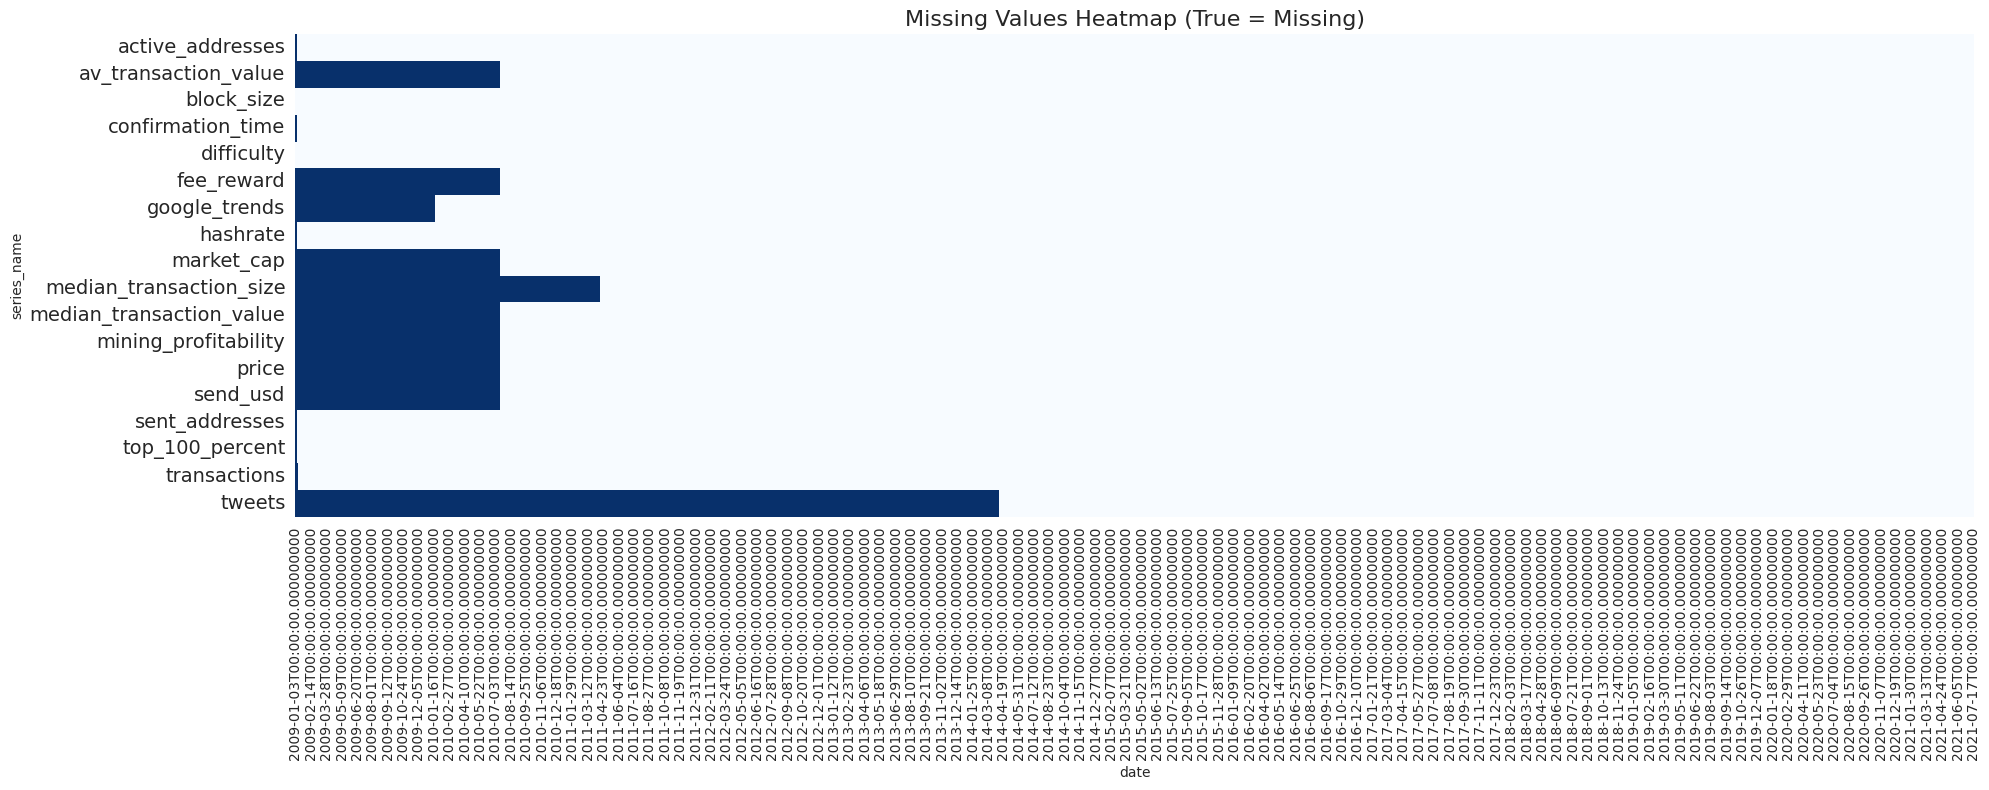

--- End of Analysis ---



In [52]:
missing_handler = TimeSeriesMissingHandler(df)
missing_handler.base_analysis()

In [53]:
missing_handler.trim_missing('start')
df = missing_handler.processed_df


Attempting to trim (how='start') based on threshold: >= 1 missing columns in data cols.
Trimming 1922 rows from the start.
Total rows trimmed: 1922
DataFrame shape after trimming: (2659, 19)


In [54]:
dataset_info.add_dataset('bitcoin', 'economic', df, ['price'])

Processed DataFrame saved to: /workspaces/foundation-covariate-forecasting/data/prepared_datasets/bitcoin.csv


,dataset_name,domain,granularity,ts_length,num_ts,ts_names,targets,num_targets,past_covariates,num_past_covariates,future_covariates,num_future_covariates,categorical_covariates,num_categorical_covariates
0,housing,economic,QS-OCT,74,1,[_single_series_],"[CSUSHPISA, MSPUS]",2,"[EVACANTUSQ176N, GDP, INTDSRUSM193N, MORTGAGE3...",8,[],0,[],0
1,electricity,energy,D,2106,1,[_single_series_],"[RRP, demand]",2,"[RRP_negative, RRP_positive, demand_neg_RRP, d...",9,"[school_day, holiday]",2,"[school_day, holiday]",2
2,bike_sharing,human,h,8760,1,[_single_series_],[Rented Bike Count],1,"[Dew point temperature(°C), Humidity(%), Rainf...",8,"[Seasons, Holiday, Functioning Day]",3,"[Seasons, Holiday, Functioning Day]",3
3,energy,energy,h,30233,1,[_single_series_],"[price_actual, total_load_actual]",2,"[generation_biomass, generation_fossil_brown_c...",20,"[price_day_ahead, total_load_forecast, forecas...",4,[],0
4,bitcoin,economic,D,2659,1,[_single_series_],[price],1,"[active_addresses, av_transaction_value, block...",17,[],0,[],0


# kdd cup air quality

**Dataset Summary:**  
This dataset records hourly air quality measurements from 35 stations in Beijing between January 2017 and March 2018. It provides insight into pollutants such as PM2.5, PM10, NO2, CO, O3, and SO2, facilitating air quality analysis and forecasting. Missing values were handled using the LOCF method.  

### Features:  
- **date:** Date and time of observation.  
- **station:** Name of the monitoring station.  
- **CO:** Carbon monoxide concentration (mg/m³).  
- **NO2:** Nitrogen dioxide concentration (µg/m³).  
- **O3:** Ozone concentration (µg/m³).  
- **PM10:** Particulate matter ≤10 µm (µg/m³).  
- **PM2.5:** Particulate matter ≤2.5 µm (µg/m³).  
- **SO2:** Sulfur dioxide concentration (µg/m³).  

**Source:** [Zenodo - KDD Cup 2018 Air Quality Dataset](https://zenodo.org/records/4656756)  

In [55]:
loaded_data, frequency, forecast_horizon, contain_missing_values, contain_equal_length = convert_tsf_to_dataframe(RAW_DATASETS_DIR + 'Air_Quality/kdd_cup_2018_dataset_without_missing_values.tsf')

In [56]:
loaded_data

,series_name,city,station,air_quality_measurement,start_timestamp,series_value
0,T1,Beijing,aotizhongxin_aq,PM2.5,2017-01-01 14:00:00,"[453.0, 417.0, 395.0, 420.0, 453.0, 429.0, 211..."
1,T2,Beijing,aotizhongxin_aq,PM10,2017-01-01 14:00:00,"[467.0, 443.0, 467.0, 484.0, 520.0, 520.0, 520..."
2,T3,Beijing,aotizhongxin_aq,NO2,2017-01-01 14:00:00,"[156.0, 143.0, 141.0, 139.0, 157.0, 141.0, 110..."
3,T4,Beijing,aotizhongxin_aq,CO,2017-01-01 14:00:00,"[7.2, 6.8, 6.9, 7.4, 7.6, 6.5, 3.3, 2.2, 1.3, ..."
4,T5,Beijing,aotizhongxin_aq,O3,2017-01-01 14:00:00,"[3.0, 2.0, 3.0, 3.0, 4.0, 3.0, 3.0, 4.0, 26.0,..."
...,...,...,...,...,...,...
265,T266,London,BX9,PM2.5,2017-01-01 00:00:01,"[23.3, 17.5, 16.6, 18.6, 20.4, 20.5, 21.2, 17...."
266,T267,London,KC1,PM2.5,2017-01-01 00:00:01,"[31.7, 29.9, 21.8, 19.1, 23.7, 25.7, 24.4, 20...."
267,T268,London,KC1,PM10,2017-01-01 00:00:01,"[23.2, 23.1, 13.9, 12.8, 13.8, 14.9, 15.1, 13...."
268,T269,London,KC1,NO2,2017-01-01 00:00:01,"[21.3, 25.9, 22.6, 23.4, 22.6, 24.9, 27.9, 30...."


In [57]:
frequency

'hourly'

In [58]:
contain_missing_values

False

In [59]:
contain_equal_length

False

In [60]:
loaded_data[loaded_data['city'] == 'London']['station'].value_counts()

station
CD1    3
CD9    3
KC1    3
BX1    3
RB7    3
CT3    3
HR1    3
LH0    3
BL0    3
ST5    3
TH4    3
GN0    3
LW2    3
GR9    3
GN3    3
HV1    3
GR4    3
KF1    2
MY7    2
TD5    1
GB0    1
CR8    1
BX9    1
CT2    1
Name: count, dtype: int64

In [61]:
loaded_data[loaded_data['city'] == 'Beijing']['station'].value_counts()

station
aotizhongxin_aq      6
wanshouxigong_aq     6
pinggu_aq            6
qianmen_aq           6
shunyi_aq            6
tiantan_aq           6
tongzhou_aq          6
wanliu_aq            6
xizhimenbei_aq       6
nongzhanguan_aq      6
yanqin_aq            6
yizhuang_aq          6
yongdingmennei_aq    6
yongledian_aq        6
yufa_aq              6
yungang_aq           6
pingchang_aq         6
nansanhuan_aq        6
badaling_aq          6
fangshan_aq          6
beibuxinqu_aq        6
daxing_aq            6
dingling_aq          6
donggaocun_aq        6
dongsi_aq            6
dongsihuan_aq        6
fengtaihuayuan_aq    6
miyunshuiku_aq       6
guanyuan_aq          6
gucheng_aq           6
huairou_aq           6
liulihe_aq           6
mentougou_aq         6
miyun_aq             6
zhiwuyuan_aq         6
Name: count, dtype: int64

In [62]:
loaded_data_bejing = loaded_data[loaded_data['city'] == 'Beijing']
stations = loaded_data_bejing['station'].unique()
len(stations)

35

In [63]:
df = convert_row_df_to_column_df(loaded_data_bejing, frequency, 'air_quality_measurement', ['station'])
df

/workspaces/foundation-covariate-forecasting/src/timeseries/preprocessing/preprocessing.py:363: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["start_timestamp"] = df["start_timestamp"].fillna("2000-01-01")


air_quality_measurement,date,station,CO,NO2,O3,PM10,PM2.5,SO2
0,2017-01-01 14:00:00,aotizhongxin_aq,7.2,156.0,3.0,467.0,453.0,9.0
1,2017-01-01 14:00:00,badaling_aq,1.5,84.0,2.0,115.0,87.0,49.0
2,2017-01-01 14:00:00,beibuxinqu_aq,7.4,166.0,4.0,487.0,479.0,9.0
3,2017-01-01 14:00:00,daxing_aq,5.8,125.0,5.0,488.0,352.0,8.0
4,2017-01-01 14:00:00,dingling_aq,5.9,137.0,6.0,372.0,339.0,18.0
...,...,...,...,...,...,...,...,...
381425,2018-03-31 15:00:00,yongdingmennei_aq,2.1,180.0,2.0,224.0,161.0,12.0
381426,2018-03-31 15:00:00,yongledian_aq,2.1,210.0,4.0,352.0,273.0,12.0
381427,2018-03-31 15:00:00,yufa_aq,1.6,76.0,47.0,268.0,227.0,11.0
381428,2018-03-31 15:00:00,yungang_aq,1.0,53.0,95.0,202.0,152.0,18.0


In [64]:
dataset_info.add_dataset('air_quality', 'nature', df, ['CO', 'NO2', 'O3', 'SO2'], ts_name_col='station')

Processed DataFrame saved to: /workspaces/foundation-covariate-forecasting/data/prepared_datasets/air_quality.csv


,dataset_name,domain,granularity,ts_length,num_ts,ts_names,targets,num_targets,past_covariates,num_past_covariates,future_covariates,num_future_covariates,categorical_covariates,num_categorical_covariates
1,electricity,energy,D,2106,1,[_single_series_],"[RRP, demand]",2,"[RRP_negative, RRP_positive, demand_neg_RRP, d...",9,"[school_day, holiday]",2,"[school_day, holiday]",2
2,bike_sharing,human,h,8760,1,[_single_series_],[Rented Bike Count],1,"[Dew point temperature(°C), Humidity(%), Rainf...",8,"[Seasons, Holiday, Functioning Day]",3,"[Seasons, Holiday, Functioning Day]",3
3,energy,energy,h,30233,1,[_single_series_],"[price_actual, total_load_actual]",2,"[generation_biomass, generation_fossil_brown_c...",20,"[price_day_ahead, total_load_forecast, forecas...",4,[],0
4,bitcoin,economic,D,2659,1,[_single_series_],[price],1,"[active_addresses, av_transaction_value, block...",17,[],0,[],0
5,air_quality,nature,h,10898,35,"[aotizhongxin_aq, badaling_aq, beibuxinqu_aq, ...","[CO, NO2, O3, SO2]",4,"[PM10, PM2.5]",2,[],0,[],0


# ETT Electricity Transformer Temperature

**Dataset Summary:**  
This dataset monitors electricity usage and transformer oil temperature over two years, focusing on load classifications and their impact on transformers' safety and efficiency. The data aims to improve predictive accuracy for transformer management and reduce waste.  

### Features:  
- **date:** Date of observation.  
- **HUFL:** High useful load (kW).  
- **HULL:** High useless load (kW).  
- **MUFL:** Middle useful load (kW).  
- **MULL:** Middle useless load (kW).  
- **LUFL:** Low useful load (kW).  
- **LULL:** Low useless load (kW).  
- **OT:** Oil temperature of the transformer (°C, target variable).  

**Source:** [GitHub - ETT Dataset](https://github.com/zhouhaoyi/ETDataset)  

In [65]:
df1 = pd.read_csv(RAW_DATASETS_DIR + 'ETT/ETTh1.csv')

In [66]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17420 entries, 0 to 17419
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   date    17420 non-null  object 
 1   HUFL    17420 non-null  float64
 2   HULL    17420 non-null  float64
 3   MUFL    17420 non-null  float64
 4   MULL    17420 non-null  float64
 5   LUFL    17420 non-null  float64
 6   LULL    17420 non-null  float64
 7   OT      17420 non-null  float64
dtypes: float64(7), object(1)
memory usage: 1.1+ MB


In [67]:
df1.head()

,date,HUFL,HULL,MUFL,MULL,LUFL,LULL,OT
0,2016-07-01 00:00:00,5.827,2.009,1.599,0.462,4.203,1.340,30.531000
1,2016-07-01 01:00:00,5.693,2.076,1.492,0.426,4.142,1.371,27.787001
2,2016-07-01 02:00:00,5.157,1.741,1.279,0.355,3.777,1.218,27.787001
3,2016-07-01 03:00:00,5.090,1.942,1.279,0.391,3.807,1.279,25.044001
4,2016-07-01 04:00:00,5.358,1.942,1.492,0.462,3.868,1.279,21.948000


In [68]:
df2 = pd.read_csv(RAW_DATASETS_DIR + 'ETT/ETTh2.csv')
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17420 entries, 0 to 17419
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   date    17420 non-null  object 
 1   HUFL    17420 non-null  float64
 2   HULL    17420 non-null  float64
 3   MUFL    17420 non-null  float64
 4   MULL    17420 non-null  float64
 5   LUFL    17420 non-null  float64
 6   LULL    17420 non-null  float64
 7   OT      17420 non-null  float64
dtypes: float64(7), object(1)
memory usage: 1.1+ MB


In [69]:
df1['transformer'] = 'one'
df2['transformer'] = 'two'
df = pd.concat([df1,df2])
df

,date,HUFL,HULL,MUFL,MULL,LUFL,LULL,OT,transformer
0,2016-07-01 00:00:00,5.827000,2.009,1.599000,0.462,4.203,1.340,30.531000,one
1,2016-07-01 01:00:00,5.693000,2.076,1.492000,0.426,4.142,1.371,27.787001,one
2,2016-07-01 02:00:00,5.157000,1.741,1.279000,0.355,3.777,1.218,27.787001,one
3,2016-07-01 03:00:00,5.090000,1.942,1.279000,0.391,3.807,1.279,25.044001,one
4,2016-07-01 04:00:00,5.358000,1.942,1.492000,0.462,3.868,1.279,21.948000,one
...,...,...,...,...,...,...,...,...,...
17415,2018-06-26 15:00:00,39.202999,11.392,49.644001,11.929,-10.331,-1.258,47.084999,two
17416,2018-06-26 16:00:00,38.113998,10.974,48.759998,11.366,-10.331,-1.290,48.183498,two
17417,2018-06-26 17:00:00,39.622002,10.974,50.609001,11.661,-11.557,-1.418,48.183498,two
17418,2018-06-26 18:00:00,43.643002,13.403,54.737000,13.778,-10.299,-1.418,46.865501,two


In [70]:
dataset_info.add_dataset('etth', 'energy', df, ['OT'], ts_name_col='transformer')

Processed DataFrame saved to: /workspaces/foundation-covariate-forecasting/data/prepared_datasets/etth.csv


,dataset_name,domain,granularity,ts_length,num_ts,ts_names,targets,num_targets,past_covariates,num_past_covariates,future_covariates,num_future_covariates,categorical_covariates,num_categorical_covariates
2,bike_sharing,human,h,8760,1,[_single_series_],[Rented Bike Count],1,"[Dew point temperature(°C), Humidity(%), Rainf...",8,"[Seasons, Holiday, Functioning Day]",3,"[Seasons, Holiday, Functioning Day]",3
3,energy,energy,h,30233,1,[_single_series_],"[price_actual, total_load_actual]",2,"[generation_biomass, generation_fossil_brown_c...",20,"[price_day_ahead, total_load_forecast, forecas...",4,[],0
4,bitcoin,economic,D,2659,1,[_single_series_],[price],1,"[active_addresses, av_transaction_value, block...",17,[],0,[],0
5,air_quality,nature,h,10898,35,"[aotizhongxin_aq, badaling_aq, beibuxinqu_aq, ...","[CO, NO2, O3, SO2]",4,"[PM10, PM2.5]",2,[],0,[],0
6,etth,energy,h,17420,2,"[one, two]",[OT],1,"[HUFL, HULL, LUFL, LULL, MUFL, MULL]",6,[],0,[],0


# Power consumption

### Explanation of the Dataset

**Dataset Summary:**  
This dataset tracks household electricity consumption minute-by-minute over 47 months (December 2006–November 2010). It includes total and sub-metered power usage, along with voltage and intensity, enabling detailed energy consumption analysis.  

### Features:  
- **Date:** Date of measurement (`dd/mm/yyyy`).  
- **Time:** Time of measurement (`hh:mm:ss`).  
- **Global_active_power:** Total active power consumption (kW).  
- **Global_reactive_power:** Reactive power consumption (kW).  
- **Voltage:** Averaged voltage (V).  
- **Global_intensity:** Current intensity (A).  
- **Sub_metering_1:** Kitchen appliance energy consumption (Wh).  
- **Sub_metering_2:** Laundry appliance energy consumption (Wh).  
- **Sub_metering_3:** Water heater and air conditioner energy consumption (Wh).  

**Source:** [GitHub - Household Electric Power Consumption Dataset](https://github.com/jbrownlee/Datasets/tree/master)  


In [71]:
df = pd.read_csv(RAW_DATASETS_DIR + 'Power_Consumption/household_power_consumption.csv', sep=';')
df.head()

/tmp/ipykernel_1736/4116486437.py:1: DtypeWarning: Columns (2,3,4,5,6,7) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(RAW_DATASETS_DIR + 'Power_Consumption/household_power_consumption.csv', sep=';')


,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.840,18.400,0.000,1.000,17.0
1,16/12/2006,17:25:00,5.360,0.436,233.630,23.000,0.000,1.000,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.290,23.000,0.000,2.000,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.740,23.000,0.000,1.000,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.680,15.800,0.000,1.000,17.0


In [72]:
df.shape

(2075259, 9)

In [73]:
df['date'] = df['Date'] +' ' + df['Time']

In [74]:
df.drop(columns=['Date', 'Time'], inplace=True)

/workspaces/foundation-covariate-forecasting/src/timeseries/preprocessing/preprocessing.py:432: UserWarning: Parsing dates in %d/%m/%Y %H:%M:%S format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  self.df[self._date_col] = pd.to_datetime(self.df[self._date_col])
/workspaces/foundation-covariate-forecasting/src/timeseries/preprocessing/preprocessing.py:433: UserWarning: Parsing dates in %d/%m/%Y %H:%M:%S format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  self._original_df[self._date_col] = pd.to_datetime(self._original_df[self._date_col])


TimeSeriesMissingHandler initialized. DataFrame shape: (2075259, 8)
Date column 'date' identified.

--- Missing Value Analysis ---
Columns with missing values (%):
- Sub_metering_3: 1.25% (25979 values)

Displaying Missing Value Heatmap...


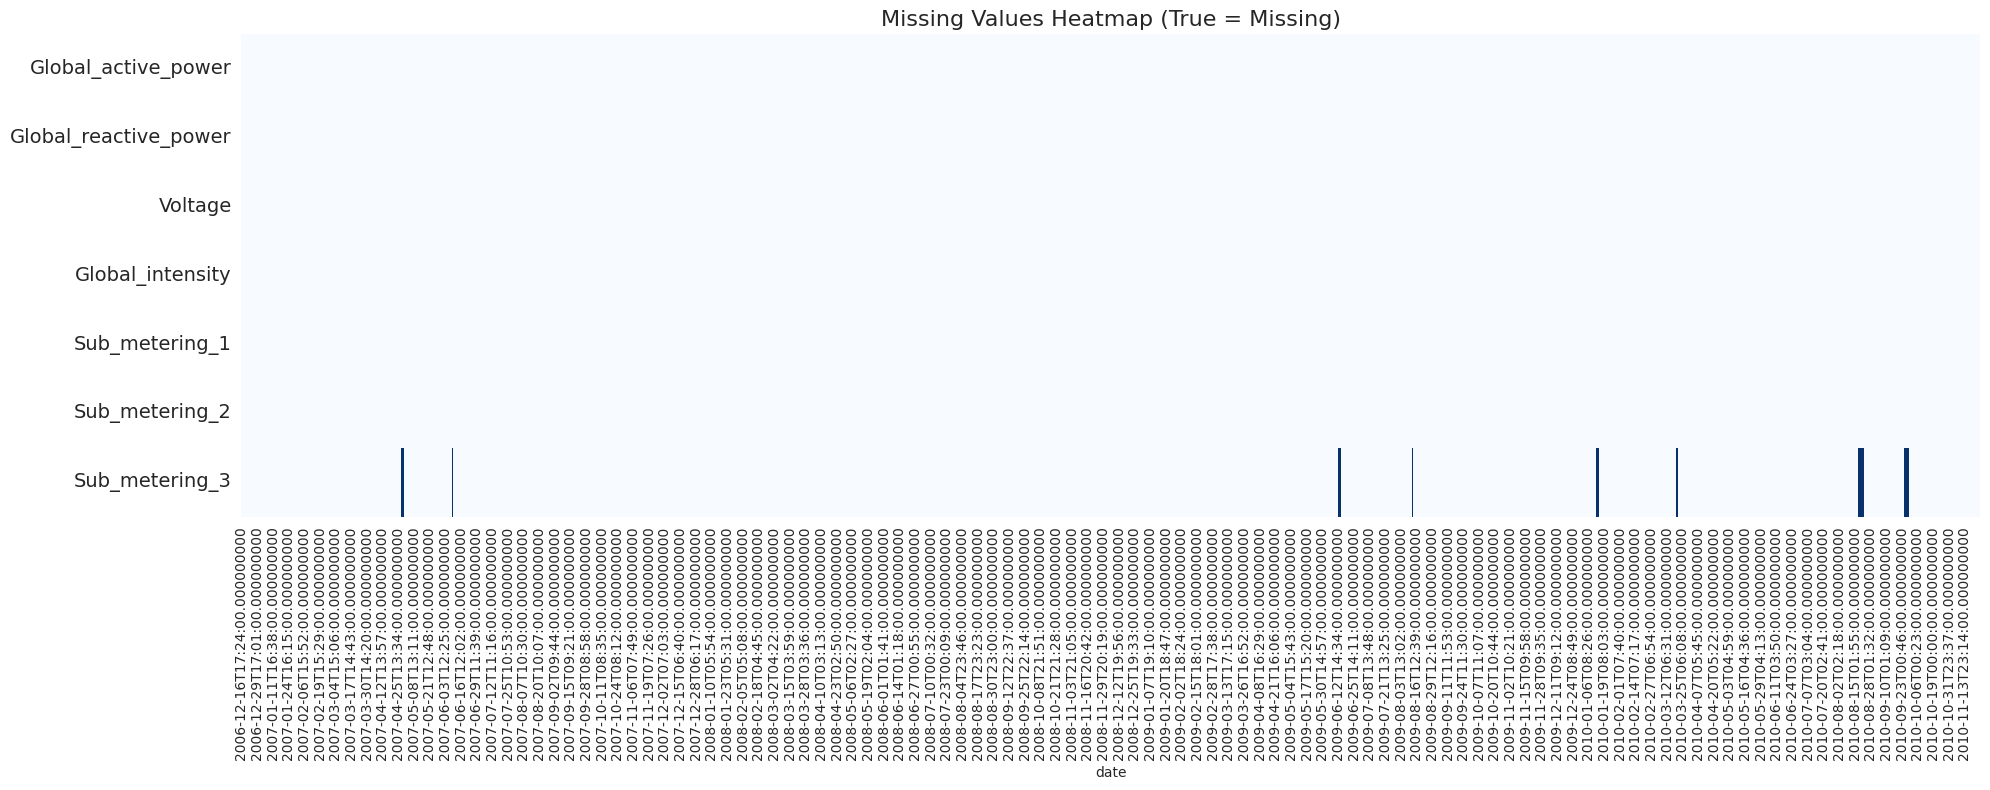

--- End of Analysis ---



In [75]:
missing_handler = TimeSeriesMissingHandler(df)
missing_handler.base_analysis()

In [76]:
# Resampling to hourly frequency
df['date'] = pd.to_datetime(df['date'])
df = df.set_index('date')
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')

/tmp/ipykernel_1736/2332389180.py:2: UserWarning: Parsing dates in %d/%m/%Y %H:%M:%S format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['date'] = pd.to_datetime(df['date'])


In [77]:
df_hourly_agg = df.resample('h').agg({
    'Global_active_power': 'mean',
    'Global_reactive_power': 'mean',
    'Voltage': 'mean',
    'Global_intensity': 'mean',
    'Sub_metering_1': 'sum',
    'Sub_metering_2': 'sum',
    'Sub_metering_3': 'sum'
})
df_hourly_agg.reset_index(inplace=True)
df_hourly_agg['date'] = df_hourly_agg['date'].dt.strftime('%Y-%m-%d %H:%M:%S')
df_hourly_agg

,date,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,2006-12-16 17:00:00,4.222889,0.229000,234.643889,18.100000,0.0,19.0,607.0
1,2006-12-16 18:00:00,3.632200,0.080033,234.580167,15.600000,0.0,403.0,1012.0
2,2006-12-16 19:00:00,3.400233,0.085233,233.232500,14.503333,0.0,86.0,1001.0
3,2006-12-16 20:00:00,3.268567,0.075100,234.071500,13.916667,0.0,0.0,1007.0
4,2006-12-16 21:00:00,3.056467,0.076667,237.158667,13.046667,0.0,25.0,1033.0
...,...,...,...,...,...,...,...,...
34584,2010-11-26 17:00:00,1.725900,0.061400,237.069667,7.216667,0.0,0.0,772.0
34585,2010-11-26 18:00:00,1.573467,0.053700,237.531833,6.620000,0.0,0.0,0.0
34586,2010-11-26 19:00:00,1.659333,0.060033,236.741000,7.056667,0.0,4.0,0.0
34587,2010-11-26 20:00:00,1.163700,0.061167,239.396000,4.913333,0.0,64.0,0.0


TimeSeriesMissingHandler initialized. DataFrame shape: (34589, 8)
Date column 'date' identified.

--- Missing Value Analysis ---
Columns with missing values (%):
- Global_active_power: 1.22% (421 values)
- Global_reactive_power: 1.22% (421 values)
- Voltage: 1.22% (421 values)
- Global_intensity: 1.22% (421 values)

Displaying Missing Value Heatmap...


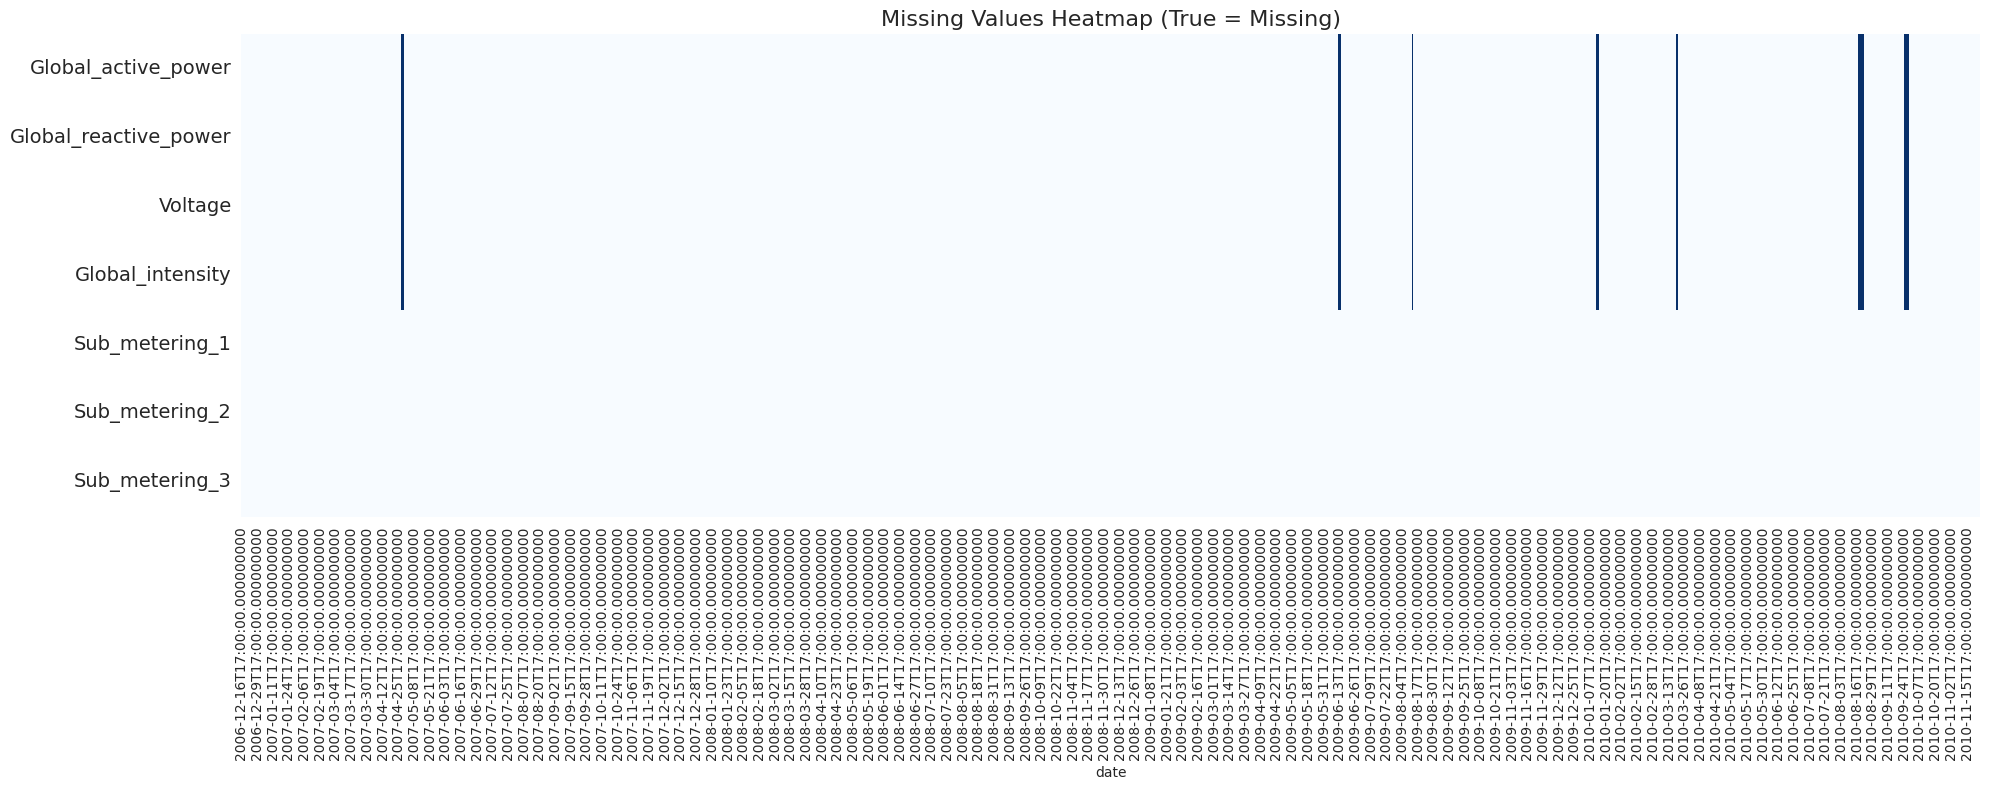

--- End of Analysis ---



In [78]:
missing_handler = TimeSeriesMissingHandler(df_hourly_agg)
missing_handler.base_analysis()

In [79]:
df_hourly_agg = df_hourly_agg[5065:21823]

In [80]:
dataset_info.add_dataset('household_power_consumption', 'energy', df_hourly_agg, ['Global_active_power', 'Global_reactive_power'])

/workspaces/foundation-covariate-forecasting/src/timeseries/preprocessing/preprocessing.py:155: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[_STD_DATE_COL] = pd.to_datetime(df[_STD_DATE_COL], format=date_format, errors='raise')


Processed DataFrame saved to: /workspaces/foundation-covariate-forecasting/data/prepared_datasets/household_power_consumption.csv


,dataset_name,domain,granularity,ts_length,num_ts,ts_names,targets,num_targets,past_covariates,num_past_covariates,future_covariates,num_future_covariates,categorical_covariates,num_categorical_covariates
3,energy,energy,h,30233,1,[_single_series_],"[price_actual, total_load_actual]",2,"[generation_biomass, generation_fossil_brown_c...",20,"[price_day_ahead, total_load_forecast, forecas...",4,[],0
4,bitcoin,economic,D,2659,1,[_single_series_],[price],1,"[active_addresses, av_transaction_value, block...",17,[],0,[],0
5,air_quality,nature,h,10898,35,"[aotizhongxin_aq, badaling_aq, beibuxinqu_aq, ...","[CO, NO2, O3, SO2]",4,"[PM10, PM2.5]",2,[],0,[],0
6,etth,energy,h,17420,2,"[one, two]",[OT],1,"[HUFL, HULL, LUFL, LULL, MUFL, MULL]",6,[],0,[],0
7,household_power_consumption,energy,h,16758,1,[_single_series_],"[Global_active_power, Global_reactive_power]",2,"[Global_intensity, Sub_metering_1, Sub_meterin...",5,[],0,[],0


# Stackoverflow

**Dataset Summary:**  
This dataset contains the monthly count of StackOverflow questions for various libraries, frameworks, and topics from 2009 onwards. It enables trend analysis of programming and data science tools over time.  

### Features:  
A comprehensive list of programming libraries, frameworks, and topics (e.g., `nltk`, `python`, `tensorflow`, `classification`, `azure-virtual-machine`, etc.), representing the tags used in StackOverflow questions.  

**Source:** [Kaggle - StackIndex Dataset](https://www.kaggle.com/datasets/aishu200023/stackindex)  

In [81]:
df = pd.read_csv(RAW_DATASETS_DIR + 'Stackoverflow/MLTollsStackOverflow.csv')
df.head()

,month,nltk,spacy,stanford-nlp,python,r,numpy,scipy,matlab,machine-learning,...,Plato,Sympy,Flair,stanford-nlp.1,pyqt,Nolearn,Lasagne,OCR,Apache-spark-mlib,azure-virtual-machine
0,09-Jan,0,0,0,631,8,6,2,19,8,...,0,1,0,0,5,0,0,5,0,0
1,09-Feb,1,0,0,633,9,7,3,27,4,...,0,0,0,0,5,0,0,11,0,0
2,09-Mar,0,0,0,766,4,4,2,24,3,...,0,0,0,0,7,0,0,2,0,0
3,09-Apr,0,0,0,768,12,6,3,32,10,...,0,0,0,0,11,0,0,5,0,0
4,09-May,1,0,0,1003,2,7,2,42,7,...,0,0,0,0,10,0,0,3,0,0


In [82]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 132 entries, 0 to 131
Data columns (total 82 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   month                  132 non-null    object 
 1   nltk                   132 non-null    int64  
 2   spacy                  132 non-null    int64  
 3   stanford-nlp           132 non-null    int64  
 4   python                 132 non-null    int64  
 5   r                      132 non-null    int64  
 6   numpy                  132 non-null    int64  
 7   scipy                  132 non-null    int64  
 8   matlab                 132 non-null    int64  
 9   machine-learning       132 non-null    int64  
 10  pandas                 132 non-null    int64  
 11  pytorch                132 non-null    int64  
 12  keras                  132 non-null    int64  
 13  nlp                    132 non-null    int64  
 14  apache-spark           132 non-null    int64  
 15  hadoop

In [83]:
df.drop(columns=['Tableau'], inplace=True)

In [84]:
df['date'] = pd.to_datetime(df['month'], format= '%y-%b')
df.head()

,month,nltk,spacy,stanford-nlp,python,r,numpy,scipy,matlab,machine-learning,...,Sympy,Flair,stanford-nlp.1,pyqt,Nolearn,Lasagne,OCR,Apache-spark-mlib,azure-virtual-machine,date
0,09-Jan,0,0,0,631,8,6,2,19,8,...,1,0,0,5,0,0,5,0,0,2009-01-01
1,09-Feb,1,0,0,633,9,7,3,27,4,...,0,0,0,5,0,0,11,0,0,2009-02-01
2,09-Mar,0,0,0,766,4,4,2,24,3,...,0,0,0,7,0,0,2,0,0,2009-03-01
3,09-Apr,0,0,0,768,12,6,3,32,10,...,0,0,0,11,0,0,5,0,0,2009-04-01
4,09-May,1,0,0,1003,2,7,2,42,7,...,0,0,0,10,0,0,3,0,0,2009-05-01


In [85]:
df.drop(columns=['month'], inplace=True)

In [86]:
dataset_info.add_dataset('stackoverflow', 'human', df, df.columns[:30].to_list())

Processed DataFrame saved to: /workspaces/foundation-covariate-forecasting/data/prepared_datasets/stackoverflow.csv


,dataset_name,domain,granularity,ts_length,num_ts,ts_names,targets,num_targets,past_covariates,num_past_covariates,future_covariates,num_future_covariates,categorical_covariates,num_categorical_covariates
4,bitcoin,economic,D,2659,1,[_single_series_],[price],1,"[active_addresses, av_transaction_value, block...",17,[],0,[],0
5,air_quality,nature,h,10898,35,"[aotizhongxin_aq, badaling_aq, beibuxinqu_aq, ...","[CO, NO2, O3, SO2]",4,"[PM10, PM2.5]",2,[],0,[],0
6,etth,energy,h,17420,2,"[one, two]",[OT],1,"[HUFL, HULL, LUFL, LULL, MUFL, MULL]",6,[],0,[],0
7,household_power_consumption,energy,h,16758,1,[_single_series_],"[Global_active_power, Global_reactive_power]",2,"[Global_intensity, Sub_metering_1, Sub_meterin...",5,[],0,[],0
8,stackoverflow,human,MS,132,1,[_single_series_],"[AllenNLP, Dask, apache-spark, deep-learning, ...",30,"[Apache, Apache-spark-mlib, BeautifulSoup, Col...",50,[],0,[],0


# Covid 19

**Dataset Summary:**  
This dataset provides daily country-level data on the COVID-19 pandemic, tracking the number of confirmed cases, deaths, recoveries, and active cases.

### Features:  
- **Country/Region:** Name of the country or region.  
- **date:** Date of the record.  
- **Confirmed:** Total confirmed cases up to the given date.  
- **Deaths:** Total number of deaths up to the given date.  
- **Recovered:** Total number of recoveries up to the given date.  
- **Active:** Total active cases up to the given date.  

**Source:** [Kaggle - COVID-19 Report Dataset](https://www.kaggle.com/datasets/imdevskp/corona-virus-report/data)  

In [87]:
df = pd.read_csv(RAW_DATASETS_DIR + 'Covid_19/covid_19_clean_complete.csv')
df.head()

,Province/State,Country/Region,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
0,NaN,Afghanistan,33.93911,67.709953,2020-01-22,0,0,0,0,Eastern Mediterranean
1,NaN,Albania,41.15330,20.168300,2020-01-22,0,0,0,0,Europe
2,NaN,Algeria,28.03390,1.659600,2020-01-22,0,0,0,0,Africa
3,NaN,Andorra,42.50630,1.521800,2020-01-22,0,0,0,0,Europe
4,NaN,Angola,-11.20270,17.873900,2020-01-22,0,0,0,0,Africa


In [88]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49068 entries, 0 to 49067
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Province/State  14664 non-null  object 
 1   Country/Region  49068 non-null  object 
 2   Lat             49068 non-null  float64
 3   Long            49068 non-null  float64
 4   Date            49068 non-null  object 
 5   Confirmed       49068 non-null  int64  
 6   Deaths          49068 non-null  int64  
 7   Recovered       49068 non-null  int64  
 8   Active          49068 non-null  int64  
 9   WHO Region      49068 non-null  object 
dtypes: float64(2), int64(4), object(4)
memory usage: 3.7+ MB


In [89]:
df['WHO Region'].value_counts()

WHO Region
Europe                   15040
Western Pacific          10340
Africa                    9024
Americas                  8648
Eastern Mediterranean     4136
South-East Asia           1880
Name: count, dtype: int64

In [90]:
df['Country/Region'].value_counts()

Country/Region
China             6204
Canada            2256
France            2068
United Kingdom    2068
Australia         1504
                  ... 
Holy See           188
Honduras           188
Hungary            188
Iceland            188
Lesotho            188
Name: count, Length: 187, dtype: int64

In [91]:
df.drop(columns=['Province/State', 'Lat', 'Long', 'WHO Region'], inplace=True)


In [92]:
df = df.groupby(['Country/Region', 'Date']).sum().reset_index()

In [93]:
df.rename({'Date': 'date'}, axis=1 , inplace=True)

In [94]:
len(df['date'].unique())

188

In [95]:
dataset_info.add_dataset('covid', 'human', df, ['Deaths', 'Active'], ts_name_col='Country/Region')

Processed DataFrame saved to: /workspaces/foundation-covariate-forecasting/data/prepared_datasets/covid.csv


,dataset_name,domain,granularity,ts_length,num_ts,ts_names,targets,num_targets,past_covariates,num_past_covariates,future_covariates,num_future_covariates,categorical_covariates,num_categorical_covariates
5,air_quality,nature,h,10898,35,"[aotizhongxin_aq, badaling_aq, beibuxinqu_aq, ...","[CO, NO2, O3, SO2]",4,"[PM10, PM2.5]",2,[],0,[],0
6,etth,energy,h,17420,2,"[one, two]",[OT],1,"[HUFL, HULL, LUFL, LULL, MUFL, MULL]",6,[],0,[],0
7,household_power_consumption,energy,h,16758,1,[_single_series_],"[Global_active_power, Global_reactive_power]",2,"[Global_intensity, Sub_metering_1, Sub_meterin...",5,[],0,[],0
8,stackoverflow,human,MS,132,1,[_single_series_],"[AllenNLP, Dask, apache-spark, deep-learning, ...",30,"[Apache, Apache-spark-mlib, BeautifulSoup, Col...",50,[],0,[],0
9,covid,human,D,188,187,"[Afghanistan, Albania, Algeria, Andorra, Angol...","[Active, Deaths]",2,"[Confirmed, Recovered]",2,[],0,[],0


# Weather

**Dataset Summary:**  
This dataset contains hourly climate data from Monash University, Clayton, Victoria, Australia, spanning from January 1, 2010, to May 31, 2021. It includes key meteorological variables that can be used for climate and weather pattern analysis.  

### Features:  
- **date:** Date and time of the measurement.  
- **dewpoint_temperature:** Dewpoint temperature (°C).  
- **mean_sea_level_pressure:** Mean sea level pressure (Pa).  
- **relative_humidity:** Relative humidity (0–1).  
- **surface_solar_radiation:** Surface solar radiation (W/m²).  
- **surface_thermal_radiation:** Surface thermal radiation (W/m²).  
- **temperature:** Air temperature (°C).  
- **total_cloud_cover:** Total cloud cover (0–1).  
- **wind_speed:** Wind speed (m/s).  

**Source:** [Zenodo - Monash University Climate Data](https://zenodo.org/records/5184708)  

In [96]:
loaded_data, frequency, forecast_horizon, contain_missing_values, contain_equal_length = convert_tsf_to_dataframe(RAW_DATASETS_DIR + 'Weather/oikolab_weather_dataset.tsf')

In [97]:
loaded_data

,series_name,start_timestamp,type,series_value
0,T1,2010-01-01,temperature,"[18.26, 18.67, 18.16, 18.46, 18.53, 18.92, 19...."
1,T2,2010-01-01,dewpoint_temperature,"[16.39, 16.29, 15.89, 15.33, 15.11, 15.16, 15...."
2,T3,2010-01-01,wind_speed,"[2.6, 2.91, 3.26, 3.17, 2.95, 2.62, 2.87, 3.01..."
3,T4,2010-01-01,mean_sea_level_pressure,"[101046.38, 101037.96, 101017.26, 101022.56, 1..."
4,T5,2010-01-01,relative_humidity,"[0.89, 0.86, 0.87, 0.82, 0.8, 0.79, 0.77, 0.76..."
5,T6,2010-01-01,surface_solar_radiation,"[287.01, 360.79, 291.54, 357.11, 459.91, 513.0..."
6,T7,2010-01-01,surface_thermal_radiation,"[408.35, 411.02, 410.67, 410.95, 410.0, 407.46..."
7,T8,2010-01-01,total_cloud_cover,"[1.0, 1.0, 1.0, 1.0, 0.9, 0.96, 0.94, 0.9, 0.8..."


In [98]:
frequency

'hourly'

In [99]:
df = convert_row_df_to_column_df(loaded_data, frequency, 'type')
df

type,date,dewpoint_temperature,mean_sea_level_pressure,relative_humidity,surface_solar_radiation,surface_thermal_radiation,temperature,total_cloud_cover,wind_speed
0,2010-01-01 00:00:00,16.39,101046.38,0.89,287.01,408.35,18.26,1.00,2.60
1,2010-01-01 01:00:00,16.29,101037.96,0.86,360.79,411.02,18.67,1.00,2.91
2,2010-01-01 02:00:00,15.89,101017.26,0.87,291.54,410.67,18.16,1.00,3.26
3,2010-01-01 03:00:00,15.33,101022.56,0.82,357.11,410.95,18.46,1.00,3.17
4,2010-01-01 04:00:00,15.11,100940.03,0.80,459.91,410.00,18.53,0.90,2.95
...,...,...,...,...,...,...,...,...,...
100052,2021-05-31 20:00:00,3.28,102033.73,0.71,0.00,278.11,8.31,0.93,4.91
100053,2021-05-31 21:00:00,3.16,102033.49,0.71,0.00,277.98,8.15,1.00,4.63
100054,2021-05-31 22:00:00,3.31,102069.84,0.69,8.99,281.65,8.72,1.00,5.29
100055,2021-05-31 23:00:00,3.88,102077.12,0.66,80.46,296.20,9.83,1.00,5.60


In [100]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100057 entries, 0 to 100056
Data columns (total 9 columns):
 #   Column                     Non-Null Count   Dtype         
---  ------                     --------------   -----         
 0   date                       100057 non-null  datetime64[ns]
 1   dewpoint_temperature       100057 non-null  float64       
 2   mean_sea_level_pressure    100057 non-null  float64       
 3   relative_humidity          100057 non-null  float64       
 4   surface_solar_radiation    100057 non-null  float64       
 5   surface_thermal_radiation  100057 non-null  float64       
 6   temperature                100057 non-null  float64       
 7   total_cloud_cover          100057 non-null  float64       
 8   wind_speed                 100057 non-null  float64       
dtypes: datetime64[ns](1), float64(8)
memory usage: 6.9 MB


In [101]:
dataset_info.add_dataset('weather', 'nature', df, ['surface_solar_radiation', 'wind_speed'])

Processed DataFrame saved to: /workspaces/foundation-covariate-forecasting/data/prepared_datasets/weather.csv


,dataset_name,domain,granularity,ts_length,num_ts,ts_names,targets,num_targets,past_covariates,num_past_covariates,future_covariates,num_future_covariates,categorical_covariates,num_categorical_covariates
6,etth,energy,h,17420,2,"[one, two]",[OT],1,"[HUFL, HULL, LUFL, LULL, MUFL, MULL]",6,[],0,[],0
7,household_power_consumption,energy,h,16758,1,[_single_series_],"[Global_active_power, Global_reactive_power]",2,"[Global_intensity, Sub_metering_1, Sub_meterin...",5,[],0,[],0
8,stackoverflow,human,MS,132,1,[_single_series_],"[AllenNLP, Dask, apache-spark, deep-learning, ...",30,"[Apache, Apache-spark-mlib, BeautifulSoup, Col...",50,[],0,[],0
9,covid,human,D,188,187,"[Afghanistan, Albania, Algeria, Andorra, Angol...","[Active, Deaths]",2,"[Confirmed, Recovered]",2,[],0,[],0
10,weather,nature,h,100057,1,[_single_series_],"[surface_solar_radiation, wind_speed]",2,"[dewpoint_temperature, mean_sea_level_pressure...",6,[],0,[],0


# Covid Mobility

**Dataset Summary:**  
This dataset includes daily time series data on the percentage changes in six aspects of life due to COVID-19, across 131 countries and regions. It tracks changes in activities such as retail, recreation, grocery/pharmacy, and more during the pandemic.

### Features:  
- **date:** Date of the recorded data.  
- **country:** Country or region of the recorded data.  
- **grocery_pharmacy:** Percentage change in grocery and pharmacy visits.  
- **parks:** Percentage change in park visits.  
- **residential:** Percentage change in residential areas.  
- **retail_recreation:** Percentage change in retail and recreation activities.  
- **transit_stations:** Percentage change in transit station visits.  
- **workplaces:** Percentage change in workplace attendance.  

**Source:** [Zenodo - COVID-19 Mobility Impact Dataset](https://zenodo.org/records/4663809)

In [102]:
loaded_data, frequency, forecast_horizon, contain_missing_values, contain_equal_length = convert_tsf_to_dataframe(RAW_DATASETS_DIR + 'Covid-Mobility/covid_mobility_dataset_without_missing_values.tsf')

In [103]:
loaded_data

,series_name,country,type,start_timestamp,series_value
0,T1,Afghanistan,retail_recreation,2020-02-15,"[-11.0, 1.5, 3.5, 1.0, -2.5, -2.5, -1.5, 0.0, ..."
1,T2,Afghanistan,grocery_pharmacy,2020-02-15,"[-11.0, 10.0, 11.0, 4.5, 2.5, 4.0, 8.5, 6.5, 6..."
2,T3,Afghanistan,parks,2020-02-15,"[-7.0, 0.0, -0.5, 3.0, -2.0, -2.0, 3.0, 4.5, 1..."
3,T4,Afghanistan,transit_stations,2020-02-15,"[-2.0, 10.0, 9.5, 8.5, -0.5, 4.5, 5.5, 6.0, 6...."
4,T5,Afghanistan,workplaces,2020-02-15,"[-33.5, 3.0, 4.5, 5.0, 3.0, 5.5, 5.5, 5.0, 5.5..."
...,...,...,...,...,...
554,T555,Zambia,transit_stations,2020-02-15,"[-3.0, -6.5, -8.0, -4.0, -5.5, -6.5, -10.0, -7..."
555,T556,Zambia,workplaces,2020-02-15,"[7.0, 2.5, 8.0, 6.5, 4.5, 2.5, 6.5, 5.0, 0.0, ..."
556,T557,Zambia,residential,2020-02-15,"[3.5, 2.5, 2.0, 1.5, 2.5, 2.5, 2.0, 3.0, 3.0, ..."
557,T558,Zimbabwe,workplaces,2020-02-17,"[9.44444444444444, 9.58823529411765, 0.0, 0.0,..."


In [104]:
df = convert_row_df_to_column_df(loaded_data, frequency, 'type', ['country'])

In [105]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48068 entries, 0 to 48067
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   date               48068 non-null  datetime64[ns]
 1   country            48068 non-null  object        
 2   grocery_pharmacy   27750 non-null  float64       
 3   parks              26431 non-null  float64       
 4   residential        26247 non-null  float64       
 5   retail_recreation  30653 non-null  float64       
 6   transit_stations   24869 non-null  float64       
 7   workplaces         46961 non-null  float64       
dtypes: datetime64[ns](1), float64(6), object(1)
memory usage: 2.9+ MB


TimeSeriesMissingHandler initialized. DataFrame shape: (48068, 8)
Date column 'date' identified.

--- Missing Value Analysis ---
Columns with missing values (%):
- transit_stations: 48.26% (23199 values)
- residential: 45.40% (21821 values)
- parks: 45.01% (21637 values)
- grocery_pharmacy: 42.27% (20318 values)
- retail_recreation: 36.23% (17415 values)
- workplaces: 2.30% (1107 values)

Displaying Missing Value Heatmap...


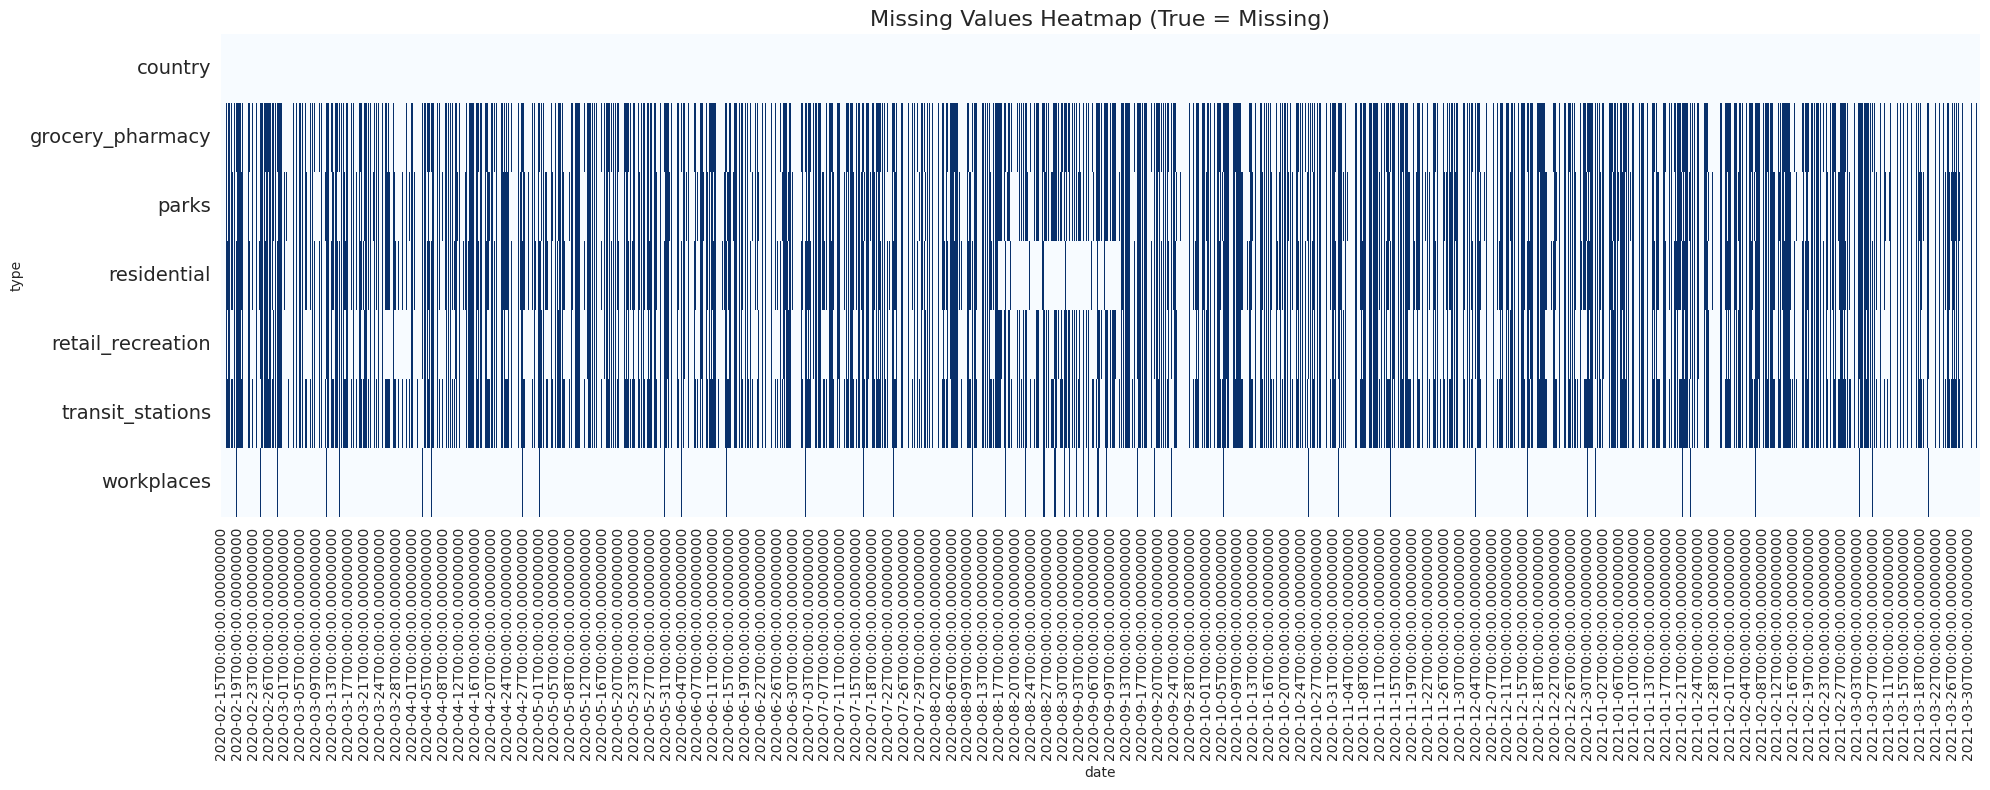

--- End of Analysis ---



In [106]:
missing_handler = TimeSeriesMissingHandler(df)
missing_handler.base_analysis()

In [107]:
len(df['country'].unique())

131

In [108]:
df.dropna(axis=0, inplace=True)
df['country'].value_counts()

country
Myanmar (Burma)           413
Panama                    413
Malta                     413
Venezuela                 413
Moldova                   413
Mongolia                  413
Morocco                   413
Aruba                     413
Nepal                     413
North Macedonia           413
Ukraine                   413
Thailand                  413
Philippines               413
Qatar                     413
Russia                    413
Trinidad and Tobago       413
Singapore                 413
South Korea               413
Sri Lanka                 413
Taiwan                    413
Mali                      413
Malaysia                  413
Luxembourg                413
Laos                      413
Bahrain                   413
Bangladesh                413
Belarus                   413
Belgium                   413
Bosnia and Herzegovina    413
Costa Rica                413
Fiji                      413
Zambia                    413
Germany                   413
Gh

In [109]:
df = df[df.groupby('country')['country'].transform('size') >= 413]

In [110]:
dataset_info.add_dataset('covid_mobility', 'human', df , ['workplaces'], ts_name_col='country')

Processed DataFrame saved to: /workspaces/foundation-covariate-forecasting/data/prepared_datasets/covid_mobility.csv


,dataset_name,domain,granularity,ts_length,num_ts,ts_names,targets,num_targets,past_covariates,num_past_covariates,future_covariates,num_future_covariates,categorical_covariates,num_categorical_covariates
7,household_power_consumption,energy,h,16758,1,[_single_series_],"[Global_active_power, Global_reactive_power]",2,"[Global_intensity, Sub_metering_1, Sub_meterin...",5,[],0,[],0
8,stackoverflow,human,MS,132,1,[_single_series_],"[AllenNLP, Dask, apache-spark, deep-learning, ...",30,"[Apache, Apache-spark-mlib, BeautifulSoup, Col...",50,[],0,[],0
9,covid,human,D,188,187,"[Afghanistan, Albania, Algeria, Andorra, Angol...","[Active, Deaths]",2,"[Confirmed, Recovered]",2,[],0,[],0
10,weather,nature,h,100057,1,[_single_series_],"[surface_solar_radiation, wind_speed]",2,"[dewpoint_temperature, mean_sea_level_pressure...",6,[],0,[],0
11,covid_mobility,human,D,413,42,"[Aruba, Bahrain, Bangladesh, Belarus, Belgium,...",[workplaces],1,"[grocery_pharmacy, parks, residential, retail_...",5,[],0,[],0


# Illness

**Dataset Summary:**  
This dataset provides weekly time series data on influenza-like illness (ILI) statistics, tracking the incidence of ILI cases across various age groups and healthcare providers' contributions.

### Features:
- **Date:** The date representing the week of recorded data (e.g., "2002-01-01" for the week starting January 1, 2002).
- **% WEIGHTED ILI:** The percentage of patient visits for influenza-like illness (ILI), adjusted for population size or demographic distribution.
- **% UNWEIGHTED ILI:** The raw percentage of patient visits for ILI, calculated directly from the data without any adjustments.
- **AGE 0-4:** The raw count of ILI cases reported in the age group 0-4 years during the week.
- **AGE 5-24:** The raw count of ILI cases reported in the age group 5-24 years during the week.
- **ILITOTAL:** The total number of ILI cases reported across all age groups during the week.
- **NUM. OF PROVIDERS:** The number of healthcare providers contributing data for that week, indicating the coverage and reliability of the data.
- **OT:** Likely represents an "Other Totals" or unclassified category, possibly including non-age-specific data or other aggregate totals.

**Source:** [Time-Series Library GitHub](https://github.com/thuml/Time-Series-Library?tab=readme-ov-file)

In [111]:
df = pd.read_csv(RAW_DATASETS_DIR + 'Illness/national_illness.csv')
df

,date,% WEIGHTED ILI,%UNWEIGHTED ILI,AGE 0-4,AGE 5-24,ILITOTAL,NUM. OF PROVIDERS,OT
0,2002-01-01 00:00:00,1.222620,1.166680,582,805,2060,754,176569
1,2002-01-08 00:00:00,1.333440,1.216500,683,872,2267,785,186355
2,2002-01-15 00:00:00,1.319290,1.130570,642,878,2176,831,192469
3,2002-01-22 00:00:00,1.494840,1.252460,728,1045,2599,863,207512
4,2002-01-29 00:00:00,1.471950,1.302370,823,1189,2907,909,223208
...,...,...,...,...,...,...,...,...
961,2020-06-02 00:00:00,0.839059,0.846722,2756,3528,12913,3258,1525058
962,2020-06-09 00:00:00,0.895958,0.908885,3203,3778,13979,3254,1538038
963,2020-06-16 00:00:00,0.910926,0.941625,3478,3796,14389,3177,1528103
964,2020-06-23 00:00:00,0.946945,0.972185,3734,3818,14999,3066,1542813


In [112]:
df.columns

Index(['date', '% WEIGHTED ILI', '%UNWEIGHTED ILI', 'AGE 0-4', 'AGE 5-24',
       'ILITOTAL', 'NUM. OF PROVIDERS', 'OT'],
      dtype='object')

In [113]:
dataset_info.add_dataset('illness', 'human', df, ['AGE 0-4', 'AGE 5-24', 'ILITOTAL'])

Processed DataFrame saved to: /workspaces/foundation-covariate-forecasting/data/prepared_datasets/illness.csv


,dataset_name,domain,granularity,ts_length,num_ts,ts_names,targets,num_targets,past_covariates,num_past_covariates,future_covariates,num_future_covariates,categorical_covariates,num_categorical_covariates
8,stackoverflow,human,MS,132,1,[_single_series_],"[AllenNLP, Dask, apache-spark, deep-learning, ...",30,"[Apache, Apache-spark-mlib, BeautifulSoup, Col...",50,[],0,[],0
9,covid,human,D,188,187,"[Afghanistan, Albania, Algeria, Andorra, Angol...","[Active, Deaths]",2,"[Confirmed, Recovered]",2,[],0,[],0
10,weather,nature,h,100057,1,[_single_series_],"[surface_solar_radiation, wind_speed]",2,"[dewpoint_temperature, mean_sea_level_pressure...",6,[],0,[],0
11,covid_mobility,human,D,413,42,"[Aruba, Bahrain, Bangladesh, Belarus, Belgium,...",[workplaces],1,"[grocery_pharmacy, parks, residential, retail_...",5,[],0,[],0
12,illness,human,W-TUE,966,1,[_single_series_],"[AGE 0-4, AGE 5-24, ILITOTAL]",3,"[% WEIGHTED ILI, %UNWEIGHTED ILI, NUM. OF PROV...",4,[],0,[],0


# Madrid

**Dataset Summary:**  
This dataset contains air quality, meteorological, and traffic data for Madrid from January to June in 2019 and 2022, with features like wind speed, temperature, solar radiation, and traffic speed.

### Features:  
- **NO2:** Nitrogen dioxide concentration in the air.  
- **windSpeed:** Wind speed in meters per second.  
- **windDir:** Wind direction in degrees.  
- **Temp:** Temperature in degrees Celsius.  
- **Humidity:** Humidity level (0-1).  
- **Pressure:** Atmospheric pressure in Pascals.  
- **SolarRad:** Solar radiation in Watts per square meter.  
- **intensidad:** Intensity, potentially referring to energy or light.  
- **ocupacion:** Occupancy time, possibly referring to traffic or air quality station usage.  
- **carga:** Load, likely referring to traffic load or energy consumption.  
- **vmed:** Average traffic speed.  
- **windDir_Categ_*:** One-hot encoded categorical representation of wind direction.  
- **station:** Station number or identifier.  
- **date:** Date of observation.  

**Source:** [Zenodo - Air Quality and Traffic Data](https://zenodo.org/records/7308425)

In [114]:
df2019 = pd.read_csv(RAW_DATASETS_DIR + 'Madrid/Mad_Station_2019.csv')
df2022 = pd.read_csv(RAW_DATASETS_DIR + 'Madrid/Mad_Station_2022.csv')
df2022

,NO2,windSpeed,windDir,Temp,Humidity,Pressure,SolarRad,intensidad,ocupacion,carga,vmed,windDir_Categ_east,windDir_Categ_north,windDir_Categ_northeast,windDir_Categ_northwest,windDir_Categ_south,windDir_Categ_southeast,windDir_Categ_southwest,windDir_Categ_west
0,64.0,0.05,282.0,1.8,94.0,957.0,3.0,135.88,2.00,7.62,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,56.0,0.53,335.0,8.5,83.0,948.0,3.0,56.50,0.00,6.50,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2,51.0,0.64,67.0,6.1,88.0,958.0,1.0,244.32,4.40,14.21,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
3,36.0,1.52,29.0,6.9,71.0,948.0,3.0,289.88,2.69,21.38,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
4,46.0,0.64,67.0,6.5,88.0,958.0,1.0,197.00,3.14,11.71,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
104227,10.0,0.80,40.0,23.6,37.0,941.0,1.0,174.93,4.47,10.42,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
104228,37.0,0.72,353.0,23.3,36.0,937.0,1.0,250.75,1.50,13.25,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
104229,18.0,0.88,326.0,21.9,27.0,938.0,1.0,264.54,2.38,12.00,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
104230,13.0,0.80,40.0,23.6,37.0,941.0,1.0,92.00,2.33,7.44,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0


In [115]:
df2019.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104256 entries, 0 to 104255
Data columns (total 19 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   NO2                      104256 non-null  float64
 1   windSpeed                104256 non-null  float64
 2   windDir                  104256 non-null  float64
 3   Temp                     104256 non-null  float64
 4   Humidity                 104256 non-null  float64
 5   Pressure                 104256 non-null  float64
 6   SolarRad                 104256 non-null  float64
 7   intensidad               104256 non-null  float64
 8   ocupacion                104256 non-null  float64
 9   carga                    104256 non-null  float64
 10  vmed                     104256 non-null  float64
 11  windDir_Categ_east       104256 non-null  float64
 12  windDir_Categ_north      104256 non-null  float64
 13  windDir_Categ_northeast  104256 non-null  float64
 14  wind

In [116]:
df2022.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104232 entries, 0 to 104231
Data columns (total 19 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   NO2                      104232 non-null  float64
 1   windSpeed                104232 non-null  float64
 2   windDir                  104232 non-null  float64
 3   Temp                     104232 non-null  float64
 4   Humidity                 104232 non-null  float64
 5   Pressure                 104232 non-null  float64
 6   SolarRad                 104232 non-null  float64
 7   intensidad               104232 non-null  float64
 8   ocupacion                104232 non-null  float64
 9   carga                    104232 non-null  float64
 10  vmed                     104232 non-null  float64
 11  windDir_Categ_east       104232 non-null  float64
 12  windDir_Categ_north      104232 non-null  float64
 13  windDir_Categ_northeast  104232 non-null  float64
 14  wind

In [117]:
df2019['station'] = list(range(1,25)) * 4344
df2022['station'] = list(range(1,25)) * 4343
df2022

,NO2,windSpeed,windDir,Temp,Humidity,Pressure,SolarRad,intensidad,ocupacion,carga,vmed,windDir_Categ_east,windDir_Categ_north,windDir_Categ_northeast,windDir_Categ_northwest,windDir_Categ_south,windDir_Categ_southeast,windDir_Categ_southwest,windDir_Categ_west,station
0,64.0,0.05,282.0,1.8,94.0,957.0,3.0,135.88,2.00,7.62,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1
1,56.0,0.53,335.0,8.5,83.0,948.0,3.0,56.50,0.00,6.50,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,2
2,51.0,0.64,67.0,6.1,88.0,958.0,1.0,244.32,4.40,14.21,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,3
3,36.0,1.52,29.0,6.9,71.0,948.0,3.0,289.88,2.69,21.38,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,4
4,46.0,0.64,67.0,6.5,88.0,958.0,1.0,197.00,3.14,11.71,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
104227,10.0,0.80,40.0,23.6,37.0,941.0,1.0,174.93,4.47,10.42,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,20
104228,37.0,0.72,353.0,23.3,36.0,937.0,1.0,250.75,1.50,13.25,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,21
104229,18.0,0.88,326.0,21.9,27.0,938.0,1.0,264.54,2.38,12.00,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,22
104230,13.0,0.80,40.0,23.6,37.0,941.0,1.0,92.00,2.33,7.44,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,23


In [118]:
dates2019 = pd.date_range('2019-01-01', periods=4344, freq='H').strftime('%Y-%m-%d %H:%M:%S')
dates2022 = pd.date_range('2022-01-01', periods=4343, freq='H').strftime('%Y-%m-%d %H:%M:%S')
df2019['date'] = [date for date in dates2019 for i in range(24)]
df2022['date'] = [date for date in dates2022 for i in range(24)]

/tmp/ipykernel_1736/3321877546.py:1: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  dates2019 = pd.date_range('2019-01-01', periods=4344, freq='H').strftime('%Y-%m-%d %H:%M:%S')
/tmp/ipykernel_1736/3321877546.py:2: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  dates2022 = pd.date_range('2022-01-01', periods=4343, freq='H').strftime('%Y-%m-%d %H:%M:%S')


In [119]:
dataset_info.add_dataset('madrid19', 'nature', df2019, ['NO2'], categorical_covariates=['windDir_Categ_east', 'windDir_Categ_north', 'windDir_Categ_northeast',
                                                                                        'windDir_Categ_northwest', 'windDir_Categ_south', 'windDir_Categ_southeast',
                                                                                        'windDir_Categ_southwest', 'windDir_Categ_west'], ts_name_col='station')

Processed DataFrame saved to: /workspaces/foundation-covariate-forecasting/data/prepared_datasets/madrid19.csv


,dataset_name,domain,granularity,ts_length,num_ts,ts_names,targets,num_targets,past_covariates,num_past_covariates,future_covariates,num_future_covariates,categorical_covariates,num_categorical_covariates
9,covid,human,D,188,187,"[Afghanistan, Albania, Algeria, Andorra, Angol...","[Active, Deaths]",2,"[Confirmed, Recovered]",2,[],0,[],0
10,weather,nature,h,100057,1,[_single_series_],"[surface_solar_radiation, wind_speed]",2,"[dewpoint_temperature, mean_sea_level_pressure...",6,[],0,[],0
11,covid_mobility,human,D,413,42,"[Aruba, Bahrain, Bangladesh, Belarus, Belgium,...",[workplaces],1,"[grocery_pharmacy, parks, residential, retail_...",5,[],0,[],0
12,illness,human,W-TUE,966,1,[_single_series_],"[AGE 0-4, AGE 5-24, ILITOTAL]",3,"[% WEIGHTED ILI, %UNWEIGHTED ILI, NUM. OF PROV...",4,[],0,[],0
13,madrid19,nature,h,4344,24,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...",[NO2],1,"[Humidity, Pressure, SolarRad, Temp, carga, in...",18,[],0,"[windDir_Categ_east, windDir_Categ_north, wind...",8


In [120]:
dataset_info.add_dataset('madrid22', 'nature', df2022, ['NO2'], categorical_covariates=['windDir_Categ_east', 'windDir_Categ_north', 'windDir_Categ_northeast',
                                                                                        'windDir_Categ_northwest', 'windDir_Categ_south', 'windDir_Categ_southeast',
                                                                                        'windDir_Categ_southwest', 'windDir_Categ_west'], ts_name_col='station')

Processed DataFrame saved to: /workspaces/foundation-covariate-forecasting/data/prepared_datasets/madrid22.csv


,dataset_name,domain,granularity,ts_length,num_ts,ts_names,targets,num_targets,past_covariates,num_past_covariates,future_covariates,num_future_covariates,categorical_covariates,num_categorical_covariates
10,weather,nature,h,100057,1,[_single_series_],"[surface_solar_radiation, wind_speed]",2,"[dewpoint_temperature, mean_sea_level_pressure...",6,[],0,[],0
11,covid_mobility,human,D,413,42,"[Aruba, Bahrain, Bangladesh, Belarus, Belgium,...",[workplaces],1,"[grocery_pharmacy, parks, residential, retail_...",5,[],0,[],0
12,illness,human,W-TUE,966,1,[_single_series_],"[AGE 0-4, AGE 5-24, ILITOTAL]",3,"[% WEIGHTED ILI, %UNWEIGHTED ILI, NUM. OF PROV...",4,[],0,[],0
13,madrid19,nature,h,4344,24,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...",[NO2],1,"[Humidity, Pressure, SolarRad, Temp, carga, in...",18,[],0,"[windDir_Categ_east, windDir_Categ_north, wind...",8
14,madrid22,nature,h,4343,24,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...",[NO2],1,"[Humidity, Pressure, SolarRad, Temp, carga, in...",18,[],0,"[windDir_Categ_east, windDir_Categ_north, wind...",8


# Rideshare

In [121]:
loaded_data, frequency, forecast_horizon, contain_missing_values, contain_equal_length = convert_tsf_to_dataframe(RAW_DATASETS_DIR + 'Rideshare/rideshare_dataset_without_missing_values.tsf')

In [122]:
loaded_data

,series_name,source_location,provider_name,provider_service,type,start_timestamp,series_value
0,T0,Back Bay,Lyft,Lux,price_min,2018-11-26 06:00:00,"[11.0, 13.5, 13.5, 13.5, 13.5, 11.0, 10.5, 13...."
1,T1,Back Bay,Lyft,Lux,price_mean,2018-11-26 06:00:00,"[16.555555555555557, 17.3, 13.5, 17.9545454545..."
2,T2,Back Bay,Lyft,Lux,price_max,2018-11-26 06:00:00,"[22.5, 27.5, 13.5, 32.5, 26.0, 22.5, 22.5, 26...."
3,T3,Back Bay,Lyft,Lux,distance_min,2018-11-26 06:00:00,"[1.04, 1.09, 1.38, 1.39, 1.07, 1.03, 1.07, 1.0..."
4,T4,Back Bay,Lyft,Lux,distance_mean,2018-11-26 06:00:00,"[1.7266666666666666, 1.69, 1.38, 1.92090909090..."
...,...,...,...,...,...,...,...
2299,T2491,West End,Uber,WAV,temp,2018-11-26 06:00:00,"[40.56666666666667, 41.075, 0.0, 40.835, 40.62..."
2300,T2492,West End,Uber,WAV,rain,2018-11-26 06:00:00,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0026, 0...."
2301,T2493,West End,Uber,WAV,humidity,2018-11-26 06:00:00,"[0.92, 0.925, 0.0, 0.9299999999999999, 0.94, 0..."
2302,T2494,West End,Uber,WAV,clouds,2018-11-26 06:00:00,"[0.9906666666666667, 0.9675, 0.0, 1.0, 0.995, ..."


In [123]:
len(loaded_data['series_value'][0])

541

In [124]:
loaded_data['source_location'].value_counts()

source_location
Back Bay                   192
Beacon Hill                192
Boston University          192
Fenway                     192
Financial District         192
Haymarket Square           192
North End                  192
North Station              192
Northeastern University    192
South Station              192
Theatre District           192
West End                   192
Name: count, dtype: int64

In [125]:
loaded_data['provider_name'].value_counts()

provider_name
Uber    1224
Lyft    1080
Name: count, dtype: int64

In [126]:
loaded_data['provider_service'].value_counts()

provider_service
Lux             180
Lux Black       180
Lux Black XL    180
Lyft            180
Lyft XL         180
Shared          180
Black           180
Black SUV       180
UberPool        180
UberX           180
UberXL          180
WAV             180
Taxi            144
Name: count, dtype: int64

In [127]:
loaded_data[loaded_data['provider_name'] == 'Uber']['provider_service'].value_counts()

provider_service
Black        180
Black SUV    180
UberPool     180
UberX        180
UberXL       180
WAV          180
Taxi         144
Name: count, dtype: int64

In [128]:
loaded_data[loaded_data['provider_name'] == 'Lyft']['provider_service'].value_counts()

provider_service
Lux             180
Lux Black       180
Lux Black XL    180
Lyft            180
Lyft XL         180
Shared          180
Name: count, dtype: int64

In [129]:
loaded_data['type'].value_counts()

type
distance_min     156
distance_mean    156
distance_max     156
surge_min        156
surge_mean       156
surge_max        156
api_calls        156
temp             156
rain             156
humidity         156
clouds           156
wind             156
price_min        144
price_mean       144
price_max        144
Name: count, dtype: int64

In [130]:
df = convert_row_df_to_column_df(loaded_data, frequency, 'type', ['source_location', 'provider_name', 'provider_service'])

In [131]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 84396 entries, 0 to 84395
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   date              84396 non-null  datetime64[ns]
 1   source_location   84396 non-null  object        
 2   provider_name     84396 non-null  object        
 3   provider_service  84396 non-null  object        
 4   api_calls         84396 non-null  float64       
 5   clouds            84396 non-null  float64       
 6   distance_max      84396 non-null  float64       
 7   distance_mean     84396 non-null  float64       
 8   distance_min      84396 non-null  float64       
 9   humidity          84396 non-null  float64       
 10  price_max         77904 non-null  float64       
 11  price_mean        77904 non-null  float64       
 12  price_min         77904 non-null  float64       
 13  rain              84396 non-null  float64       
 14  surge_max         8439

TimeSeriesMissingHandler initialized. DataFrame shape: (84396, 19)
Date column 'date' identified.

--- Missing Value Analysis ---
Columns with missing values (%):
- price_max: 7.69% (6492 values)
- price_mean: 7.69% (6492 values)
- price_min: 7.69% (6492 values)

Displaying Missing Value Heatmap...


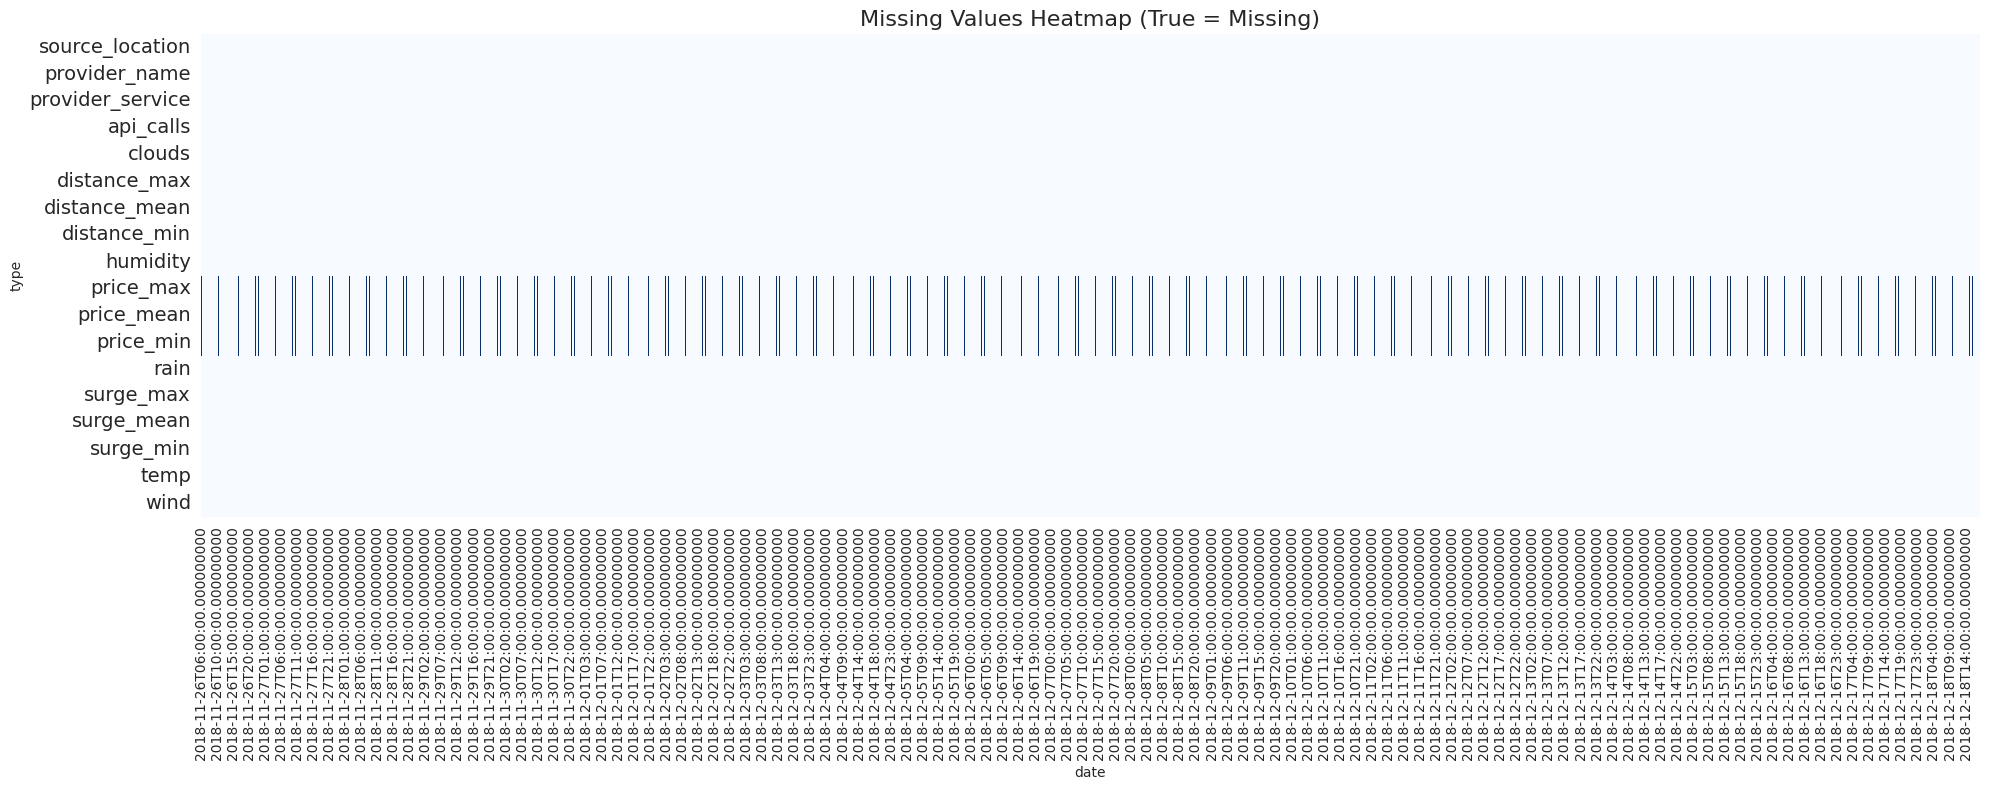

--- End of Analysis ---



In [132]:
missing_handler = TimeSeriesMissingHandler(df)
missing_handler.base_analysis()

In [133]:
print(df['source_location'].unique())
print(df['provider_name'].unique())
print(df['provider_service'].unique())

['Back Bay' 'Beacon Hill' 'Boston University' 'Fenway'
 'Financial District' 'Haymarket Square' 'North End' 'North Station'
 'Northeastern University' 'South Station' 'Theatre District' 'West End']
['Lyft' 'Uber']
['Lux' 'Lux Black' 'Lux Black XL' 'Lyft' 'Lyft XL' 'Shared' 'Black'
 'Black SUV' 'Taxi' 'UberPool' 'UberX' 'UberXL' 'WAV']


In [134]:
# rows with nans
missing_df = df[df.isnull().any(axis=1)]

print(missing_df['source_location'].unique())
print(missing_df['provider_name'].unique())
print(missing_df['provider_service'].unique())

['Back Bay' 'Beacon Hill' 'Boston University' 'Fenway'
 'Financial District' 'Haymarket Square' 'North End' 'North Station'
 'Northeastern University' 'South Station' 'Theatre District' 'West End']
['Uber']
['Taxi']


In [135]:
df.dropna(axis=0, inplace=True)

In [136]:
# combine source_location, provider_name and provider_service into one column
df['location_provider_service'] = df['source_location'] + '_' + df['provider_name'] + '_' + df['provider_service']

In [137]:
df.drop(columns=['source_location', 'provider_name', 'provider_service'], inplace=True)
df

type,date,api_calls,clouds,distance_max,distance_mean,distance_min,humidity,price_max,price_mean,price_min,rain,surge_max,surge_mean,surge_min,temp,wind,location_provider_service
0,2018-11-26 06:00:00,9.0,0.990667,3.03,1.726667,1.04,0.913333,22.5,16.555556,11.0,0.0,1.5,1.055556,1.0,40.627333,1.350667,Back Bay_Lyft_Lux
1,2018-11-26 06:00:00,10.0,0.990667,3.03,1.907000,1.04,0.913333,27.5,21.450000,16.5,0.0,1.5,1.050000,1.0,40.627333,1.350667,Back Bay_Lyft_Lux Black
2,2018-11-26 06:00:00,11.0,0.990667,3.03,1.885455,1.06,0.913333,52.5,33.454545,26.0,0.0,2.0,1.090909,1.0,40.627333,1.350667,Back Bay_Lyft_Lux Black XL
3,2018-11-26 06:00:00,10.0,0.990667,3.04,1.783000,1.04,0.913333,11.0,8.700000,7.0,0.0,1.0,1.000000,1.0,40.627333,1.350667,Back Bay_Lyft_Lyft
4,2018-11-26 06:00:00,7.0,0.990667,3.03,1.712857,1.04,0.913333,19.5,14.571429,11.0,0.0,1.5,1.107143,1.0,40.627333,1.350667,Back Bay_Lyft_Lyft XL
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
84390,2018-12-18 18:00:00,9.0,0.000000,3.15,2.721111,1.06,0.460000,35.0,31.500000,27.0,0.0,1.0,1.000000,1.0,30.790000,13.090000,West End_Uber_Black SUV
84392,2018-12-18 18:00:00,6.0,0.000000,3.18,2.936667,2.84,0.460000,10.0,9.500000,8.0,0.0,1.0,1.000000,1.0,30.790000,13.090000,West End_Uber_UberPool
84393,2018-12-18 18:00:00,8.0,0.000000,3.18,2.601250,1.06,0.460000,20.5,12.062500,7.5,0.0,1.0,1.000000,1.0,30.790000,13.090000,West End_Uber_UberX
84394,2018-12-18 18:00:00,7.0,0.000000,3.15,2.568571,1.06,0.460000,18.5,16.071429,12.0,0.0,1.0,1.000000,1.0,30.790000,13.090000,West End_Uber_UberXL


In [138]:
df['location_provider_service'].value_counts()

location_provider_service
Back Bay_Lyft_Lux                       541
Back Bay_Lyft_Lux Black                 541
North Station_Uber_UberPool             541
North Station_Uber_UberX                541
North Station_Uber_UberXL               541
                                       ... 
Financial District_Lyft_Lux             541
Financial District_Lyft_Lux Black       541
Financial District_Lyft_Lux Black XL    541
Financial District_Lyft_Lyft            541
West End_Uber_WAV                       541
Name: count, Length: 144, dtype: int64

In [139]:
dataset_info.add_dataset('rideshare', 'human', df, ['price_min', 'price_mean', 'price_max'], ts_name_col='location_provider_service')

Processed DataFrame saved to: /workspaces/foundation-covariate-forecasting/data/prepared_datasets/rideshare.csv


,dataset_name,domain,granularity,ts_length,num_ts,ts_names,targets,num_targets,past_covariates,num_past_covariates,future_covariates,num_future_covariates,categorical_covariates,num_categorical_covariates
11,covid_mobility,human,D,413,42,"[Aruba, Bahrain, Bangladesh, Belarus, Belgium,...",[workplaces],1,"[grocery_pharmacy, parks, residential, retail_...",5,[],0,[],0
12,illness,human,W-TUE,966,1,[_single_series_],"[AGE 0-4, AGE 5-24, ILITOTAL]",3,"[% WEIGHTED ILI, %UNWEIGHTED ILI, NUM. OF PROV...",4,[],0,[],0
13,madrid19,nature,h,4344,24,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...",[NO2],1,"[Humidity, Pressure, SolarRad, Temp, carga, in...",18,[],0,"[windDir_Categ_east, windDir_Categ_north, wind...",8
14,madrid22,nature,h,4343,24,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...",[NO2],1,"[Humidity, Pressure, SolarRad, Temp, carga, in...",18,[],0,"[windDir_Categ_east, windDir_Categ_north, wind...",8
15,rideshare,human,h,541,144,"[Back Bay_Lyft_Lux, Back Bay_Lyft_Lux Black, B...","[price_max, price_mean, price_min]",3,"[api_calls, clouds, distance_max, distance_mea...",12,[],0,[],0


# Electricity Price

Electricity Price Forecasting (EPF)

Zielvariable
Der wichtigste Strommarkt in Deutschland ist der EPEX Day Ahead Markt in Leipzig. Auf diesem Strommarkt werden täglich die stündlichen Strompreise des nächsten Tages verhandelt.
Viele Strompreise, die von Unternehmen oder von privaten Haushalten mit dynamischen Stromtarifen bezahlt werden, sind abhängig vom EPEX Strompreis.

Wieso ist der Datensatz für einen potenziellen Use-Case interessant?
1. Stündliche Daten
2. Jährliche, wöchentliche und tägliche Saisonalitäten
3. Nützliche Indikatoren und Kovariaten, die ziemlich sicher eine Verbesserung der Prognosen bewirken.
4. Praktische Relevanz für energieintensive Unternehmen (Produzierendes Gewerbe, E-Auto-Tankstelle, Unternehmen, die viel kühlen müssen) und privaten Haushalten mit Smartmeter

Datenquellen
Die Daten df_epf_futr0.csv sind bereits vorbearbeitete Daten aus der Masterarbeit von mir. Die originalen Daten sind aber alle frei verfügbare Daten.
Von unter anderem: 
1. ENTSOE-Transparency Plattform: installierte Kapazitäten, Strompreise, Stromproduktion, Stromverbrauch, zukünftiger Stromverbrauch und zukünftige Stromproduktion. Die Stromproduktion ist auch noch in Subkategorien unterteilt
2. Historische Wetterdaten vom DWD ursprünglich 28 Wetterstationen in Deutschland verteilt, die bestimmte Messgeräte schon seit einer gewissen Zeit haben
3. Feiertage: irgendein Python Paket

Preprocessing
Bereits durchgeführtes Preprocessing (Ist vielleicht zum Teil nicht nötig oder unpraktisch, falls originale Daten benötigt werden bitte Bescheid geben):

1. Tage mit mehr/weniger als 24 Stunden pro Tag wurden zu Tagen mit 24 Stunden transformiert, wobei die lokale Zeit beibehalten wird. (Hintergrund Sommer und Winterzeit, Verhalten und Preise abhängig von der Tageszeit. Für viele Modelle ist es einfacher wenn die Tagessaisonalität durchgängig ist.)
2. Tag im Jahr oder Stunde am Tag wurden in Sinus und Cosinus transformiert, um die Saisonalität (vielleicht) besser zu modellieren und die Anzahl an Variablen zu verringern. (Hier habe ich keine Ablationsstudien gemacht, sondern bin nach Bauchgefühl vorgegangen.)
3. Die Windrichtung wurde auch in Sinus und Cosinus transformiert, damit 0 Grad und 359 Grad ähnliche numerische Werte haben.
4. Clustering von ähnlichen Wetterstationen und anschließend Durchschnittsberechnung innerhalb eines Clusters, um Varianz und Variablenanzahl zu reduzieren. Außerdem soll am Ende nur für ganz Deutschland der Preis prognostiziert werden und nicht lokal. Das wurde für die unterschiedlichen Messungen der Wetterstationen getrennt vorgenommen.


Bisschen theoretischer Hintergrund: 
Am Ende sollte der Strompreis von Angebot und Nachfrage abhängen. 

- Die Nachfrage ist abhängig vom Tages/Wochenrhythmus von Menschen und Unternehmen. Der ist auch abhängig von Feiertagen. Durch das Wetter verändert sich auch die Nachfrage. 
- Das Angebot ist abhängig von der Stromproduktion. Vor allem EEs sind wiederum von der Wetterlage abhängig. 
- Und dann sind die Kosten für die Stromproduktion abhängig vom Energieträger. EEs kosten fast nichts in der Operation, alles was fossil ist, ist abhängig von den Energieträgerpreisen.
- Man kann versuchen mit Wettervorhersagen direkt den Strompreis zu prognostizieren, oder man kann auch zunächst den Stromverbrauch und die Stromerzeugung separat für den gewünschten Prognosehorizont prognostizieren, um damit dann den Strompreis zu prognostizieren.

Erklärung der Spaltennamen 
Die Zahl am Anfang bezieht sich auf den Lag in Tagen. Das heißt, die Info in einer Zelle bezieht sich auf denselben Tag wie im Datum (bei 0),  auf vergangene Tage (bei 1 z.B.) oder können auch auf zukünftige Tage bezogen sein (bei -1 z.B.). Manche Infos, z.B. die tatsächliche Erzeugung von Strom, werden erst am nächsten Tag berichtet, sodass diese Information auch nur verzögert in der Prognose genutzt werden kann. Deswegen ist die Stromerzeugung um einen Tag gelaggt und im Spaltennamen notiert. Negative Zahlen bedeuten meist, dass es sich um Prognosen handelt.


von df_epf_futr0.csv: 
ds: Datum
0__national_holiday: Feiertage
0__num_subdiv_holidays: Summe Bundesländer die einen Feiertag haben
1__wind_onshore: historische tatsächliche Wind Onshore Stromerzeugung 
1__wind_offshore: historische tatsächliche Wind Offshore Stromerzeugung 
1__solar: historische tatsächliche Solar Stromerzeugung 
0__Sunday: Boolean, ob es ein Sonntag ist
0__Weekend: Boolean, ob es ein Wochenende ist
0__doy_sin: Tag im Jahr mit Sinus Transformation
0__doy_cos: Tag im Jahr mit Cosinus Transformation,
0__hour_sin: Stunde am Tag mit Sinus Transformation,
0__hour_cos: Stunde am Tag mit Cosinus Transformation,
unique_id: durchgängig 1
1__last: historische tatsächliche gesamt Stromerzeugung/Verbrauch/Last
y: Zielvariable in dem Fall der Strompreis
0__wind_onshore: tatsächliche Wind Onshore Stromerzeugung 
0__wind_offshore: tatsächliche Wind Offshore Stromerzeugung 
0__solar: tatsächliche Solar Stromerzeugung 
0__last: tatsächliche gesamt Stromerzeugung/Verbrauch/Last


von df_windon_prod.csv
ds: Datum
60__Biomass: Stromerzeugungskapazität durch Biomasse in Gesamtdeutschland 60 Tage verzögert
60__Wind offshore: Stromerzeugungskapazität durch Wind in Gesamtdeutschland 60 Tage verzögert
60__Wind onshore: Stromerzeugungskapazität durch Wind in Gesamtdeutschland 60 Tage verzögert
60__Solar: Stromerzeugungskapazität durch Solar in Gesamtdeutschland 60 Tage verzögert
60__Battery Storage (Power): Stromerzeugungskapazität durch Batterie in Gesamtdeutschland 60 Tage verzögert
60__Battery Storage (Capacity): Stromerzeugungskapazität durch Batterie in Gesamtdeutschland 60 Tage verzögert
-1__Wind Onshore: prognostizierte  Onshore Windstromerzeugung 1 Tag in der Zukunft
1__wind_onshore: historische tatsächliche Onshore Windstromerzeugung 
0_temp_cluster0: Durchschnitts Temperatur in Cluster 0
0_temp_cluster1: Durchschnitts Temperatur in Cluster 1
0_solar_cluster0: Durchschnitts Solarstrahlung in Cluster 0
0_solar_cluster1: Durchschnitts Solarstrahlung in Cluster 0
0_solar_cluster2: Durchschnitts Solarstrahlung in Cluster 1
0_speed_cluster0: Durchschnitts Windgeschwindigkeits in Cluster 0
0_speed_cluster1: Durchschnitts Windgeschwindigkeits in Cluster 0
0_cos_cluster0: Durchschnitts Cosinus Windrichtungskomponente in Cluster 0
0_cos_cluster1: Durchschnitts Cosinus Windrichtungskomponente in Cluster 1
0_sin_cluster0: Durchschnitts Sinus Windrichtungskomponente in Cluster 0
0_sin_cluster1: Durchschnitts Sinus Windrichtungskomponente in Cluster 1
unique_id: durchgängig 1
y: Zielvariable in dem Fall die Onshore Windstromerzeugung


In [140]:
df_price = pd.read_csv(RAW_DATASETS_DIR + 'Electricity_Price/df_epf_futr0.csv', index_col=0)
df_wind = pd.read_csv(RAW_DATASETS_DIR + 'Electricity_Price/df_windon_prod.csv', index_col=0)

In [141]:
df_price

,ds,0__national_holiday,0__num_subdiv_holidays,1__wind_onshore,1__wind_offshore,1__solar,0__Sunday,0__Weekend,0__doy_sin,0__doy_cos,0__hour_sin,0__hour_cos,unique_id,1__last,y,0__wind_onshore,0__wind_offshore,0__solar,0__last
0,2019-01-07 01:00:00,False,0,43944.0,14248.0,0.0,False,False,0.120208,0.992749,0.258819,0.965926,1,168680.0,3.43,35987.0,9405.0,0.0,191182.0
1,2019-01-07 02:00:00,False,0,42215.0,13575.0,0.0,False,False,0.120208,0.992749,0.500000,0.866025,1,166585.0,10.04,37071.0,8168.0,0.0,188926.0
2,2019-01-07 03:00:00,False,0,40624.0,12514.0,0.0,False,False,0.120208,0.992749,0.707107,0.707107,1,163274.0,14.20,37290.0,8674.0,0.0,180993.0
3,2019-01-07 04:00:00,False,0,38866.0,11563.0,0.0,False,False,0.120208,0.992749,0.866025,0.500000,1,162355.0,25.41,38024.0,9617.0,0.0,188647.0
4,2019-01-07 05:00:00,False,0,34762.0,10289.0,0.0,False,False,0.120208,0.992749,0.965926,0.258819,1,158580.0,36.98,37904.0,7935.0,0.0,205362.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
50467,2024-10-09 20:00:00,False,0,31347.0,14312.0,0.0,False,False,-0.987349,0.158559,-0.866025,0.500000,1,120020.0,98.41,81070.0,4375.0,0.0,158018.0
50468,2024-10-09 21:00:00,False,0,44911.0,13478.0,0.0,False,False,-0.987349,0.158559,-0.707107,0.707107,1,131722.0,87.83,78091.0,1458.0,0.0,148750.0
50469,2024-10-09 22:00:00,False,0,48004.0,11537.0,0.0,False,False,-0.987349,0.158559,-0.500000,0.866025,1,141837.0,90.09,81463.0,2978.0,0.0,141961.0
50470,2024-10-09 23:00:00,False,0,51751.0,8613.0,0.0,False,False,-0.987349,0.158559,-0.258819,0.965926,1,136706.0,79.42,87468.0,4123.0,0.0,147688.0


In [142]:
df_price.info()

<class 'pandas.core.frame.DataFrame'>
Index: 50472 entries, 0 to 50471
Data columns (total 19 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   ds                      50472 non-null  object 
 1   0__national_holiday     50472 non-null  bool   
 2   0__num_subdiv_holidays  50472 non-null  int64  
 3   1__wind_onshore         50472 non-null  float64
 4   1__wind_offshore        50472 non-null  float64
 5   1__solar                50472 non-null  float64
 6   0__Sunday               50472 non-null  bool   
 7   0__Weekend              50472 non-null  bool   
 8   0__doy_sin              50472 non-null  float64
 9   0__doy_cos              50472 non-null  float64
 10  0__hour_sin             50472 non-null  float64
 11  0__hour_cos             50472 non-null  float64
 12  unique_id               50472 non-null  int64  
 13  1__last                 50472 non-null  float64
 14  y                       50472 non-null  flo

In [143]:
# boolean to int
for col in df_price.columns:
    if df_price[col].dtype == 'bool':
        df_price[col] = df_price[col].astype(int)
df_price.info()

<class 'pandas.core.frame.DataFrame'>
Index: 50472 entries, 0 to 50471
Data columns (total 19 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   ds                      50472 non-null  object 
 1   0__national_holiday     50472 non-null  int64  
 2   0__num_subdiv_holidays  50472 non-null  int64  
 3   1__wind_onshore         50472 non-null  float64
 4   1__wind_offshore        50472 non-null  float64
 5   1__solar                50472 non-null  float64
 6   0__Sunday               50472 non-null  int64  
 7   0__Weekend              50472 non-null  int64  
 8   0__doy_sin              50472 non-null  float64
 9   0__doy_cos              50472 non-null  float64
 10  0__hour_sin             50472 non-null  float64
 11  0__hour_cos             50472 non-null  float64
 12  unique_id               50472 non-null  int64  
 13  1__last                 50472 non-null  float64
 14  y                       50472 non-null  flo

In [144]:
df_wind.info()

<class 'pandas.core.frame.DataFrame'>
Index: 50424 entries, 0 to 50423
Data columns (total 22 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   ds                                          50424 non-null  object 
 1   60__Biomass                                 50424 non-null  float64
 2   60__Wind offshore                           50424 non-null  float64
 3   60__Wind onshore                            50424 non-null  float64
 4   60__Solar                                   50424 non-null  float64
 5   60__Battery Storage (Power)                 50424 non-null  float64
 6   60__Battery Storage (Capacity)              50424 non-null  float64
 7   -1__Wind Onshore [MWh] Originalauflösungen  50424 non-null  float64
 8   1__wind_onshore                             50424 non-null  float64
 9   0_temp_cluster0                             50424 non-null  float64
 10  0_temp_cluster1

In [145]:
df_price.rename(columns={'ds': 'date'}, inplace=True)
df_wind.rename(columns={'ds': 'date'}, inplace=True)

In [146]:
df_wind.columns

Index(['date', '60__Biomass', '60__Wind offshore', '60__Wind onshore',
       '60__Solar', '60__Battery Storage (Power)',
       '60__Battery Storage (Capacity)',
       '-1__Wind Onshore [MWh] Originalauflösungen', '1__wind_onshore',
       '0_temp_cluster0', '0_temp_cluster1', '0_solar_cluster0',
       '0_solar_cluster1', '0_solar_cluster2', '0_speed_cluster0',
       '0_speed_cluster1', '0_cos_cluster0', '0_cos_cluster1',
       '0_sin_cluster0', '0_sin_cluster1', 'unique_id', 'y'],
      dtype='object')

In [147]:
dataset_info.add_dataset('electricity_price', 'energy', df_price, ['y'], future_covariates=['0__national_holiday', '0__Sunday', '0__Weekend'], categorical_covariates=['0__national_holiday', '0__Sunday', '0__Weekend'])

Processed DataFrame saved to: /workspaces/foundation-covariate-forecasting/data/prepared_datasets/electricity_price.csv


,dataset_name,domain,granularity,ts_length,num_ts,ts_names,targets,num_targets,past_covariates,num_past_covariates,future_covariates,num_future_covariates,categorical_covariates,num_categorical_covariates
12,illness,human,W-TUE,966,1,[_single_series_],"[AGE 0-4, AGE 5-24, ILITOTAL]",3,"[% WEIGHTED ILI, %UNWEIGHTED ILI, NUM. OF PROV...",4,[],0,[],0
13,madrid19,nature,h,4344,24,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...",[NO2],1,"[Humidity, Pressure, SolarRad, Temp, carga, in...",18,[],0,"[windDir_Categ_east, windDir_Categ_north, wind...",8
14,madrid22,nature,h,4343,24,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...",[NO2],1,"[Humidity, Pressure, SolarRad, Temp, carga, in...",18,[],0,"[windDir_Categ_east, windDir_Categ_north, wind...",8
15,rideshare,human,h,541,144,"[Back Bay_Lyft_Lux, Back Bay_Lyft_Lux Black, B...","[price_max, price_mean, price_min]",3,"[api_calls, clouds, distance_max, distance_mea...",12,[],0,[],0
16,electricity_price,energy,h,50472,1,[_single_series_],[y],1,"[0__doy_cos, 0__doy_sin, 0__hour_cos, 0__hour_...",14,"[0__national_holiday, 0__Sunday, 0__Weekend]",3,"[0__national_holiday, 0__Sunday, 0__Weekend]",3


In [148]:
dataset_info.add_dataset('wind', 'energy', df_wind, ['y'], future_covariates=['-1__Wind Onshore [MWh] Originalauflösungen'])

Processed DataFrame saved to: /workspaces/foundation-covariate-forecasting/data/prepared_datasets/wind.csv


,dataset_name,domain,granularity,ts_length,num_ts,ts_names,targets,num_targets,past_covariates,num_past_covariates,future_covariates,num_future_covariates,categorical_covariates,num_categorical_covariates
13,madrid19,nature,h,4344,24,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...",[NO2],1,"[Humidity, Pressure, SolarRad, Temp, carga, in...",18,[],0,"[windDir_Categ_east, windDir_Categ_north, wind...",8
14,madrid22,nature,h,4343,24,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...",[NO2],1,"[Humidity, Pressure, SolarRad, Temp, carga, in...",18,[],0,"[windDir_Categ_east, windDir_Categ_north, wind...",8
15,rideshare,human,h,541,144,"[Back Bay_Lyft_Lux, Back Bay_Lyft_Lux Black, B...","[price_max, price_mean, price_min]",3,"[api_calls, clouds, distance_max, distance_mea...",12,[],0,[],0
16,electricity_price,energy,h,50472,1,[_single_series_],[y],1,"[0__doy_cos, 0__doy_sin, 0__hour_cos, 0__hour_...",14,"[0__national_holiday, 0__Sunday, 0__Weekend]",3,"[0__national_holiday, 0__Sunday, 0__Weekend]",3
17,wind,energy,h,50424,1,[_single_series_],[y],1,"[0_cos_cluster0, 0_cos_cluster1, 0_sin_cluster...",19,[-1__Wind Onshore [MWh] Originalauflösungen],1,[],0


# Acea Water   

In [149]:
auser = pd.read_csv(RAW_DATASETS_DIR + 'Acea_Water/Aquifer_Auser.csv')
auser.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8154 entries, 0 to 8153
Data columns (total 27 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   Date                                     8154 non-null   object 
 1   Rainfall_Gallicano                       5295 non-null   float64
 2   Rainfall_Pontetetto                      5295 non-null   float64
 3   Rainfall_Monte_Serra                     5289 non-null   float64
 4   Rainfall_Orentano                        5295 non-null   float64
 5   Rainfall_Borgo_a_Mozzano                 5295 non-null   float64
 6   Rainfall_Piaggione                       4930 non-null   float64
 7   Rainfall_Calavorno                       5295 non-null   float64
 8   Rainfall_Croce_Arcana                    5295 non-null   float64
 9   Rainfall_Tereglio_Coreglia_Antelminelli  5295 non-null   float64
 10  Rainfall_Fabbriche_di_Vallico            5295 no

In [150]:
auser.tail()

,Date,Rainfall_Gallicano,Rainfall_Pontetetto,Rainfall_Monte_Serra,Rainfall_Orentano,Rainfall_Borgo_a_Mozzano,Rainfall_Piaggione,Rainfall_Calavorno,Rainfall_Croce_Arcana,Rainfall_Tereglio_Coreglia_Antelminelli,...,Temperature_Monte_Serra,Temperature_Ponte_a_Moriano,Temperature_Lucca_Orto_Botanico,Volume_POL,Volume_CC1,Volume_CC2,Volume_CSA,Volume_CSAL,Hydrometry_Monte_S_Quirico,Hydrometry_Piaggione
8149,26/06/2020,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,20.75,0.0,23.75,-7189.406533,-7847.900,-9183.433333,-6115.40,-3158.0,0.20,-1.03
8150,27/06/2020,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,21.35,0.0,24.30,-7189.406533,-7847.900,-9183.433333,-6115.40,-3158.0,0.21,-1.03
8151,28/06/2020,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,21.75,0.0,24.55,-6829.936207,-7455.505,-8724.261667,-5809.63,-3000.1,0.23,-1.03
8152,29/06/2020,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,18.90,0.0,23.60,-7189.406533,-7847.900,-9183.433333,-6115.40,-3158.0,0.23,-1.02
8153,30/06/2020,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,19.90,0.0,25.05,-7189.406533,-7847.900,-9183.433333,-6115.40,-3158.0,0.21,-1.05


In [151]:
auser.rename(columns={'Date': 'date'}, inplace=True)
auser['date'] = pd.to_datetime(auser['date'], format='%d/%m/%Y')

TimeSeriesMissingHandler initialized. DataFrame shape: (8154, 27)
Date column 'date' identified.

--- Missing Value Analysis ---
Columns with missing values (%):
- Depth_to_Groundwater_DIEC: 59.90% (4884 values)
- Depth_to_Groundwater_PAG: 53.31% (4347 values)
- Depth_to_Groundwater_CoS: 47.08% (3839 values)
- Depth_to_Groundwater_SAL: 44.26% (3609 values)
- Depth_to_Groundwater_LT2: 41.11% (3352 values)
- Rainfall_Piaggione: 39.54% (3224 values)
- Rainfall_Monte_Serra: 35.14% (2865 values)
- Rainfall_Fabbriche_di_Vallico: 35.06% (2859 values)
- Rainfall_Pontetetto: 35.06% (2859 values)
- Rainfall_Gallicano: 35.06% (2859 values)
- Rainfall_Tereglio_Coreglia_Antelminelli: 35.06% (2859 values)
- Rainfall_Croce_Arcana: 35.06% (2859 values)
- Rainfall_Calavorno: 35.06% (2859 values)
- Rainfall_Borgo_a_Mozzano: 35.06% (2859 values)
- Rainfall_Orentano: 35.06% (2859 values)
- Volume_POL: 30.59% (2494 values)
- Volume_CC1: 30.59% (2494 values)
- Volume_CC2: 30.59% (2494 values)
- Volume_CSA: 

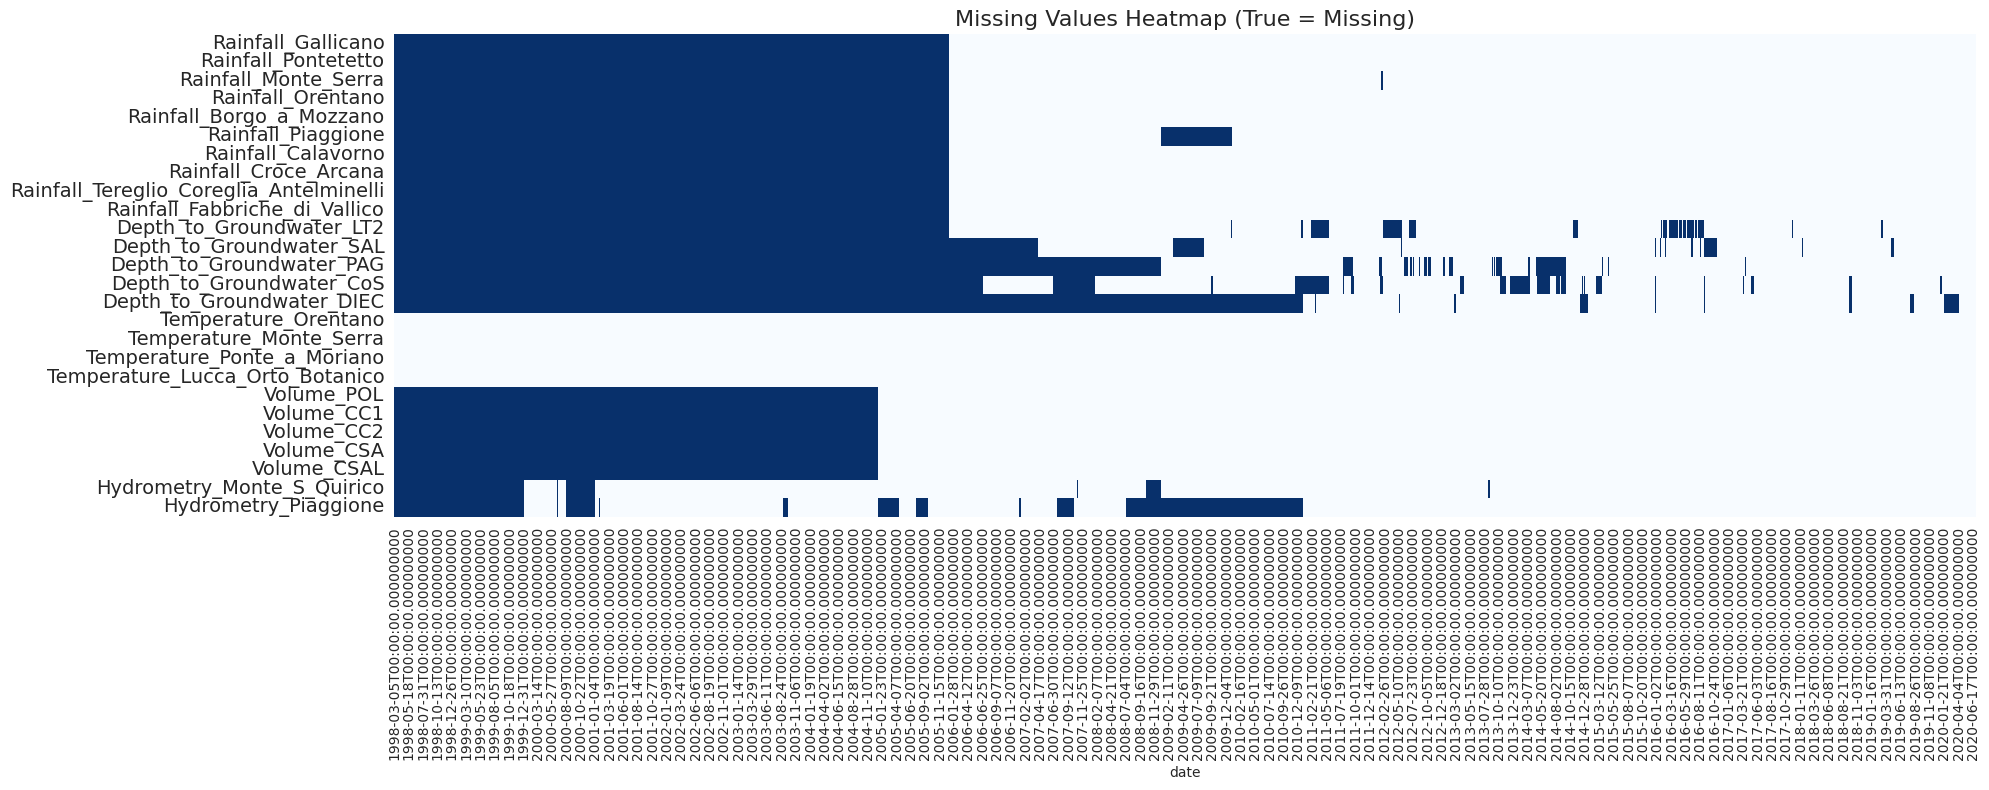

--- End of Analysis ---



In [152]:
missing_handler = TimeSeriesMissingHandler(auser)
missing_handler.base_analysis()

In [153]:
missing_handler.trim_missing('start', 2)


Attempting to trim (how='start') based on threshold: >= 2 missing columns in data cols.
Trimming 4686 rows from the start.
Total rows trimmed: 4686
DataFrame shape after trimming: (3468, 27)



--- Missing Value Analysis ---
Columns with missing values (%):
- Depth_to_Groundwater_CoS: 15.28% (530 values)
- Depth_to_Groundwater_LT2: 13.75% (477 values)
- Depth_to_Groundwater_PAG: 11.30% (392 values)
- Depth_to_Groundwater_DIEC: 5.71% (198 values)
- Depth_to_Groundwater_SAL: 3.72% (129 values)
- Hydrometry_Monte_S_Quirico: 0.26% (9 values)
- Hydrometry_Piaggione: 0.20% (7 values)
- Rainfall_Monte_Serra: 0.17% (6 values)

Displaying Missing Value Heatmap...


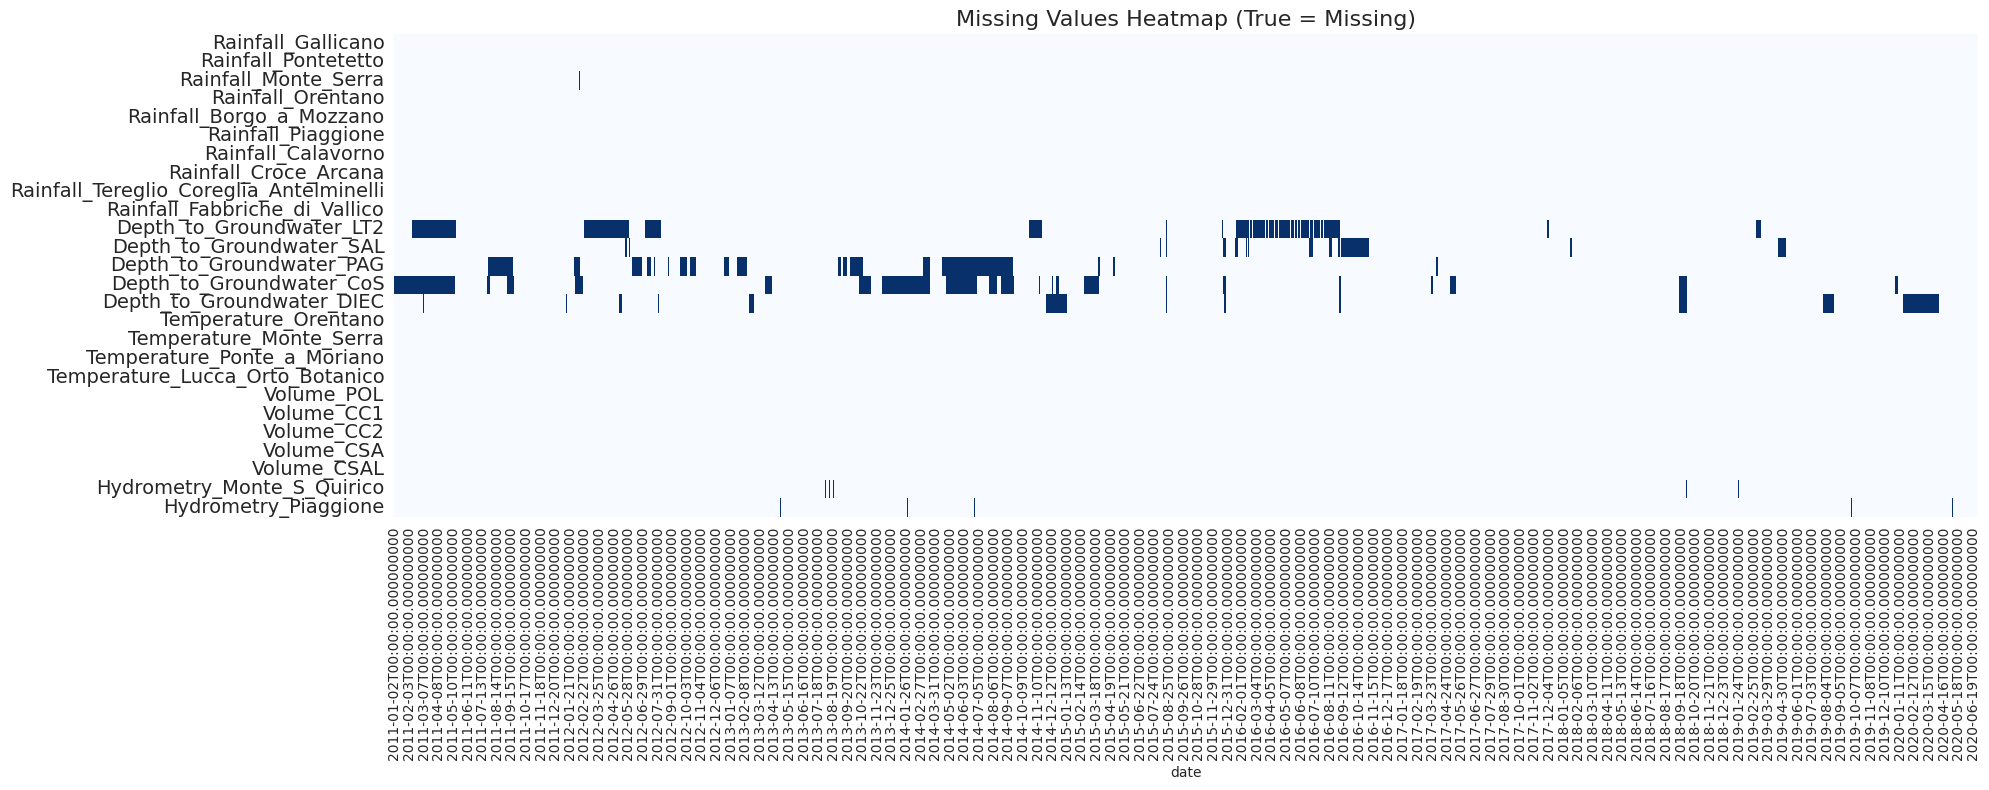

--- End of Analysis ---



In [154]:
missing_handler.base_analysis()


--- Visualizing Imputation for column: Depth_to_Groundwater_CoS ---


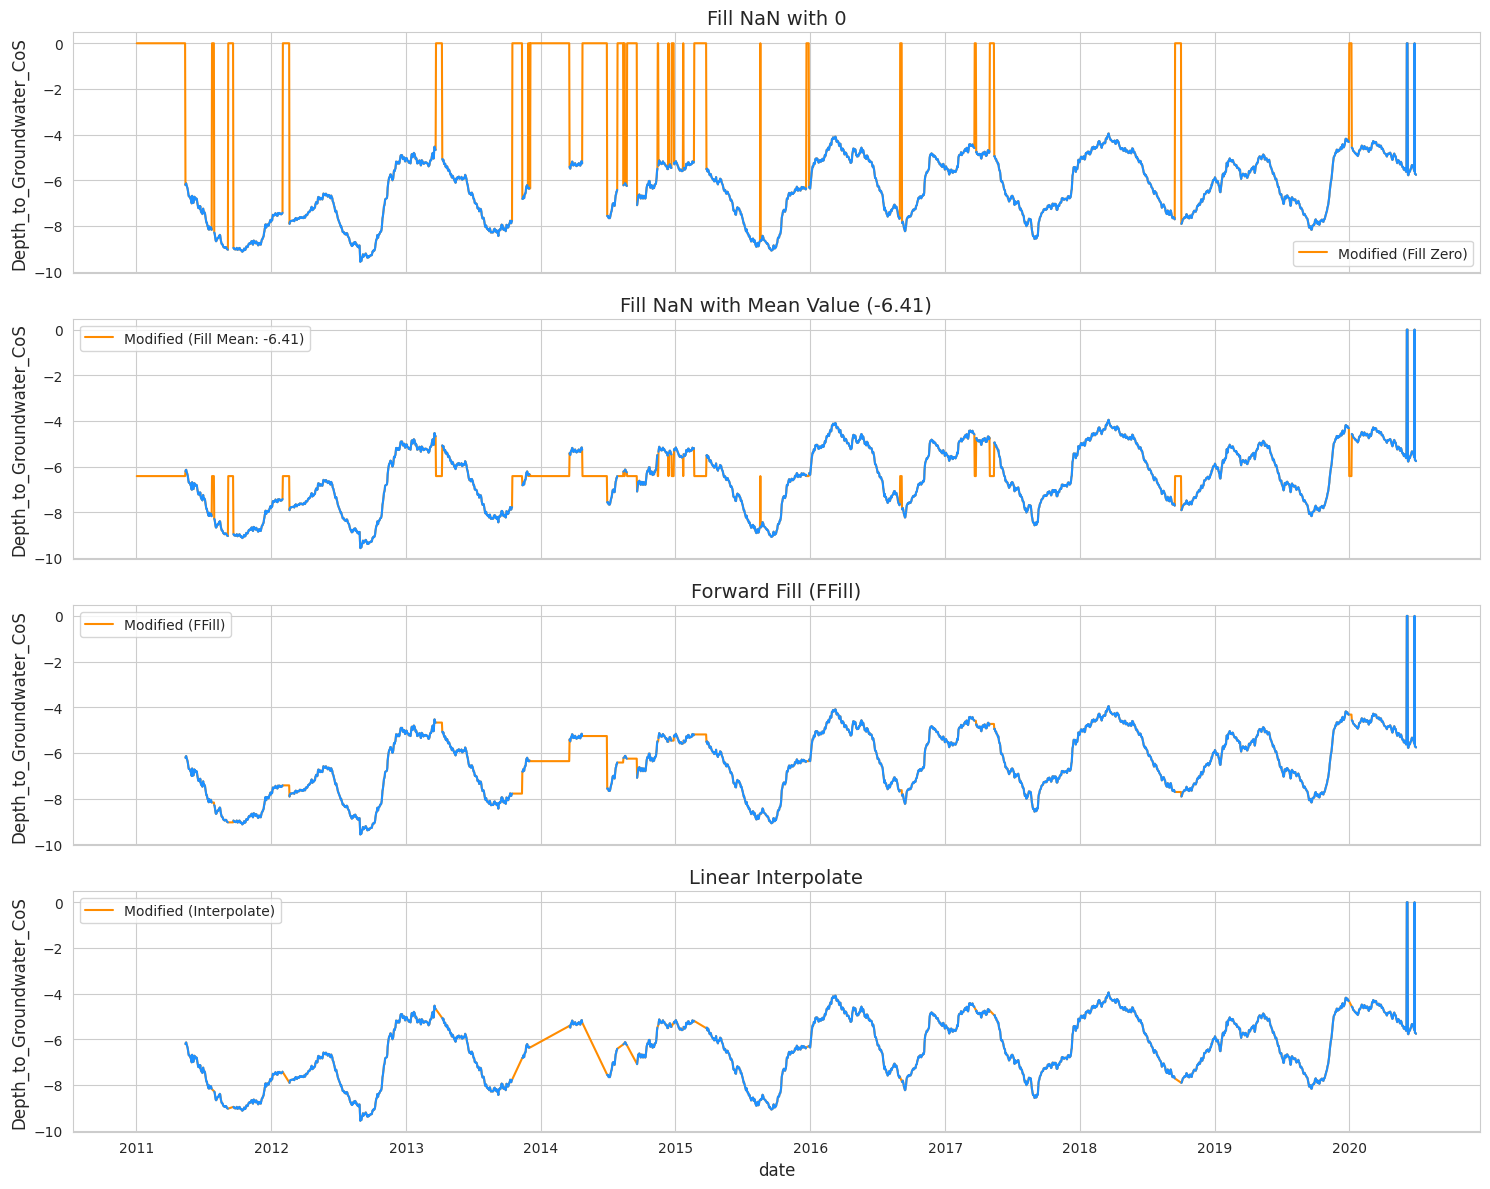

--- End of Visualization ---



In [155]:
missing_handler.visualize_imputation('Depth_to_Groundwater_CoS')


--- Visualizing Imputation for column: Depth_to_Groundwater_LT2 ---


/workspaces/foundation-covariate-forecasting/src/timeseries/preprocessing/preprocessing.py:670: UserWarning: 
The palette list has fewer values (477) than needed (478) and will cycle, which may produce an uninterpretable plot.
  sns.lineplot(x=temp_df[self._date_col], y=original_series, ax=ax[0], hue=original_series.isna().cumsum(), palette=['dodgerblue']*sum(original_series.isna()), legend=False, markers=True)
/workspaces/foundation-covariate-forecasting/src/timeseries/preprocessing/preprocessing.py:677: UserWarning: 
The palette list has fewer values (477) than needed (478) and will cycle, which may produce an uninterpretable plot.
  sns.lineplot(x=temp_df[self._date_col], y=original_series, ax=ax[1], hue=original_series.isna().cumsum(), palette=['dodgerblue']*sum(original_series.isna()), legend=False, markers=True)
/workspaces/foundation-covariate-forecasting/src/timeseries/preprocessing/preprocessing.py:684: UserWarning: 
The palette list has fewer values (477) than needed (478) an

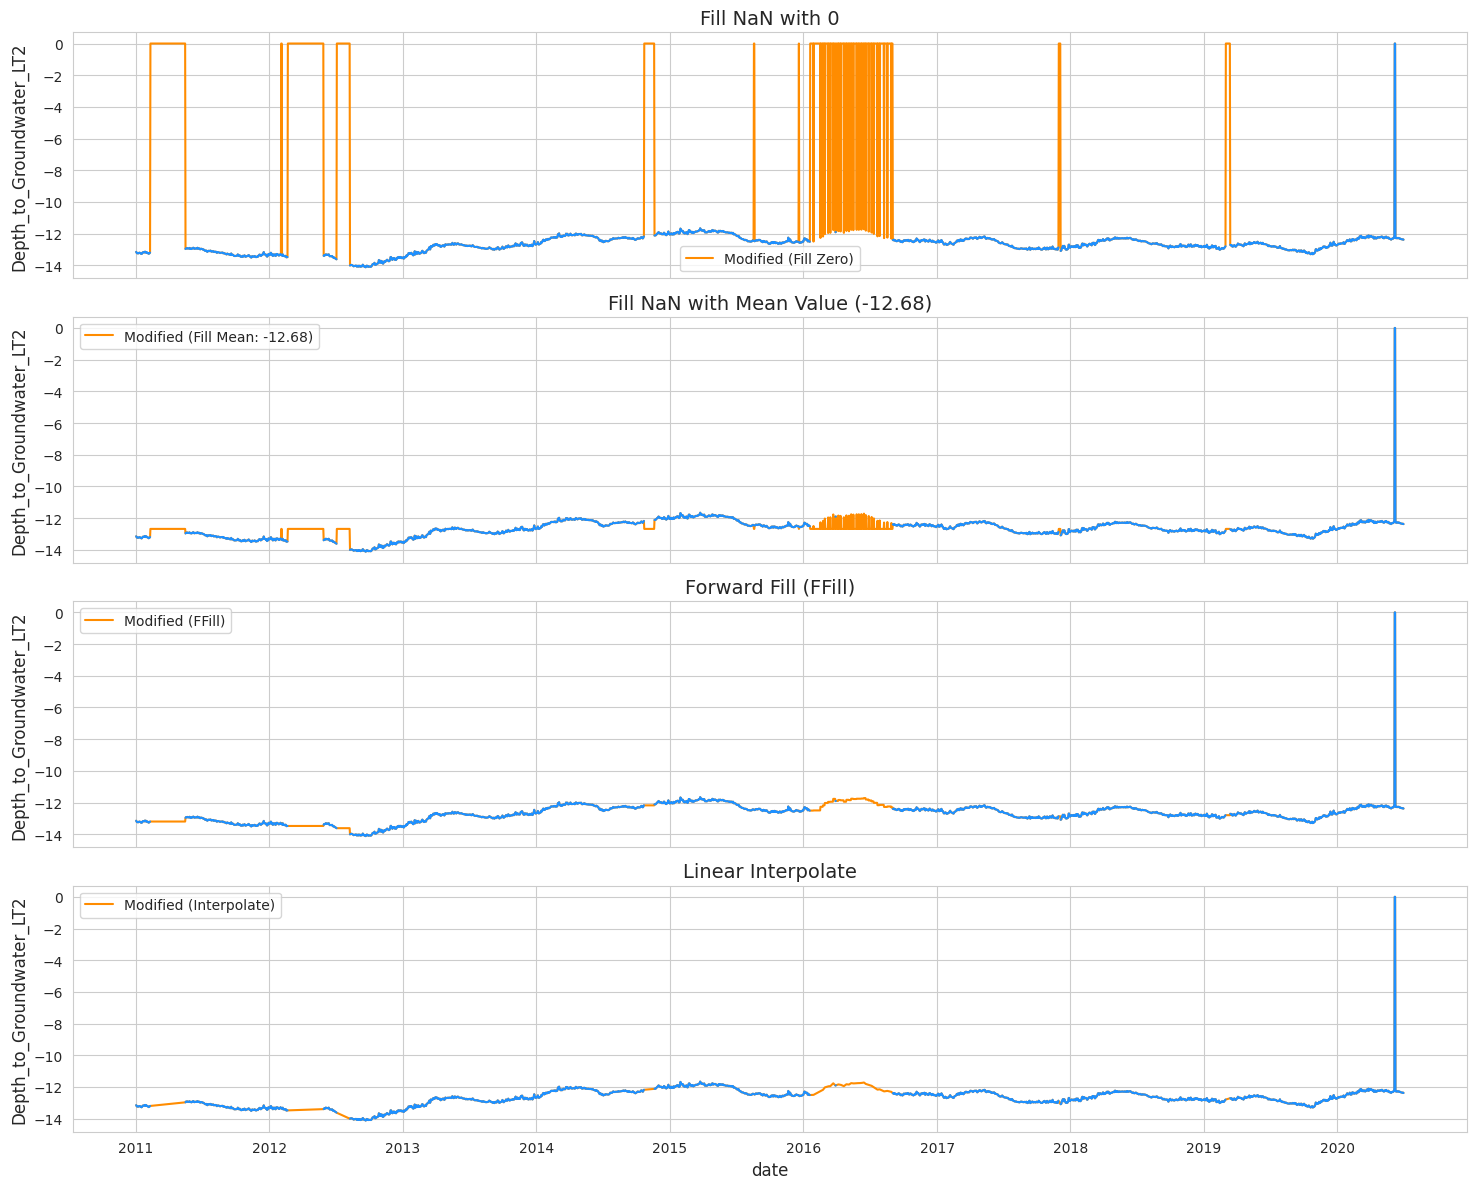

--- End of Visualization ---



In [156]:
missing_handler.visualize_imputation('Depth_to_Groundwater_LT2')

In [157]:
missing_handler.apply_imputation('interpolate')
missing_handler.trim_missing()
auser = missing_handler.processed_df


--- Applying Imputation ---
Applying single strategy 'interpolate' to all data columns.
  Column 'Rainfall_Gallicano' has no missing values. Skipping.
  Column 'Rainfall_Pontetetto' has no missing values. Skipping.
  Applying method 'interpolate' to column 'Rainfall_Monte_Serra'...
    Filled using linear interpolation.
  Column 'Rainfall_Orentano' has no missing values. Skipping.
  Column 'Rainfall_Borgo_a_Mozzano' has no missing values. Skipping.
  Column 'Rainfall_Piaggione' has no missing values. Skipping.
  Column 'Rainfall_Calavorno' has no missing values. Skipping.
  Column 'Rainfall_Croce_Arcana' has no missing values. Skipping.
  Column 'Rainfall_Tereglio_Coreglia_Antelminelli' has no missing values. Skipping.
  Column 'Rainfall_Fabbriche_di_Vallico' has no missing values. Skipping.
  Applying method 'interpolate' to column 'Depth_to_Groundwater_LT2'...
    Filled using linear interpolation.
  Applying method 'interpolate' to column 'Depth_to_Groundwater_SAL'...
    Filled us

/workspaces/foundation-covariate-forecasting/src/timeseries/preprocessing/preprocessing.py:789: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  self.df[col_name].interpolate(method='linear', inplace=True)



Attempting to trim (how='both') based on threshold: >= 1 missing columns in data cols.
Trimming 132 rows from the start and 0 rows from the end.
Total rows trimmed: 132
DataFrame shape after trimming: (3336, 27)


In [158]:
dataset_info.add_dataset('auser', 'nature', auser, ['Depth_to_Groundwater_LT2', 'Depth_to_Groundwater_SAL', 'Depth_to_Groundwater_PAG', 'Depth_to_Groundwater_CoS', 'Depth_to_Groundwater_DIEC'])

Processed DataFrame saved to: /workspaces/foundation-covariate-forecasting/data/prepared_datasets/auser.csv


,dataset_name,domain,granularity,ts_length,num_ts,ts_names,targets,num_targets,past_covariates,num_past_covariates,future_covariates,num_future_covariates,categorical_covariates,num_categorical_covariates
14,madrid22,nature,h,4343,24,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...",[NO2],1,"[Humidity, Pressure, SolarRad, Temp, carga, in...",18,[],0,"[windDir_Categ_east, windDir_Categ_north, wind...",8
15,rideshare,human,h,541,144,"[Back Bay_Lyft_Lux, Back Bay_Lyft_Lux Black, B...","[price_max, price_mean, price_min]",3,"[api_calls, clouds, distance_max, distance_mea...",12,[],0,[],0
16,electricity_price,energy,h,50472,1,[_single_series_],[y],1,"[0__doy_cos, 0__doy_sin, 0__hour_cos, 0__hour_...",14,"[0__national_holiday, 0__Sunday, 0__Weekend]",3,"[0__national_holiday, 0__Sunday, 0__Weekend]",3
17,wind,energy,h,50424,1,[_single_series_],[y],1,"[0_cos_cluster0, 0_cos_cluster1, 0_sin_cluster...",19,[-1__Wind Onshore [MWh] Originalauflösungen],1,[],0
18,auser,nature,D,3336,1,[_single_series_],"[Depth_to_Groundwater_CoS, Depth_to_Groundwate...",5,"[Hydrometry_Monte_S_Quirico, Hydrometry_Piaggi...",21,[],0,[],0


In [159]:
doganella = pd.read_csv(RAW_DATASETS_DIR + 'Acea_Water/Aquifer_Doganella.csv')
doganella.rename(columns={'Date': 'date'}, inplace=True)
doganella['date'] = pd.to_datetime(doganella['date'], format='%d/%m/%Y')
doganella.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6026 entries, 0 to 6025
Data columns (total 22 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   date                          6026 non-null   datetime64[ns]
 1   Rainfall_Monteporzio          5399 non-null   float64       
 2   Rainfall_Velletri             5374 non-null   float64       
 3   Depth_to_Groundwater_Pozzo_1  2537 non-null   float64       
 4   Depth_to_Groundwater_Pozzo_2  2736 non-null   float64       
 5   Depth_to_Groundwater_Pozzo_3  2774 non-null   float64       
 6   Depth_to_Groundwater_Pozzo_4  2374 non-null   float64       
 7   Depth_to_Groundwater_Pozzo_5  2508 non-null   float64       
 8   Depth_to_Groundwater_Pozzo_6  2428 non-null   float64       
 9   Depth_to_Groundwater_Pozzo_7  2311 non-null   float64       
 10  Depth_to_Groundwater_Pozzo_8  2551 non-null   float64       
 11  Depth_to_Groundwater_Pozzo_9  

TimeSeriesMissingHandler initialized. DataFrame shape: (6026, 22)
Date column 'date' identified.

Attempting to trim (how='both') based on threshold: >= 1 missing columns in data cols.
Trimming 5486 rows from the start and 0 rows from the end.
Total rows trimmed: 5486
DataFrame shape after trimming: (540, 22)

--- Missing Value Analysis ---
Columns with missing values (%):
- Depth_to_Groundwater_Pozzo_3: 32.41% (175 values)
- Depth_to_Groundwater_Pozzo_4: 29.63% (160 values)
- Depth_to_Groundwater_Pozzo_8: 23.70% (128 values)
- Depth_to_Groundwater_Pozzo_2: 13.70% (74 values)
- Depth_to_Groundwater_Pozzo_6: 12.22% (66 values)
- Depth_to_Groundwater_Pozzo_5: 10.74% (58 values)
- Depth_to_Groundwater_Pozzo_9: 6.67% (36 values)
- Depth_to_Groundwater_Pozzo_7: 3.89% (21 values)
- Depth_to_Groundwater_Pozzo_1: 3.15% (17 values)
- Volume_Pozzo_5+6: 0.19% (1 values)
- Temperature_Monteporzio: 0.19% (1 values)
- Volume_Pozzo_9: 0.19% (1 values)
- Volume_Pozzo_8: 0.19% (1 values)
- Volume_Pozzo

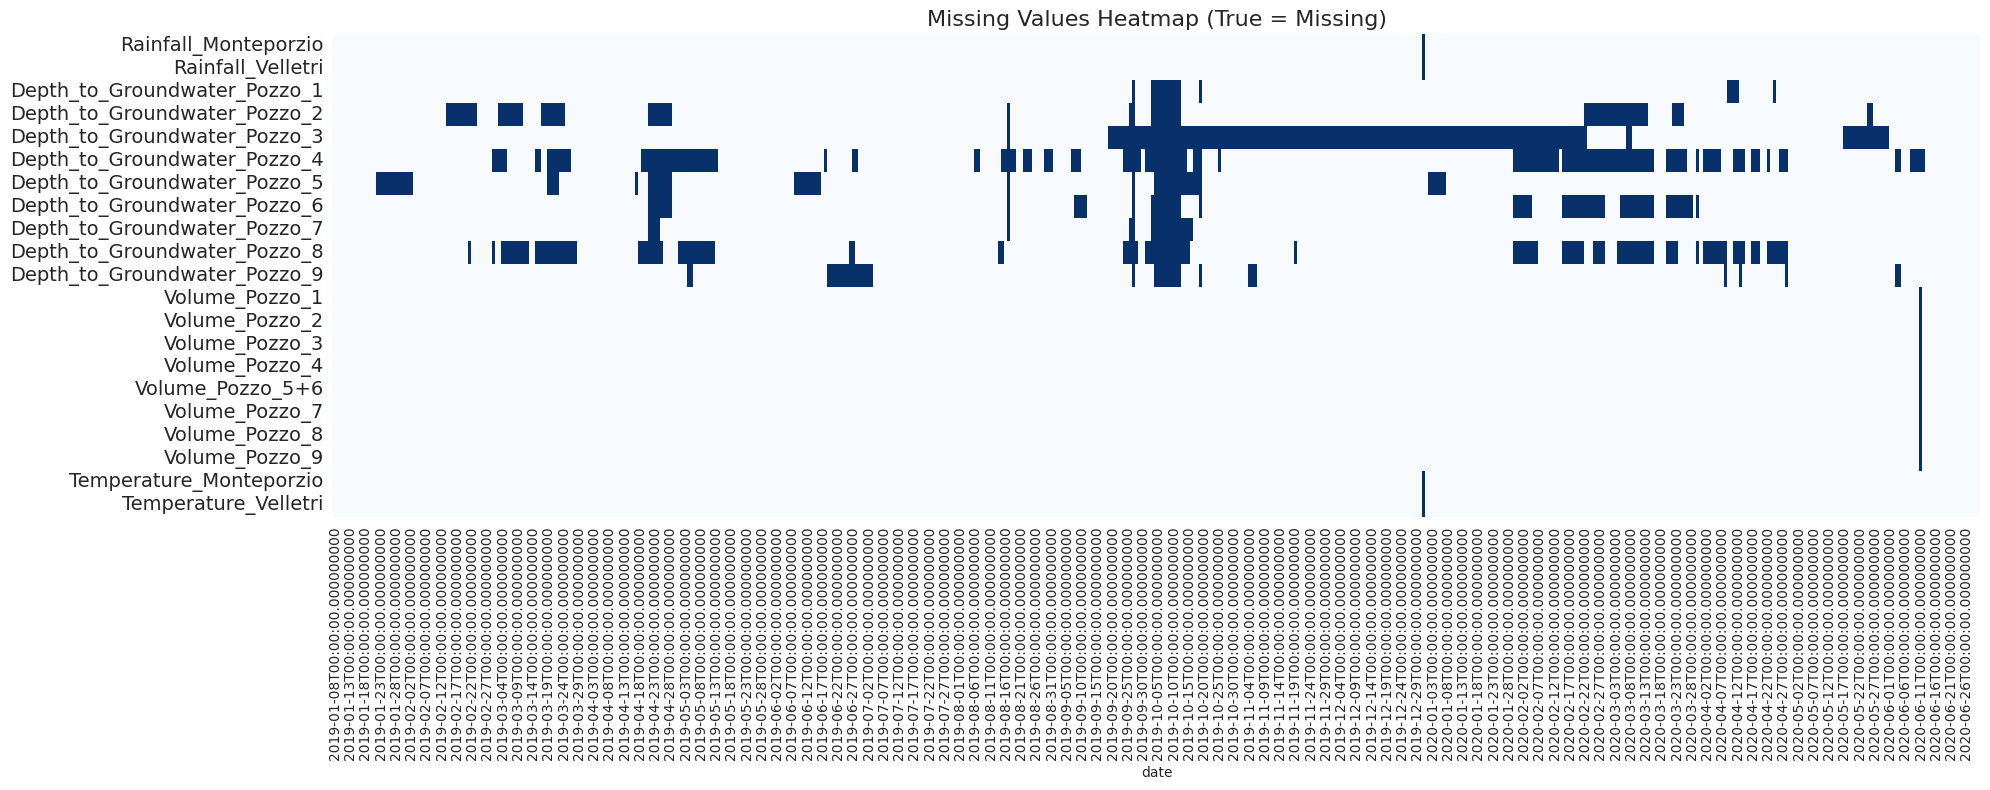

--- End of Analysis ---



In [160]:
missing_handler = TimeSeriesMissingHandler(doganella)
missing_handler.trim_missing()
missing_handler.base_analysis()

In [161]:
doganella.columns

Index(['date', 'Rainfall_Monteporzio', 'Rainfall_Velletri',
       'Depth_to_Groundwater_Pozzo_1', 'Depth_to_Groundwater_Pozzo_2',
       'Depth_to_Groundwater_Pozzo_3', 'Depth_to_Groundwater_Pozzo_4',
       'Depth_to_Groundwater_Pozzo_5', 'Depth_to_Groundwater_Pozzo_6',
       'Depth_to_Groundwater_Pozzo_7', 'Depth_to_Groundwater_Pozzo_8',
       'Depth_to_Groundwater_Pozzo_9', 'Volume_Pozzo_1', 'Volume_Pozzo_2',
       'Volume_Pozzo_3', 'Volume_Pozzo_4', 'Volume_Pozzo_5+6',
       'Volume_Pozzo_7', 'Volume_Pozzo_8', 'Volume_Pozzo_9',
       'Temperature_Monteporzio', 'Temperature_Velletri'],
      dtype='object')

In [162]:
missing_handler.apply_imputation('interpolate')
missing_handler.trim_missing()
doganella = missing_handler.processed_df


--- Applying Imputation ---
Applying single strategy 'interpolate' to all data columns.
  Applying method 'interpolate' to column 'Rainfall_Monteporzio'...
    Filled using linear interpolation.
  Applying method 'interpolate' to column 'Rainfall_Velletri'...
    Filled using linear interpolation.
  Applying method 'interpolate' to column 'Depth_to_Groundwater_Pozzo_1'...
    Filled using linear interpolation.
  Applying method 'interpolate' to column 'Depth_to_Groundwater_Pozzo_2'...
    Filled using linear interpolation.
  Applying method 'interpolate' to column 'Depth_to_Groundwater_Pozzo_3'...
    Filled using linear interpolation.
  Applying method 'interpolate' to column 'Depth_to_Groundwater_Pozzo_4'...
    Filled using linear interpolation.
  Applying method 'interpolate' to column 'Depth_to_Groundwater_Pozzo_5'...
    Filled using linear interpolation.
  Applying method 'interpolate' to column 'Depth_to_Groundwater_Pozzo_6'...
    Filled using linear interpolation.
  Applying

/workspaces/foundation-covariate-forecasting/src/timeseries/preprocessing/preprocessing.py:789: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  self.df[col_name].interpolate(method='linear', inplace=True)


In [163]:
dataset_info.add_dataset('doganella', 'nature', doganella, [f"Depth_to_Groundwater_Pozzo_{i}" for i in range(1,10)])

Processed DataFrame saved to: /workspaces/foundation-covariate-forecasting/data/prepared_datasets/doganella.csv


,dataset_name,domain,granularity,ts_length,num_ts,ts_names,targets,num_targets,past_covariates,num_past_covariates,future_covariates,num_future_covariates,categorical_covariates,num_categorical_covariates
15,rideshare,human,h,541,144,"[Back Bay_Lyft_Lux, Back Bay_Lyft_Lux Black, B...","[price_max, price_mean, price_min]",3,"[api_calls, clouds, distance_max, distance_mea...",12,[],0,[],0
16,electricity_price,energy,h,50472,1,[_single_series_],[y],1,"[0__doy_cos, 0__doy_sin, 0__hour_cos, 0__hour_...",14,"[0__national_holiday, 0__Sunday, 0__Weekend]",3,"[0__national_holiday, 0__Sunday, 0__Weekend]",3
17,wind,energy,h,50424,1,[_single_series_],[y],1,"[0_cos_cluster0, 0_cos_cluster1, 0_sin_cluster...",19,[-1__Wind Onshore [MWh] Originalauflösungen],1,[],0
18,auser,nature,D,3336,1,[_single_series_],"[Depth_to_Groundwater_CoS, Depth_to_Groundwate...",5,"[Hydrometry_Monte_S_Quirico, Hydrometry_Piaggi...",21,[],0,[],0
19,doganella,nature,D,540,1,[_single_series_],"[Depth_to_Groundwater_Pozzo_1, Depth_to_Ground...",9,"[Rainfall_Monteporzio, Rainfall_Velletri, Temp...",12,[],0,[],0


In [164]:
luco = pd.read_csv(RAW_DATASETS_DIR + 'Acea_Water/Aquifer_Luco.csv')
luco.rename(columns={'Date': 'date'}, inplace=True)
luco['date'] = pd.to_datetime(luco['date'], format='%d/%m/%Y')
luco.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7487 entries, 0 to 7486
Data columns (total 22 columns):
 #   Column                               Non-Null Count  Dtype         
---  ------                               --------------  -----         
 0   date                                 7487 non-null   datetime64[ns]
 1   Rainfall_Simignano                   6822 non-null   float64       
 2   Rainfall_Siena_Poggio_al_Vento       951 non-null    float64       
 3   Rainfall_Mensano                     1722 non-null   float64       
 4   Rainfall_Montalcinello               6525 non-null   float64       
 5   Rainfall_Monticiano_la_Pineta        2205 non-null   float64       
 6   Rainfall_Sovicille                   6657 non-null   float64       
 7   Rainfall_Ponte_Orgia                 1260 non-null   float64       
 8   Rainfall_Scorgiano                   3036 non-null   float64       
 9   Rainfall_Pentolina                   2116 non-null   float64       
 10  Rainfall_Mon

TimeSeriesMissingHandler initialized. DataFrame shape: (7487, 22)
Date column 'date' identified.

Attempting to trim (how='both') based on threshold: >= 1 missing columns in data cols.
Trimming 6536 rows from the start and 547 rows from the end.
Total rows trimmed: 7083
DataFrame shape after trimming: (404, 22)

--- Missing Value Analysis ---
Columns with missing values (%):
- Depth_to_Groundwater_Podere_Casetta: 8.66% (35 values)
- Depth_to_Groundwater_Pozzo_1: 1.49% (6 values)

Displaying Missing Value Heatmap...


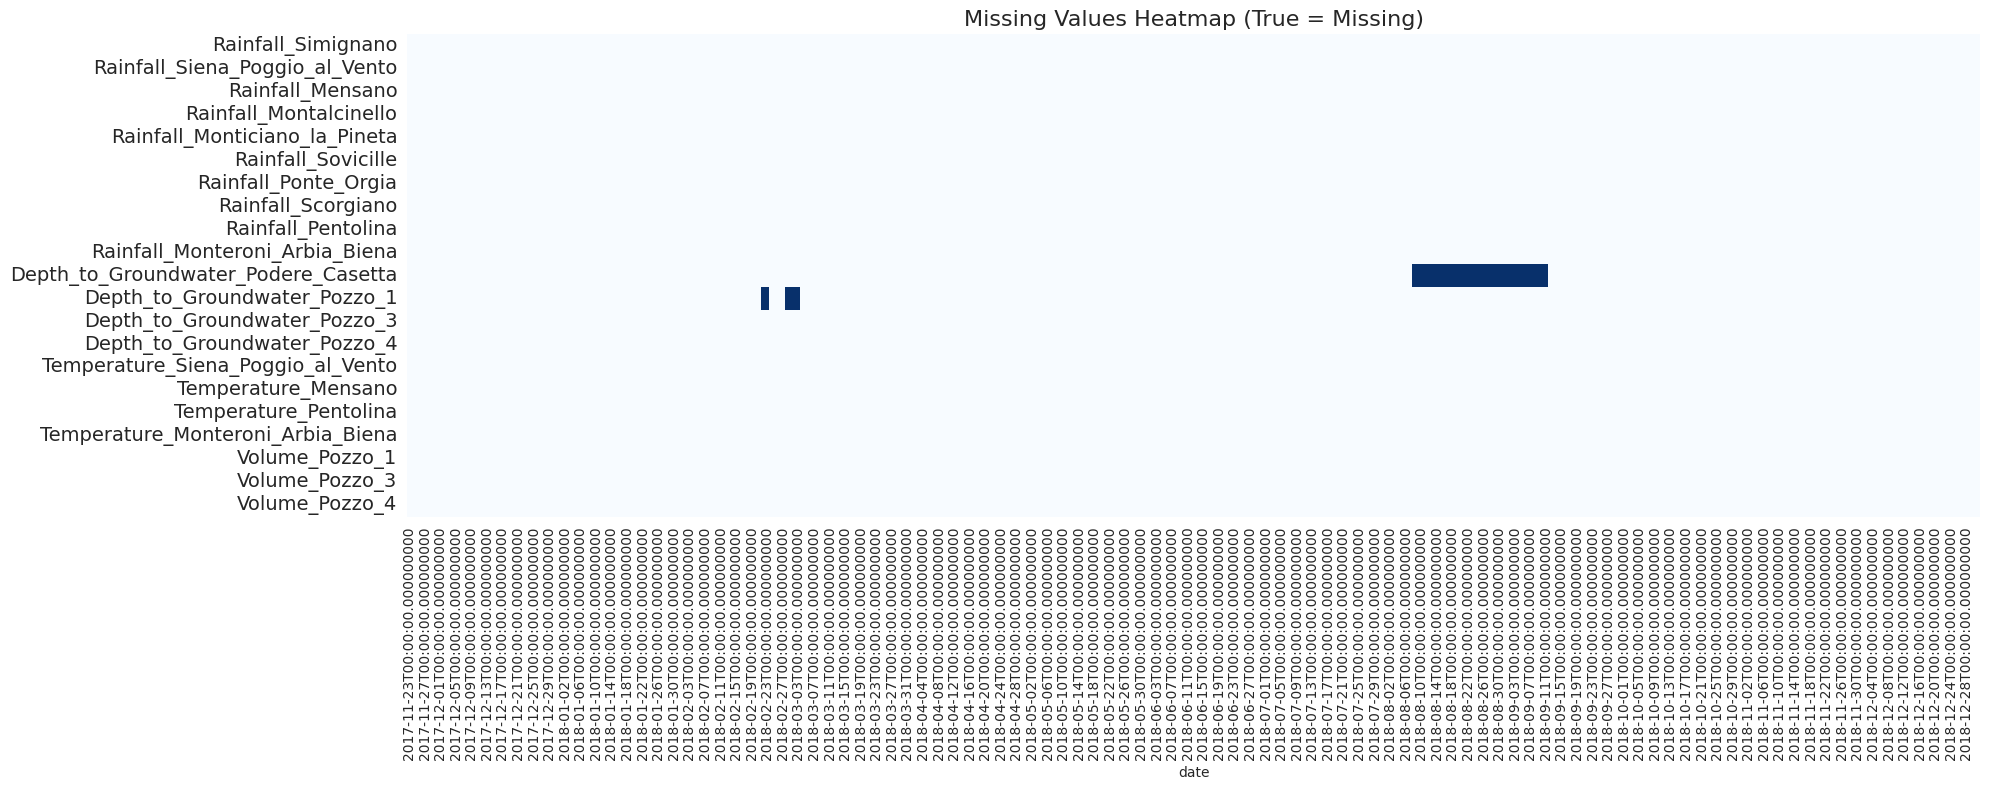

--- End of Analysis ---



In [165]:
missing_handler = TimeSeriesMissingHandler(luco)
missing_handler.trim_missing()
missing_handler.base_analysis()

In [166]:
missing_handler.apply_imputation('interpolate')
luco = missing_handler.processed_df


--- Applying Imputation ---
Applying single strategy 'interpolate' to all data columns.
  Column 'Rainfall_Simignano' has no missing values. Skipping.
  Column 'Rainfall_Siena_Poggio_al_Vento' has no missing values. Skipping.
  Column 'Rainfall_Mensano' has no missing values. Skipping.
  Column 'Rainfall_Montalcinello' has no missing values. Skipping.
  Column 'Rainfall_Monticiano_la_Pineta' has no missing values. Skipping.
  Column 'Rainfall_Sovicille' has no missing values. Skipping.
  Column 'Rainfall_Ponte_Orgia' has no missing values. Skipping.
  Column 'Rainfall_Scorgiano' has no missing values. Skipping.
  Column 'Rainfall_Pentolina' has no missing values. Skipping.
  Column 'Rainfall_Monteroni_Arbia_Biena' has no missing values. Skipping.
  Applying method 'interpolate' to column 'Depth_to_Groundwater_Podere_Casetta'...
    Filled using linear interpolation.
  Applying method 'interpolate' to column 'Depth_to_Groundwater_Pozzo_1'...
    Filled using linear interpolation.
  Col

/workspaces/foundation-covariate-forecasting/src/timeseries/preprocessing/preprocessing.py:789: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  self.df[col_name].interpolate(method='linear', inplace=True)


In [167]:
dataset_info.add_dataset('luco', 'nature', luco, ['Depth_to_Groundwater_Podere_Casetta', 'Depth_to_Groundwater_Pozzo_1', 'Depth_to_Groundwater_Pozzo_3', 'Depth_to_Groundwater_Pozzo_4'])

Processed DataFrame saved to: /workspaces/foundation-covariate-forecasting/data/prepared_datasets/luco.csv


,dataset_name,domain,granularity,ts_length,num_ts,ts_names,targets,num_targets,past_covariates,num_past_covariates,future_covariates,num_future_covariates,categorical_covariates,num_categorical_covariates
16,electricity_price,energy,h,50472,1,[_single_series_],[y],1,"[0__doy_cos, 0__doy_sin, 0__hour_cos, 0__hour_...",14,"[0__national_holiday, 0__Sunday, 0__Weekend]",3,"[0__national_holiday, 0__Sunday, 0__Weekend]",3
17,wind,energy,h,50424,1,[_single_series_],[y],1,"[0_cos_cluster0, 0_cos_cluster1, 0_sin_cluster...",19,[-1__Wind Onshore [MWh] Originalauflösungen],1,[],0
18,auser,nature,D,3336,1,[_single_series_],"[Depth_to_Groundwater_CoS, Depth_to_Groundwate...",5,"[Hydrometry_Monte_S_Quirico, Hydrometry_Piaggi...",21,[],0,[],0
19,doganella,nature,D,540,1,[_single_series_],"[Depth_to_Groundwater_Pozzo_1, Depth_to_Ground...",9,"[Rainfall_Monteporzio, Rainfall_Velletri, Temp...",12,[],0,[],0
20,luco,nature,D,404,1,[_single_series_],"[Depth_to_Groundwater_Podere_Casetta, Depth_to...",4,"[Rainfall_Mensano, Rainfall_Montalcinello, Rai...",17,[],0,[],0


In [168]:
petrignano = pd.read_csv(RAW_DATASETS_DIR + 'Acea_Water/Aquifer_Petrignano.csv')
petrignano.rename(columns={'Date': 'date'}, inplace=True)
petrignano['date'] = pd.to_datetime(petrignano['date'], format='%d/%m/%Y')
petrignano.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5223 entries, 0 to 5222
Data columns (total 8 columns):
 #   Column                                Non-Null Count  Dtype         
---  ------                                --------------  -----         
 0   date                                  5223 non-null   datetime64[ns]
 1   Rainfall_Bastia_Umbra                 4199 non-null   float64       
 2   Depth_to_Groundwater_P24              5168 non-null   float64       
 3   Depth_to_Groundwater_P25              5184 non-null   float64       
 4   Temperature_Bastia_Umbra              4199 non-null   float64       
 5   Temperature_Petrignano                4199 non-null   float64       
 6   Volume_C10_Petrignano                 5025 non-null   float64       
 7   Hydrometry_Fiume_Chiascio_Petrignano  4199 non-null   float64       
dtypes: datetime64[ns](1), float64(7)
memory usage: 326.6 KB


TimeSeriesMissingHandler initialized. DataFrame shape: (5223, 8)
Date column 'date' identified.

Attempting to trim (how='both') based on threshold: >= 1 missing columns in data cols.
Trimming 1024 rows from the start and 0 rows from the end.
Total rows trimmed: 1024
DataFrame shape after trimming: (4199, 8)

--- Missing Value Analysis ---
Columns with missing values (%):
- Depth_to_Groundwater_P24: 0.93% (39 values)
- Depth_to_Groundwater_P25: 0.64% (27 values)
- Volume_C10_Petrignano: 0.02% (1 values)

Displaying Missing Value Heatmap...


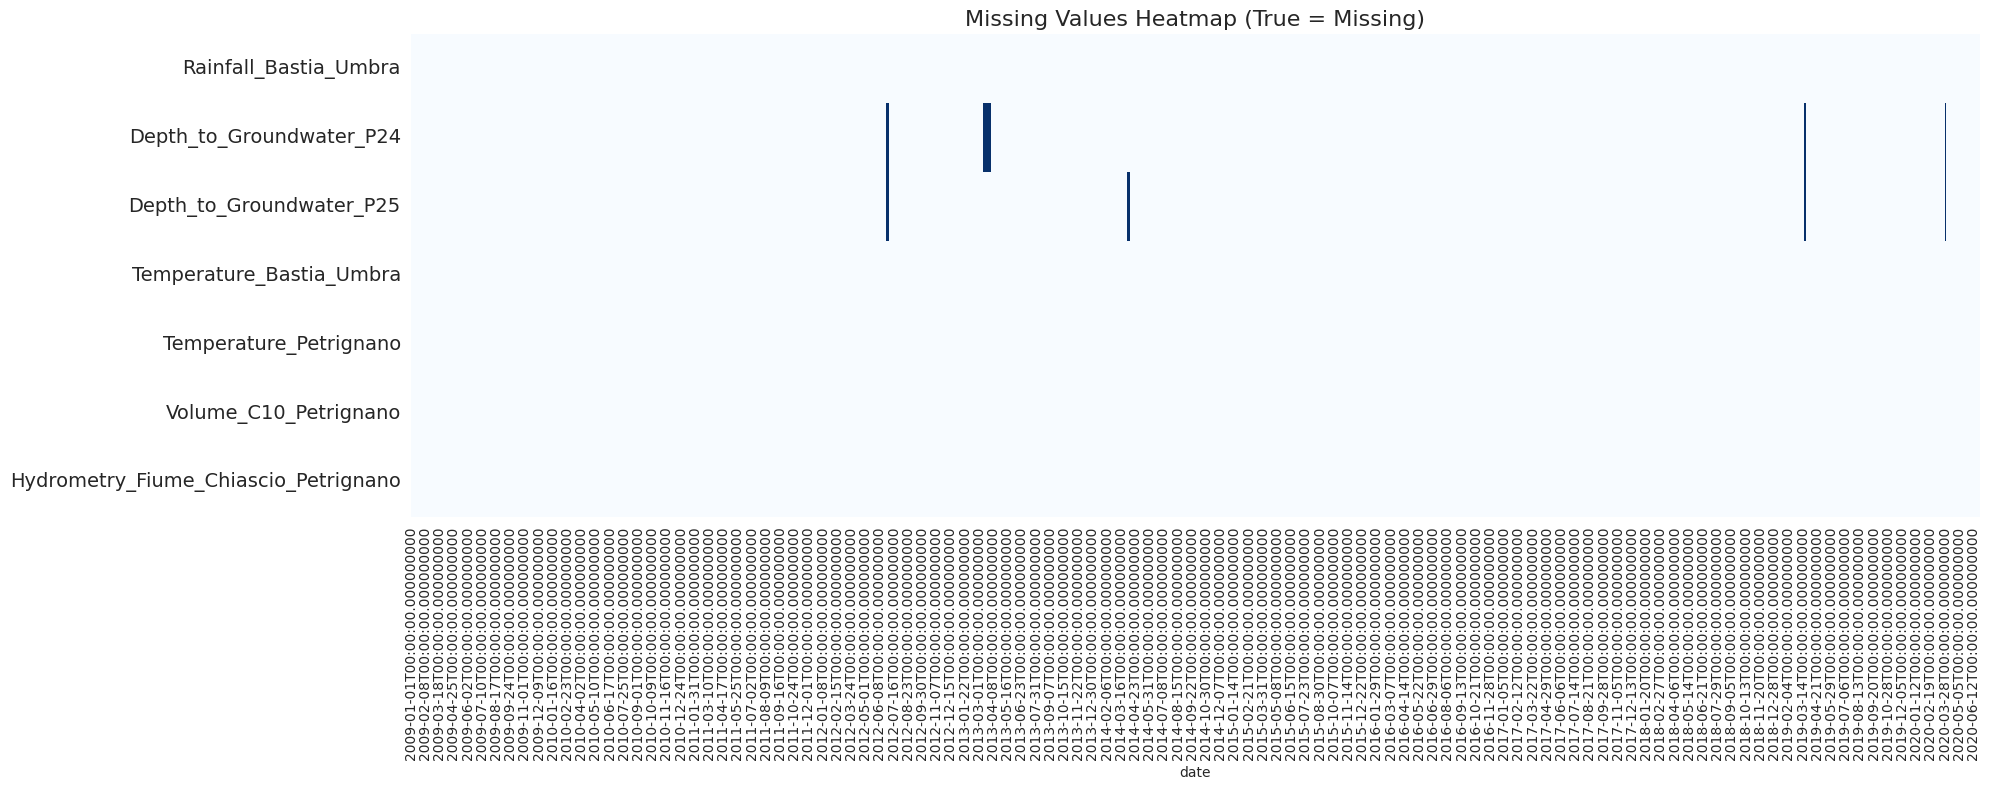

--- End of Analysis ---



In [169]:
missing_handler = TimeSeriesMissingHandler(petrignano)
missing_handler.trim_missing()
missing_handler.base_analysis()

In [170]:
missing_handler.apply_imputation('interpolate')
petrignano = missing_handler.processed_df


--- Applying Imputation ---
Applying single strategy 'interpolate' to all data columns.
  Column 'Rainfall_Bastia_Umbra' has no missing values. Skipping.
  Applying method 'interpolate' to column 'Depth_to_Groundwater_P24'...
    Filled using linear interpolation.
  Applying method 'interpolate' to column 'Depth_to_Groundwater_P25'...
    Filled using linear interpolation.
  Column 'Temperature_Bastia_Umbra' has no missing values. Skipping.
  Column 'Temperature_Petrignano' has no missing values. Skipping.
  Applying method 'interpolate' to column 'Volume_C10_Petrignano'...
    Filled using linear interpolation.
  Column 'Hydrometry_Fiume_Chiascio_Petrignano' has no missing values. Skipping.
--- Imputation Complete ---



/workspaces/foundation-covariate-forecasting/src/timeseries/preprocessing/preprocessing.py:789: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  self.df[col_name].interpolate(method='linear', inplace=True)


In [171]:
dataset_info.add_dataset('petrignano', 'nature', petrignano, ['Depth_to_Groundwater_P24', 'Depth_to_Groundwater_P25'])

Processed DataFrame saved to: /workspaces/foundation-covariate-forecasting/data/prepared_datasets/petrignano.csv


,dataset_name,domain,granularity,ts_length,num_ts,ts_names,targets,num_targets,past_covariates,num_past_covariates,future_covariates,num_future_covariates,categorical_covariates,num_categorical_covariates
17,wind,energy,h,50424,1,[_single_series_],[y],1,"[0_cos_cluster0, 0_cos_cluster1, 0_sin_cluster...",19,[-1__Wind Onshore [MWh] Originalauflösungen],1,[],0
18,auser,nature,D,3336,1,[_single_series_],"[Depth_to_Groundwater_CoS, Depth_to_Groundwate...",5,"[Hydrometry_Monte_S_Quirico, Hydrometry_Piaggi...",21,[],0,[],0
19,doganella,nature,D,540,1,[_single_series_],"[Depth_to_Groundwater_Pozzo_1, Depth_to_Ground...",9,"[Rainfall_Monteporzio, Rainfall_Velletri, Temp...",12,[],0,[],0
20,luco,nature,D,404,1,[_single_series_],"[Depth_to_Groundwater_Podere_Casetta, Depth_to...",4,"[Rainfall_Mensano, Rainfall_Montalcinello, Rai...",17,[],0,[],0
21,petrignano,nature,D,4199,1,[_single_series_],"[Depth_to_Groundwater_P24, Depth_to_Groundwate...",2,"[Hydrometry_Fiume_Chiascio_Petrignano, Rainfal...",5,[],0,[],0


In [172]:
bilancino = pd.read_csv(RAW_DATASETS_DIR + 'Acea_Water/Lake_Bilancino.csv')
bilancino.rename(columns={'Date': 'date'}, inplace=True)
bilancino['date'] = pd.to_datetime(bilancino['date'], format='%d/%m/%Y')
bilancino.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6603 entries, 0 to 6602
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   date                  6603 non-null   datetime64[ns]
 1   Rainfall_S_Piero      6026 non-null   float64       
 2   Rainfall_Mangona      6026 non-null   float64       
 3   Rainfall_S_Agata      6026 non-null   float64       
 4   Rainfall_Cavallina    6026 non-null   float64       
 5   Rainfall_Le_Croci     6026 non-null   float64       
 6   Temperature_Le_Croci  6025 non-null   float64       
 7   Lake_Level            6603 non-null   float64       
 8   Flow_Rate             6582 non-null   float64       
dtypes: datetime64[ns](1), float64(8)
memory usage: 464.4 KB


TimeSeriesMissingHandler initialized. DataFrame shape: (6603, 9)
Date column 'date' identified.

Attempting to trim (how='both') based on threshold: >= 1 missing columns in data cols.
Trimming 578 rows from the start and 0 rows from the end.
Total rows trimmed: 578
DataFrame shape after trimming: (6025, 9)

--- Missing Value Analysis ---
No missing values found in the DataFrame.

Displaying Missing Value Heatmap...


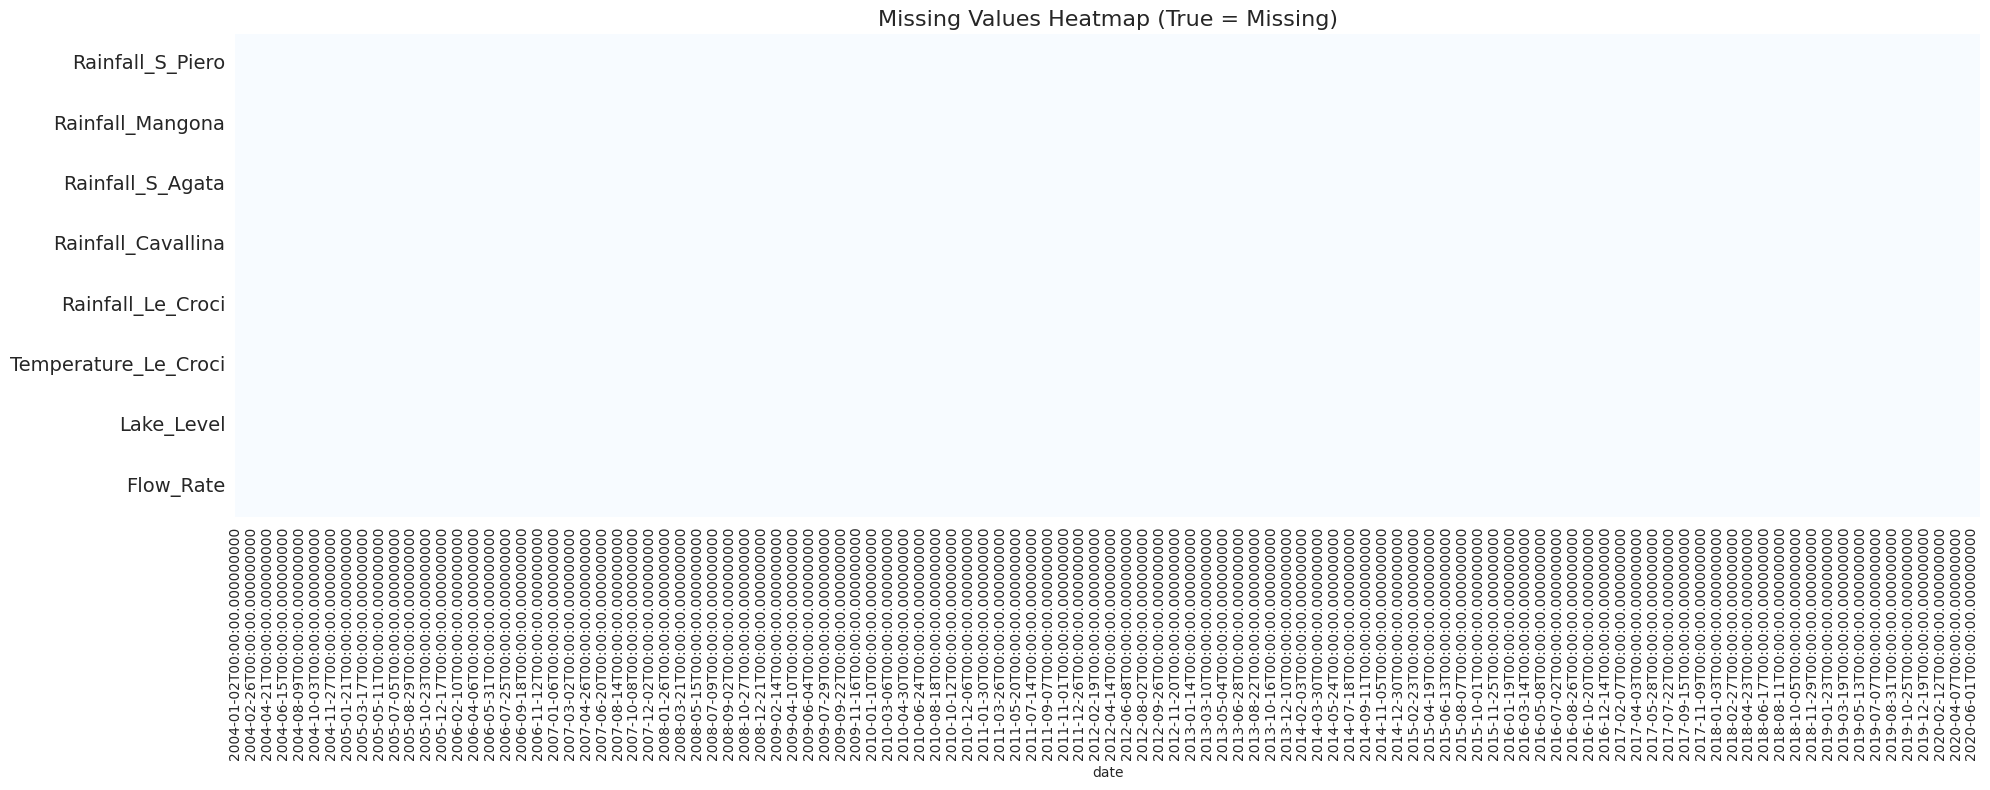

--- End of Analysis ---



In [173]:
missing_handler = TimeSeriesMissingHandler(bilancino)
missing_handler.trim_missing()
missing_handler.base_analysis()

In [174]:
bilancino = missing_handler.processed_df
dataset_info.add_dataset('bilancino', 'nature', bilancino, ['Flow_Rate'])

Processed DataFrame saved to: /workspaces/foundation-covariate-forecasting/data/prepared_datasets/bilancino.csv


,dataset_name,domain,granularity,ts_length,num_ts,ts_names,targets,num_targets,past_covariates,num_past_covariates,future_covariates,num_future_covariates,categorical_covariates,num_categorical_covariates
18,auser,nature,D,3336,1,[_single_series_],"[Depth_to_Groundwater_CoS, Depth_to_Groundwate...",5,"[Hydrometry_Monte_S_Quirico, Hydrometry_Piaggi...",21,[],0,[],0
19,doganella,nature,D,540,1,[_single_series_],"[Depth_to_Groundwater_Pozzo_1, Depth_to_Ground...",9,"[Rainfall_Monteporzio, Rainfall_Velletri, Temp...",12,[],0,[],0
20,luco,nature,D,404,1,[_single_series_],"[Depth_to_Groundwater_Podere_Casetta, Depth_to...",4,"[Rainfall_Mensano, Rainfall_Montalcinello, Rai...",17,[],0,[],0
21,petrignano,nature,D,4199,1,[_single_series_],"[Depth_to_Groundwater_P24, Depth_to_Groundwate...",2,"[Hydrometry_Fiume_Chiascio_Petrignano, Rainfal...",5,[],0,[],0
22,bilancino,nature,D,6025,1,[_single_series_],[Flow_Rate],1,"[Lake_Level, Rainfall_Cavallina, Rainfall_Le_C...",7,[],0,[],0


In [175]:
arno = pd.read_csv(RAW_DATASETS_DIR + 'Acea_Water/River_Arno.csv')
arno.rename(columns={'Date': 'date'}, inplace=True)
arno['date'] = pd.to_datetime(arno['date'], format='%d/%m/%Y')
arno.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8217 entries, 0 to 8216
Data columns (total 17 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   date                       8217 non-null   datetime64[ns]
 1   Rainfall_Le_Croci          6026 non-null   float64       
 2   Rainfall_Cavallina         6026 non-null   float64       
 3   Rainfall_S_Agata           6026 non-null   float64       
 4   Rainfall_Mangona           6026 non-null   float64       
 5   Rainfall_S_Piero           6026 non-null   float64       
 6   Rainfall_Vernio            4283 non-null   float64       
 7   Rainfall_Stia              1283 non-null   float64       
 8   Rainfall_Consuma           1283 non-null   float64       
 9   Rainfall_Incisa            4568 non-null   float64       
 10  Rainfall_Montevarchi       1647 non-null   float64       
 11  Rainfall_S_Savino          1283 non-null   float64       
 12  Rainfa

TimeSeriesMissingHandler initialized. DataFrame shape: (8217, 17)
Date column 'date' identified.

Attempting to trim (how='both') based on threshold: >= 1 missing columns in data cols.
Trimming 2191 rows from the start and 4743 rows from the end.
Total rows trimmed: 6934
DataFrame shape after trimming: (1283, 17)

--- Missing Value Analysis ---
Columns with missing values (%):
- Temperature_Firenze: 0.47% (6 values)
- Rainfall_Stia: 0.08% (1 values)
- Rainfall_Incisa: 0.08% (1 values)
- Rainfall_Montevarchi: 0.08% (1 values)

Displaying Missing Value Heatmap...


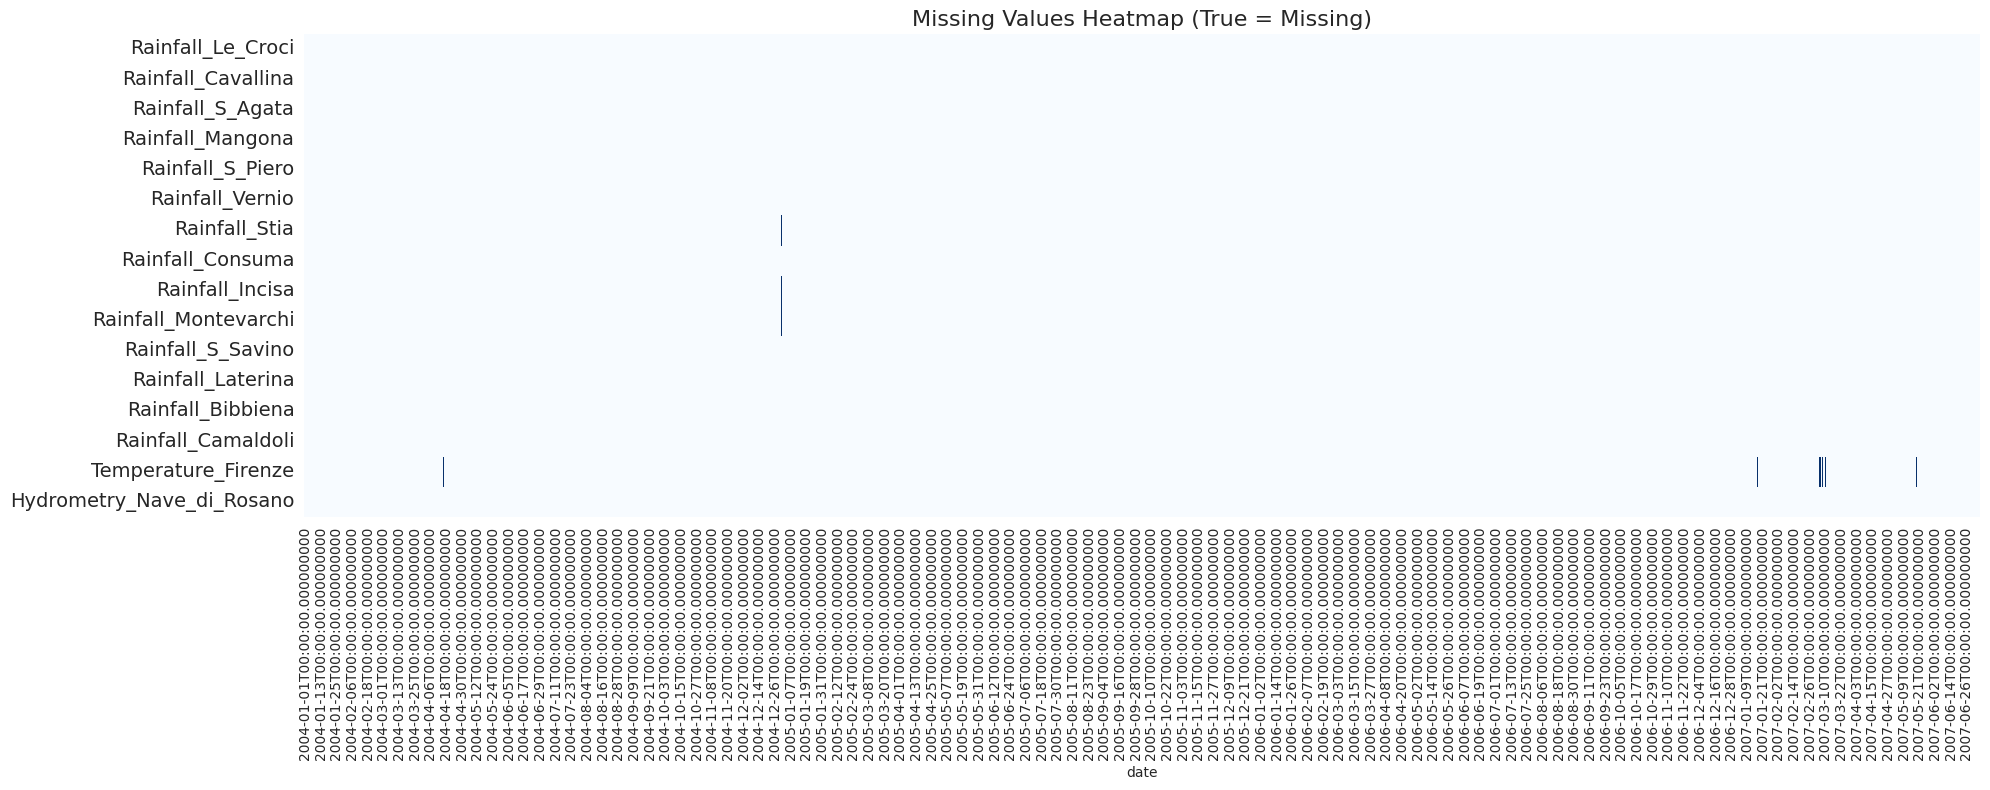

--- End of Analysis ---



In [176]:
missing_handler = TimeSeriesMissingHandler(arno)
missing_handler.trim_missing()
missing_handler.base_analysis()

In [177]:
missing_handler.apply_imputation('interpolate')
arno = missing_handler.processed_df
dataset_info.add_dataset('arno', 'nature', arno, ['Hydrometry_Nave_di_Rosano'])


--- Applying Imputation ---
Applying single strategy 'interpolate' to all data columns.
  Column 'Rainfall_Le_Croci' has no missing values. Skipping.
  Column 'Rainfall_Cavallina' has no missing values. Skipping.
  Column 'Rainfall_S_Agata' has no missing values. Skipping.
  Column 'Rainfall_Mangona' has no missing values. Skipping.
  Column 'Rainfall_S_Piero' has no missing values. Skipping.
  Column 'Rainfall_Vernio' has no missing values. Skipping.
  Applying method 'interpolate' to column 'Rainfall_Stia'...
    Filled using linear interpolation.
  Column 'Rainfall_Consuma' has no missing values. Skipping.
  Applying method 'interpolate' to column 'Rainfall_Incisa'...
    Filled using linear interpolation.
  Applying method 'interpolate' to column 'Rainfall_Montevarchi'...
    Filled using linear interpolation.
  Column 'Rainfall_S_Savino' has no missing values. Skipping.
  Column 'Rainfall_Laterina' has no missing values. Skipping.
  Column 'Rainfall_Bibbiena' has no missing value

/workspaces/foundation-covariate-forecasting/src/timeseries/preprocessing/preprocessing.py:789: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  self.df[col_name].interpolate(method='linear', inplace=True)


,dataset_name,domain,granularity,ts_length,num_ts,ts_names,targets,num_targets,past_covariates,num_past_covariates,future_covariates,num_future_covariates,categorical_covariates,num_categorical_covariates
19,doganella,nature,D,540,1,[_single_series_],"[Depth_to_Groundwater_Pozzo_1, Depth_to_Ground...",9,"[Rainfall_Monteporzio, Rainfall_Velletri, Temp...",12,[],0,[],0
20,luco,nature,D,404,1,[_single_series_],"[Depth_to_Groundwater_Podere_Casetta, Depth_to...",4,"[Rainfall_Mensano, Rainfall_Montalcinello, Rai...",17,[],0,[],0
21,petrignano,nature,D,4199,1,[_single_series_],"[Depth_to_Groundwater_P24, Depth_to_Groundwate...",2,"[Hydrometry_Fiume_Chiascio_Petrignano, Rainfal...",5,[],0,[],0
22,bilancino,nature,D,6025,1,[_single_series_],[Flow_Rate],1,"[Lake_Level, Rainfall_Cavallina, Rainfall_Le_C...",7,[],0,[],0
23,arno,nature,D,1283,1,[_single_series_],[Hydrometry_Nave_di_Rosano],1,"[Rainfall_Bibbiena, Rainfall_Camaldoli, Rainfa...",15,[],0,[],0


In [178]:
amiata = pd.read_csv(RAW_DATASETS_DIR + 'Acea_Water/Water_Spring_Amiata.csv')
amiata.rename(columns={'Date': 'date'}, inplace=True)
amiata['date'] = pd.to_datetime(amiata['date'], format='%d/%m/%Y')
amiata.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7487 entries, 0 to 7486
Data columns (total 16 columns):
 #   Column                                 Non-Null Count  Dtype         
---  ------                                 --------------  -----         
 0   date                                   7487 non-null   datetime64[ns]
 1   Rainfall_Castel_del_Piano              6291 non-null   float64       
 2   Rainfall_Abbadia_S_Salvatore           3586 non-null   float64       
 3   Rainfall_S_Fiora                       2633 non-null   float64       
 4   Rainfall_Laghetto_Verde                2865 non-null   float64       
 5   Rainfall_Vetta_Amiata                  2212 non-null   float64       
 6   Depth_to_Groundwater_S_Fiora_8         3569 non-null   float64       
 7   Depth_to_Groundwater_S_Fiora_11bis     3594 non-null   float64       
 8   Depth_to_Groundwater_David_Lazzaretti  3242 non-null   float64       
 9   Temperature_Abbadia_S_Salvatore        3583 non-null   float64 

TimeSeriesMissingHandler initialized. DataFrame shape: (7487, 16)
Date column 'date' identified.

Attempting to trim (how='both') based on threshold: >= 1 missing columns in data cols.
Trimming 5869 rows from the start and 0 rows from the end.
Total rows trimmed: 5869
DataFrame shape after trimming: (1618, 16)

--- Missing Value Analysis ---
Columns with missing values (%):
- Depth_to_Groundwater_S_Fiora_8: 35.41% (573 values)
- Depth_to_Groundwater_S_Fiora_11bis: 31.58% (511 values)
- Depth_to_Groundwater_David_Lazzaretti: 0.74% (12 values)
- Rainfall_Vetta_Amiata: 0.43% (7 values)
- Temperature_Abbadia_S_Salvatore: 0.25% (4 values)
- Rainfall_Laghetto_Verde: 0.19% (3 values)
- Temperature_Laghetto_Verde: 0.19% (3 values)

Displaying Missing Value Heatmap...


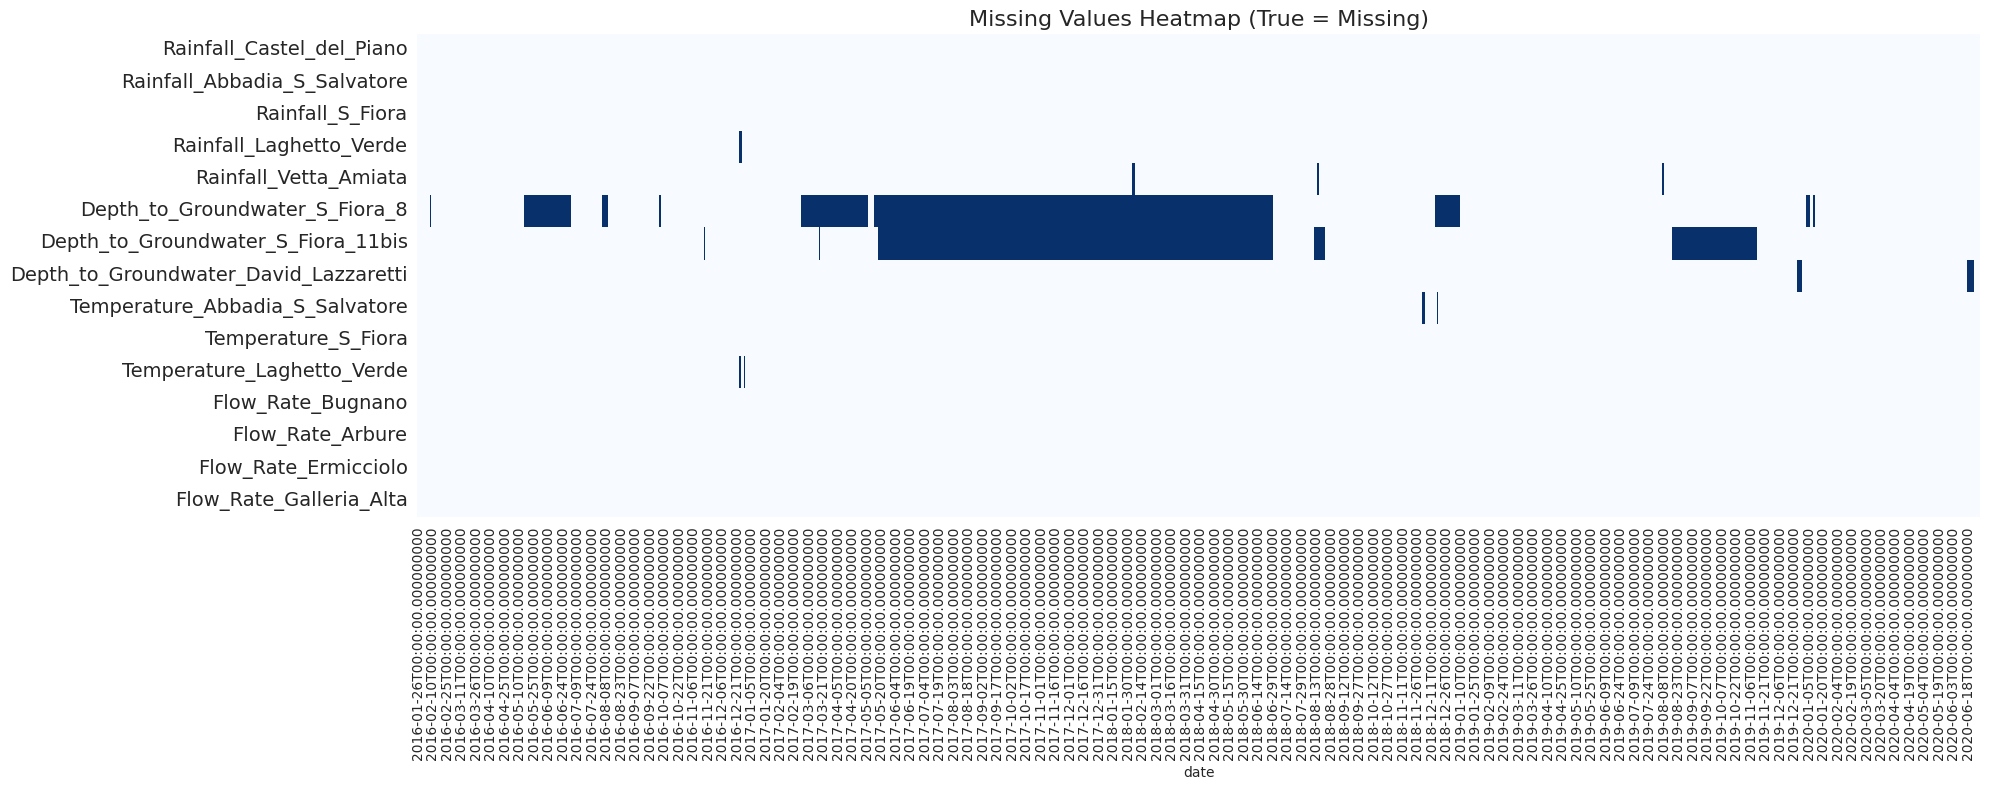

--- End of Analysis ---



In [179]:
missing_handler = TimeSeriesMissingHandler(amiata)
missing_handler.trim_missing()
missing_handler.base_analysis()


--- Visualizing Imputation for column: Depth_to_Groundwater_S_Fiora_11bis ---


/workspaces/foundation-covariate-forecasting/src/timeseries/preprocessing/preprocessing.py:670: UserWarning: 
The palette list has fewer values (511) than needed (512) and will cycle, which may produce an uninterpretable plot.
  sns.lineplot(x=temp_df[self._date_col], y=original_series, ax=ax[0], hue=original_series.isna().cumsum(), palette=['dodgerblue']*sum(original_series.isna()), legend=False, markers=True)
/workspaces/foundation-covariate-forecasting/src/timeseries/preprocessing/preprocessing.py:677: UserWarning: 
The palette list has fewer values (511) than needed (512) and will cycle, which may produce an uninterpretable plot.
  sns.lineplot(x=temp_df[self._date_col], y=original_series, ax=ax[1], hue=original_series.isna().cumsum(), palette=['dodgerblue']*sum(original_series.isna()), legend=False, markers=True)
/workspaces/foundation-covariate-forecasting/src/timeseries/preprocessing/preprocessing.py:684: UserWarning: 
The palette list has fewer values (511) than needed (512) an

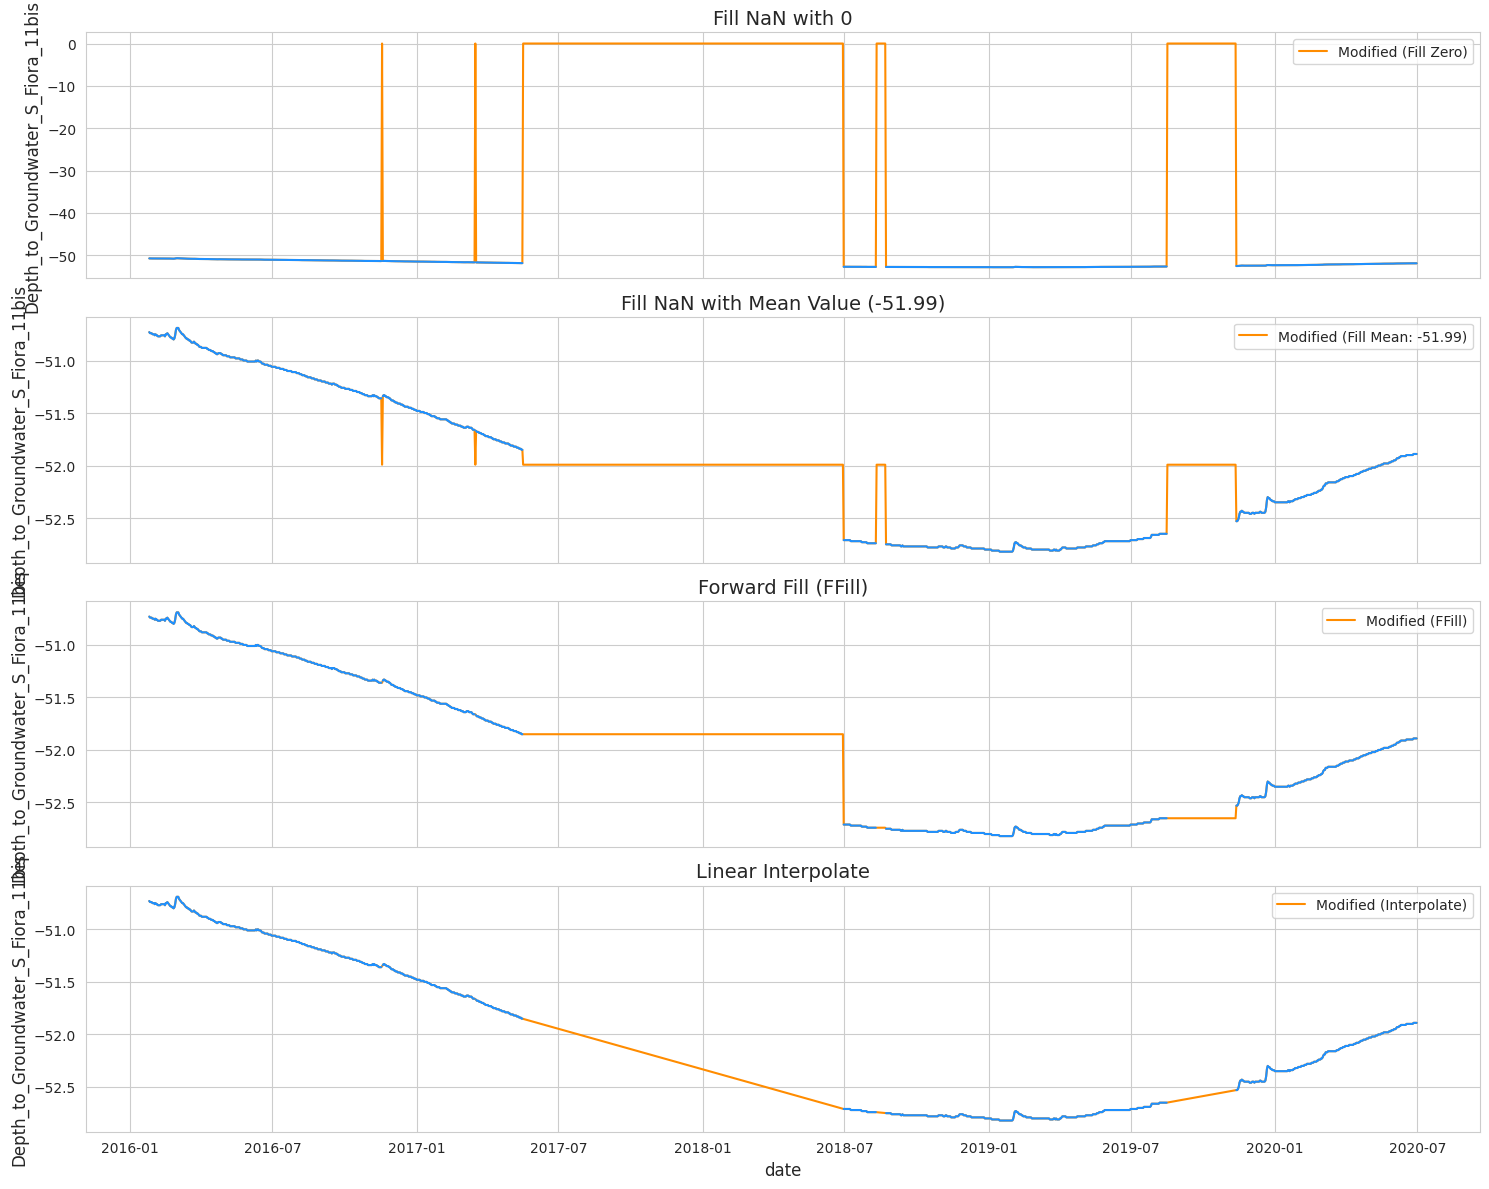

--- End of Visualization ---



In [180]:
missing_handler.visualize_imputation('Depth_to_Groundwater_S_Fiora_11bis')

In [181]:
amiata.columns

Index(['date', 'Rainfall_Castel_del_Piano', 'Rainfall_Abbadia_S_Salvatore',
       'Rainfall_S_Fiora', 'Rainfall_Laghetto_Verde', 'Rainfall_Vetta_Amiata',
       'Depth_to_Groundwater_S_Fiora_8', 'Depth_to_Groundwater_S_Fiora_11bis',
       'Depth_to_Groundwater_David_Lazzaretti',
       'Temperature_Abbadia_S_Salvatore', 'Temperature_S_Fiora',
       'Temperature_Laghetto_Verde', 'Flow_Rate_Bugnano', 'Flow_Rate_Arbure',
       'Flow_Rate_Ermicciolo', 'Flow_Rate_Galleria_Alta'],
      dtype='object')

In [182]:
missing_handler.apply_imputation('interpolate')
missing_handler.trim_missing()
amiata = missing_handler.processed_df
dataset_info.add_dataset('amiata', 'nature', amiata, ['Flow_Rate_Bugnano', 'Flow_Rate_Arbure', 'Flow_Rate_Ermicciolo', 'Flow_Rate_Galleria_Alta'])


--- Applying Imputation ---
Applying single strategy 'interpolate' to all data columns.
  Column 'Rainfall_Castel_del_Piano' has no missing values. Skipping.
  Column 'Rainfall_Abbadia_S_Salvatore' has no missing values. Skipping.
  Column 'Rainfall_S_Fiora' has no missing values. Skipping.
  Applying method 'interpolate' to column 'Rainfall_Laghetto_Verde'...
    Filled using linear interpolation.
  Applying method 'interpolate' to column 'Rainfall_Vetta_Amiata'...
    Filled using linear interpolation.
  Applying method 'interpolate' to column 'Depth_to_Groundwater_S_Fiora_8'...
    Filled using linear interpolation.
  Applying method 'interpolate' to column 'Depth_to_Groundwater_S_Fiora_11bis'...
    Filled using linear interpolation.
  Applying method 'interpolate' to column 'Depth_to_Groundwater_David_Lazzaretti'...
    Filled using linear interpolation.
  Applying method 'interpolate' to column 'Temperature_Abbadia_S_Salvatore'...
    Filled using linear interpolation.
  Column 

/workspaces/foundation-covariate-forecasting/src/timeseries/preprocessing/preprocessing.py:789: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  self.df[col_name].interpolate(method='linear', inplace=True)


,dataset_name,domain,granularity,ts_length,num_ts,ts_names,targets,num_targets,past_covariates,num_past_covariates,future_covariates,num_future_covariates,categorical_covariates,num_categorical_covariates
20,luco,nature,D,404,1,[_single_series_],"[Depth_to_Groundwater_Podere_Casetta, Depth_to...",4,"[Rainfall_Mensano, Rainfall_Montalcinello, Rai...",17,[],0,[],0
21,petrignano,nature,D,4199,1,[_single_series_],"[Depth_to_Groundwater_P24, Depth_to_Groundwate...",2,"[Hydrometry_Fiume_Chiascio_Petrignano, Rainfal...",5,[],0,[],0
22,bilancino,nature,D,6025,1,[_single_series_],[Flow_Rate],1,"[Lake_Level, Rainfall_Cavallina, Rainfall_Le_C...",7,[],0,[],0
23,arno,nature,D,1283,1,[_single_series_],[Hydrometry_Nave_di_Rosano],1,"[Rainfall_Bibbiena, Rainfall_Camaldoli, Rainfa...",15,[],0,[],0
24,amiata,nature,D,1618,1,[_single_series_],"[Flow_Rate_Arbure, Flow_Rate_Bugnano, Flow_Rat...",4,"[Depth_to_Groundwater_David_Lazzaretti, Depth_...",11,[],0,[],0


In [183]:
lupa = pd.read_csv(RAW_DATASETS_DIR + 'Acea_Water/Water_Spring_Lupa.csv')
lupa.rename(columns={'Date': 'date'}, inplace=True)
lupa['date'] = pd.to_datetime(lupa['date'], format='%d/%m/%Y')
lupa.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4199 entries, 0 to 4198
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   date            4199 non-null   datetime64[ns]
 1   Rainfall_Terni  4199 non-null   float64       
 2   Flow_Rate_Lupa  3817 non-null   float64       
dtypes: datetime64[ns](1), float64(2)
memory usage: 98.5 KB


TimeSeriesMissingHandler initialized. DataFrame shape: (4199, 3)
Date column 'date' identified.

Attempting to trim (how='both') based on threshold: >= 1 missing columns in data cols.
Trimming 49 rows from the start and 0 rows from the end.
Total rows trimmed: 49
DataFrame shape after trimming: (4150, 3)

--- Missing Value Analysis ---
Columns with missing values (%):
- Flow_Rate_Lupa: 8.02% (333 values)

Displaying Missing Value Heatmap...


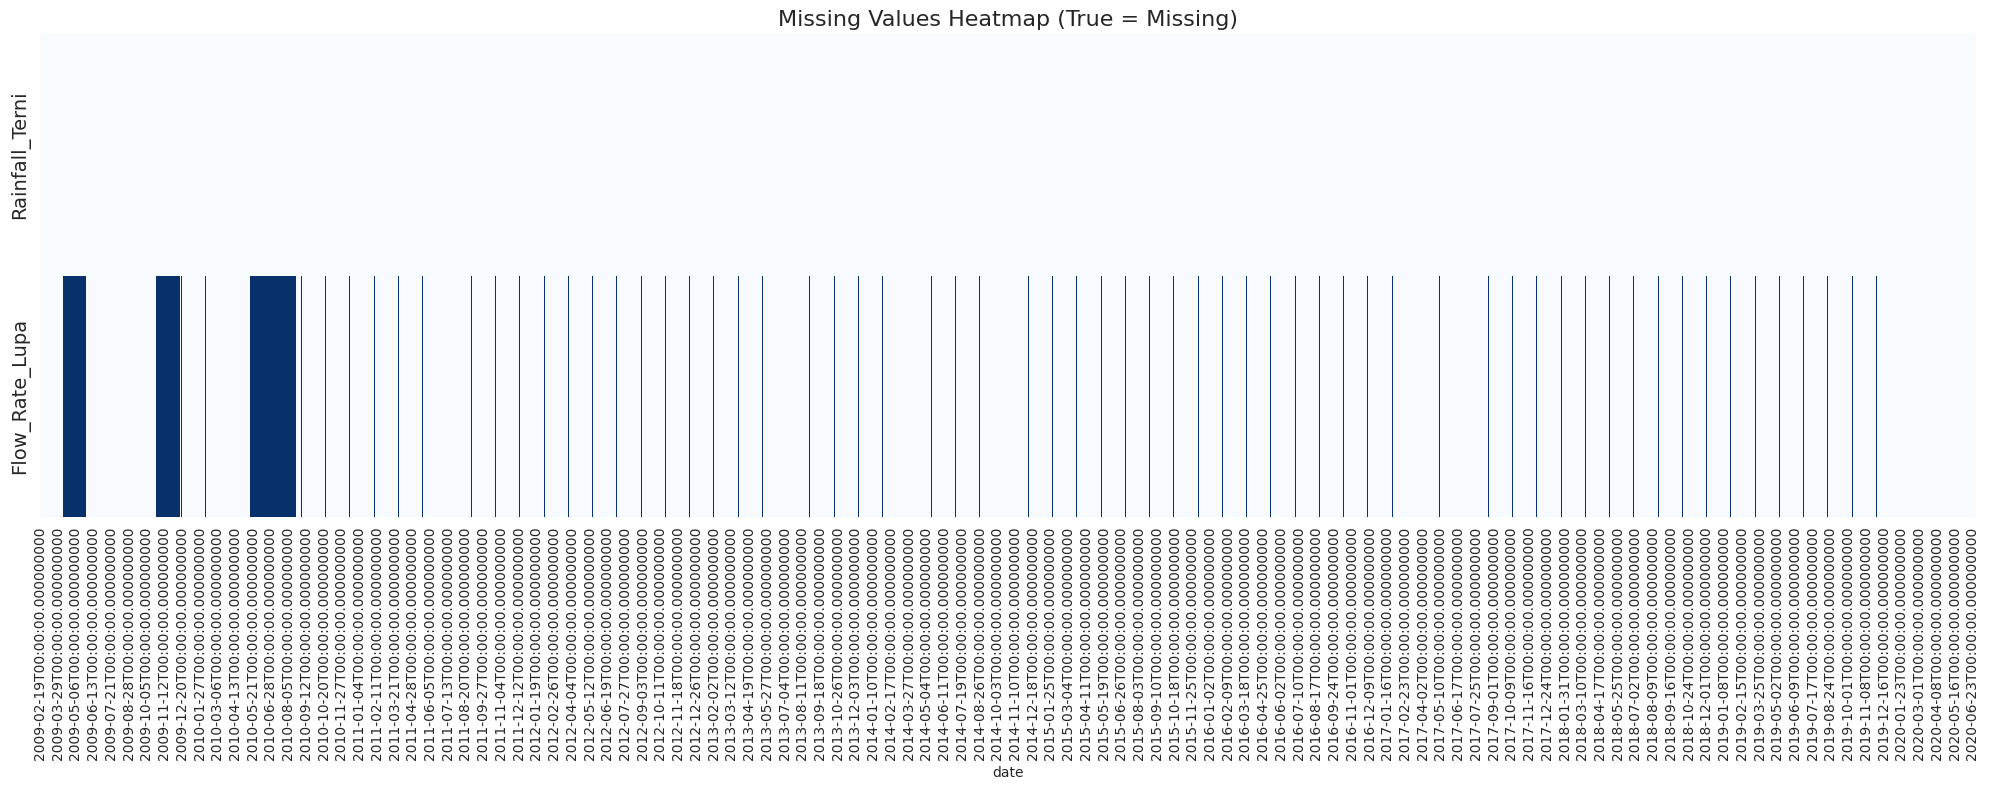

--- End of Analysis ---



In [184]:
missing_handler = TimeSeriesMissingHandler(lupa)
missing_handler.trim_missing()
missing_handler.base_analysis()


--- Visualizing Imputation for column: Flow_Rate_Lupa ---


/workspaces/foundation-covariate-forecasting/src/timeseries/preprocessing/preprocessing.py:670: UserWarning: 
The palette list has fewer values (333) than needed (334) and will cycle, which may produce an uninterpretable plot.
  sns.lineplot(x=temp_df[self._date_col], y=original_series, ax=ax[0], hue=original_series.isna().cumsum(), palette=['dodgerblue']*sum(original_series.isna()), legend=False, markers=True)
/workspaces/foundation-covariate-forecasting/src/timeseries/preprocessing/preprocessing.py:677: UserWarning: 
The palette list has fewer values (333) than needed (334) and will cycle, which may produce an uninterpretable plot.
  sns.lineplot(x=temp_df[self._date_col], y=original_series, ax=ax[1], hue=original_series.isna().cumsum(), palette=['dodgerblue']*sum(original_series.isna()), legend=False, markers=True)
/workspaces/foundation-covariate-forecasting/src/timeseries/preprocessing/preprocessing.py:684: UserWarning: 
The palette list has fewer values (333) than needed (334) an

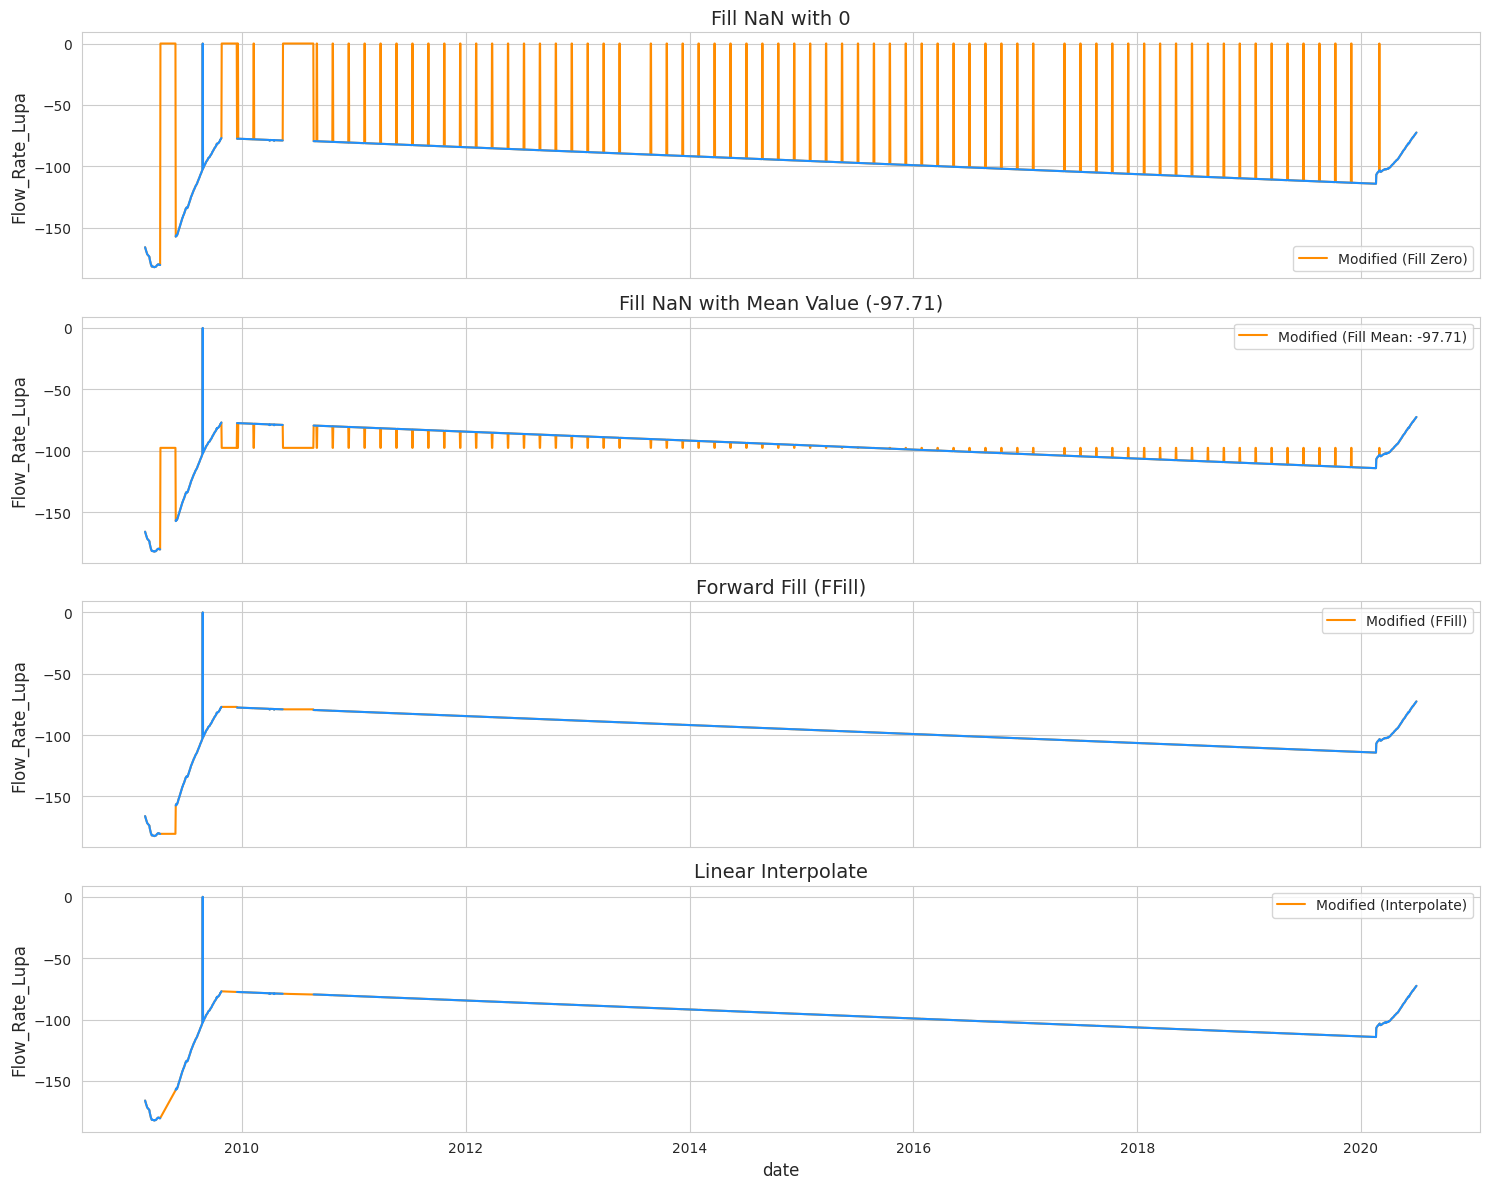

--- End of Visualization ---



In [185]:
missing_handler.visualize_imputation('Flow_Rate_Lupa')

In [186]:
missing_handler.apply_imputation('interpolate')
lupa = missing_handler.processed_df
dataset_info.add_dataset('lupa', 'nature', lupa, ['Flow_Rate_Lupa'])


--- Applying Imputation ---
Applying single strategy 'interpolate' to all data columns.
  Column 'Rainfall_Terni' has no missing values. Skipping.
  Applying method 'interpolate' to column 'Flow_Rate_Lupa'...
    Filled using linear interpolation.
--- Imputation Complete ---

Processed DataFrame saved to: /workspaces/foundation-covariate-forecasting/data/prepared_datasets/lupa.csv


/workspaces/foundation-covariate-forecasting/src/timeseries/preprocessing/preprocessing.py:789: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  self.df[col_name].interpolate(method='linear', inplace=True)


,dataset_name,domain,granularity,ts_length,num_ts,ts_names,targets,num_targets,past_covariates,num_past_covariates,future_covariates,num_future_covariates,categorical_covariates,num_categorical_covariates
21,petrignano,nature,D,4199,1,[_single_series_],"[Depth_to_Groundwater_P24, Depth_to_Groundwate...",2,"[Hydrometry_Fiume_Chiascio_Petrignano, Rainfal...",5,[],0,[],0
22,bilancino,nature,D,6025,1,[_single_series_],[Flow_Rate],1,"[Lake_Level, Rainfall_Cavallina, Rainfall_Le_C...",7,[],0,[],0
23,arno,nature,D,1283,1,[_single_series_],[Hydrometry_Nave_di_Rosano],1,"[Rainfall_Bibbiena, Rainfall_Camaldoli, Rainfa...",15,[],0,[],0
24,amiata,nature,D,1618,1,[_single_series_],"[Flow_Rate_Arbure, Flow_Rate_Bugnano, Flow_Rat...",4,"[Depth_to_Groundwater_David_Lazzaretti, Depth_...",11,[],0,[],0
25,lupa,nature,D,4150,1,[_single_series_],[Flow_Rate_Lupa],1,[Rainfall_Terni],1,[],0,[],0


In [187]:
madonna_di_canneto = pd.read_csv(RAW_DATASETS_DIR + 'Acea_Water/Water_Spring_Madonna_di_Canneto.csv')
madonna_di_canneto.rename(columns={'Date': 'date'}, inplace=True)
madonna_di_canneto['date'] = pd.to_datetime(madonna_di_canneto['date'], format='%d/%m/%Y')
madonna_di_canneto.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3113 entries, 0 to 3112
Data columns (total 4 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   date                          3104 non-null   datetime64[ns]
 1   Rainfall_Settefrati           2557 non-null   float64       
 2   Temperature_Settefrati        2557 non-null   float64       
 3   Flow_Rate_Madonna_di_Canneto  1387 non-null   float64       
dtypes: datetime64[ns](1), float64(3)
memory usage: 97.4 KB


TimeSeriesMissingHandler initialized. DataFrame shape: (3113, 4)
Date column 'date' identified.

Attempting to trim (how='both') based on threshold: >= 1 missing columns in data cols.
Trimming 1167 rows from the start and 579 rows from the end.
Total rows trimmed: 1746
DataFrame shape after trimming: (1367, 4)

--- Missing Value Analysis ---
Columns with missing values (%):
- Flow_Rate_Madonna_di_Canneto: 35.70% (488 values)

Displaying Missing Value Heatmap...


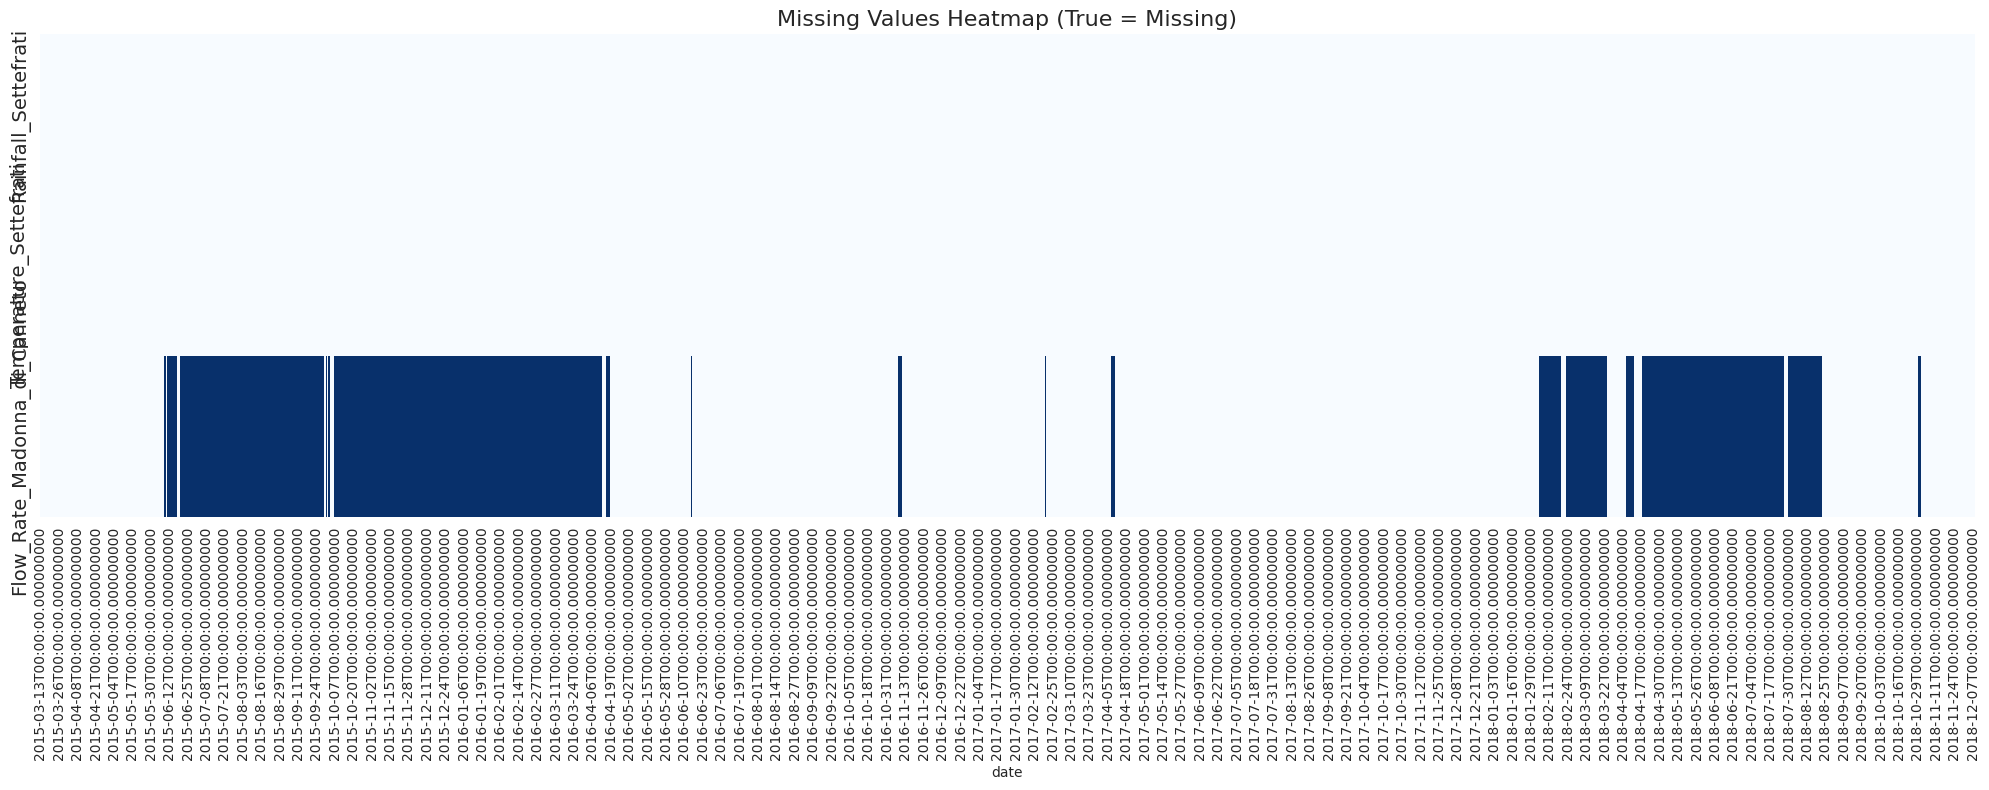

--- End of Analysis ---



In [188]:
missing_handler = TimeSeriesMissingHandler(madonna_di_canneto)
missing_handler.trim_missing()
missing_handler.base_analysis()


--- Visualizing Imputation for column: Flow_Rate_Madonna_di_Canneto ---


/workspaces/foundation-covariate-forecasting/src/timeseries/preprocessing/preprocessing.py:670: UserWarning: 
The palette list has fewer values (488) than needed (489) and will cycle, which may produce an uninterpretable plot.
  sns.lineplot(x=temp_df[self._date_col], y=original_series, ax=ax[0], hue=original_series.isna().cumsum(), palette=['dodgerblue']*sum(original_series.isna()), legend=False, markers=True)
/workspaces/foundation-covariate-forecasting/src/timeseries/preprocessing/preprocessing.py:677: UserWarning: 
The palette list has fewer values (488) than needed (489) and will cycle, which may produce an uninterpretable plot.
  sns.lineplot(x=temp_df[self._date_col], y=original_series, ax=ax[1], hue=original_series.isna().cumsum(), palette=['dodgerblue']*sum(original_series.isna()), legend=False, markers=True)
/workspaces/foundation-covariate-forecasting/src/timeseries/preprocessing/preprocessing.py:684: UserWarning: 
The palette list has fewer values (488) than needed (489) an

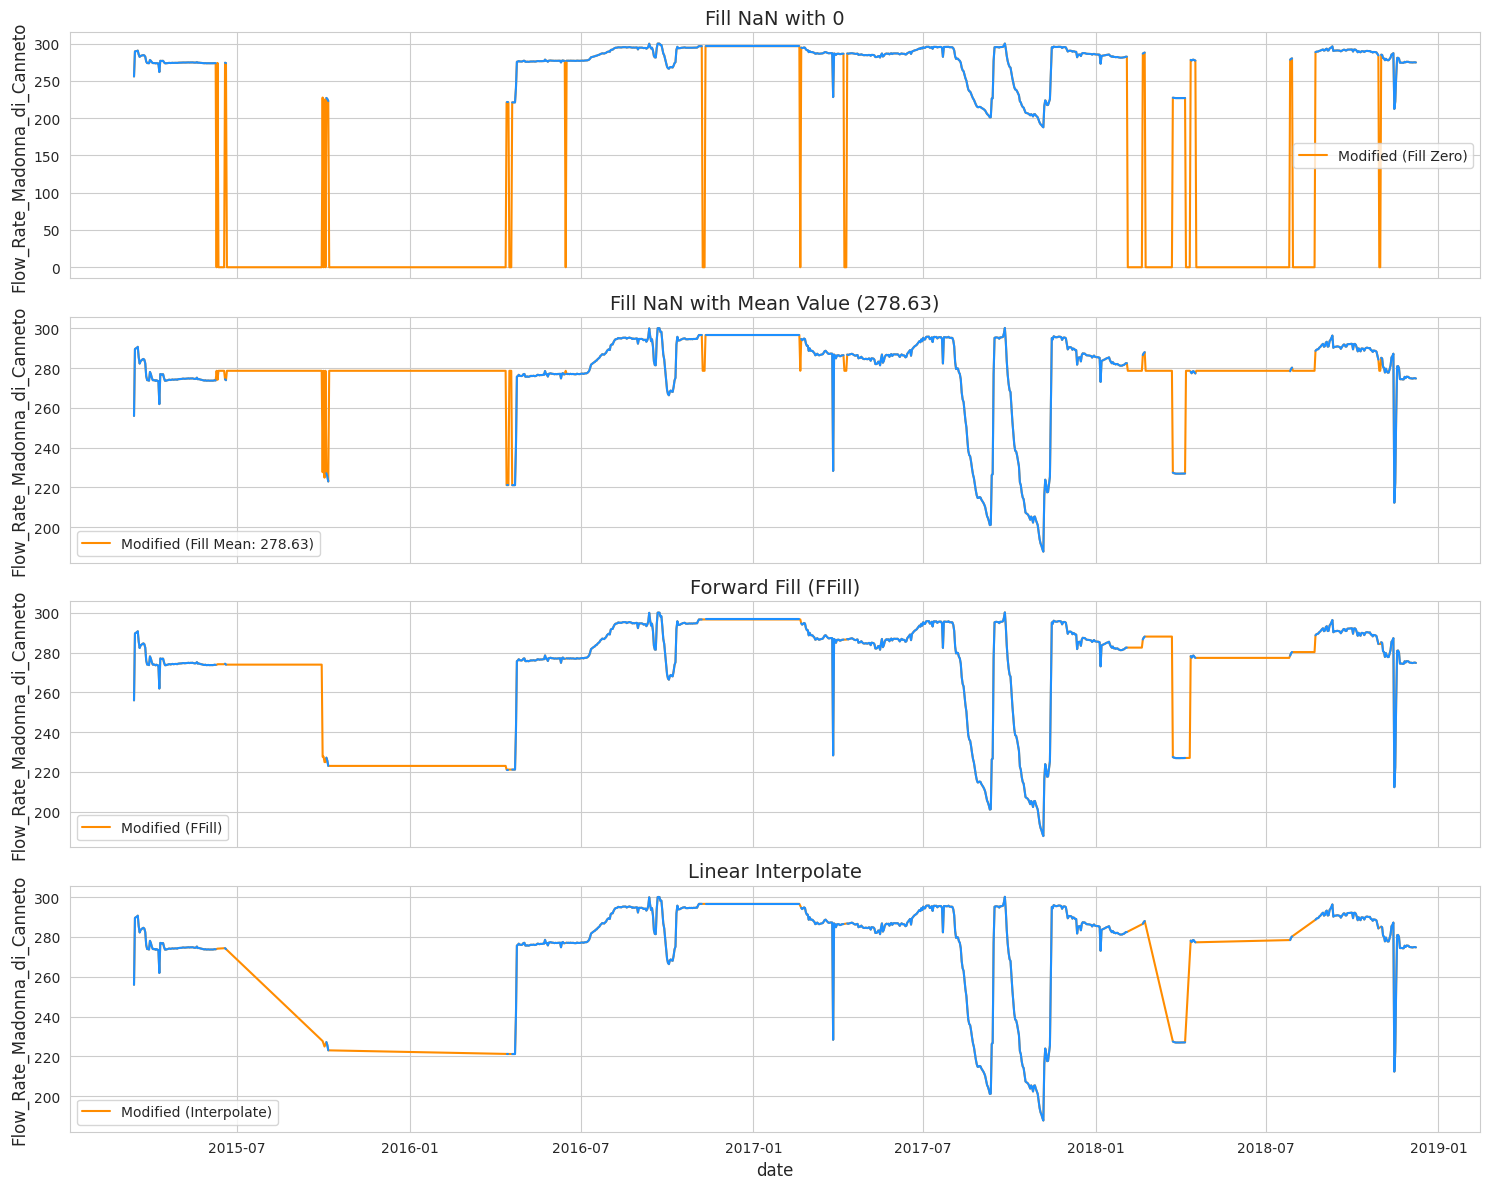

--- End of Visualization ---



In [189]:
missing_handler.visualize_imputation('Flow_Rate_Madonna_di_Canneto')

# M5 Demand

**Dataset Summary:**  
This dataset is part of the M5 Forecasting Competition, containing hierarchical sales data from Walmart across California, Texas, and Wisconsin. It includes time series data, prices, promotions, and events to forecast sales at various levels of aggregation.

### Features:
- **state, cat, dept, store, item:**  
  - **Date:** Date of observation.  
  - **wday:** Day of the week.  
  - **month, year:** Time-related features.  
  - **snap_CA, snap_TX, snap_WI:** Binary flags indicating SNAP purchases in each state.  
  - **event:** Special events or promotions (e.g., holidays, sales).  
  - **Sales:** Sales volume of items, departments, stores, or categories.  
  - **mean_price, median_price, min_price, max_price:** Price statistics for items, stores, or categories.  
  - **item_id, store_id:** Unique identifiers for items and stores.  
  - **sell_price:** Weekly average price for items.

**Source:** [Kaggle - M5 Forecasting Accuracy](https://www.kaggle.com/competitions/m5-forecasting-accuracy/data)

In [3]:
sell_prices = pd.read_csv(RAW_DATASETS_DIR + 'M5_Demand/sell_prices.csv')
sell_prices

,store_id,item_id,wm_yr_wk,sell_price
0,CA_1,HOBBIES_1_001,11325,9.58
1,CA_1,HOBBIES_1_001,11326,9.58
2,CA_1,HOBBIES_1_001,11327,8.26
3,CA_1,HOBBIES_1_001,11328,8.26
4,CA_1,HOBBIES_1_001,11329,8.26
...,...,...,...,...
6841116,WI_3,FOODS_3_827,11617,1.00
6841117,WI_3,FOODS_3_827,11618,1.00
6841118,WI_3,FOODS_3_827,11619,1.00
6841119,WI_3,FOODS_3_827,11620,1.00


In [4]:
calendar = pd.read_csv(RAW_DATASETS_DIR + 'M5_Demand/calendar.csv')
calendar

,date,wm_yr_wk,weekday,wday,month,year,d,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI
0,2011-01-29,11101,Saturday,1,1,2011,d_1,NaN,NaN,NaN,NaN,0,0,0
1,2011-01-30,11101,Sunday,2,1,2011,d_2,NaN,NaN,NaN,NaN,0,0,0
2,2011-01-31,11101,Monday,3,1,2011,d_3,NaN,NaN,NaN,NaN,0,0,0
3,2011-02-01,11101,Tuesday,4,2,2011,d_4,NaN,NaN,NaN,NaN,1,1,0
4,2011-02-02,11101,Wednesday,5,2,2011,d_5,NaN,NaN,NaN,NaN,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1964,2016-06-15,11620,Wednesday,5,6,2016,d_1965,NaN,NaN,NaN,NaN,0,1,1
1965,2016-06-16,11620,Thursday,6,6,2016,d_1966,NaN,NaN,NaN,NaN,0,0,0
1966,2016-06-17,11620,Friday,7,6,2016,d_1967,NaN,NaN,NaN,NaN,0,0,0
1967,2016-06-18,11621,Saturday,1,6,2016,d_1968,NaN,NaN,NaN,NaN,0,0,0


In [5]:
event_columns = ["event_name_1", "event_name_2"]
calendar['is_event'] = calendar[event_columns].notnull().sum(axis=1).astype(int)
calendar = calendar.drop(columns=['weekday', 'wday', 'month', 'year', 'event_name_1', 'event_type_1', 'event_name_2', 'event_type_2'])
calendar = calendar.fillna('none')
calendar

,date,wm_yr_wk,d,snap_CA,snap_TX,snap_WI,is_event
0,2011-01-29,11101,d_1,0,0,0,0
1,2011-01-30,11101,d_2,0,0,0,0
2,2011-01-31,11101,d_3,0,0,0,0
3,2011-02-01,11101,d_4,1,1,0,0
4,2011-02-02,11101,d_5,1,0,1,0
...,...,...,...,...,...,...,...
1964,2016-06-15,11620,d_1965,0,1,1,0
1965,2016-06-16,11620,d_1966,0,0,0,0
1966,2016-06-17,11620,d_1967,0,0,0,0
1967,2016-06-18,11621,d_1968,0,0,0,0


In [6]:
calendar.describe()

,wm_yr_wk,snap_CA,snap_TX,snap_WI,is_event
count,1969.000000,1969.000000,1969.000000,1969.000000,1969.000000
mean,11347.086338,0.330117,0.330117,0.330117,0.084815
std,155.277043,0.470374,0.470374,0.470374,0.287649
min,11101.000000,0.000000,0.000000,0.000000,0.000000
25%,11219.000000,0.000000,0.000000,0.000000,0.000000
50%,11337.000000,0.000000,0.000000,0.000000,0.000000
75%,11502.000000,1.000000,1.000000,1.000000,0.000000
max,11621.000000,1.000000,1.000000,1.000000,2.000000


In [7]:
train_eval = pd.read_csv(RAW_DATASETS_DIR + 'M5_Demand/sales_train_evaluation.csv')
train_eval

,id,item_id,dept_id,cat_id,store_id,state_id,d_1,d_2,d_3,d_4,...,d_1932,d_1933,d_1934,d_1935,d_1936,d_1937,d_1938,d_1939,d_1940,d_1941
0,HOBBIES_1_001_CA_1_evaluation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,2,4,0,0,0,0,3,3,0,1
1,HOBBIES_1_002_CA_1_evaluation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,0,1,2,1,1,0,0,0,0,0
2,HOBBIES_1_003_CA_1_evaluation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,1,0,2,0,0,0,2,3,0,1
3,HOBBIES_1_004_CA_1_evaluation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,1,1,0,4,0,1,3,0,2,6
4,HOBBIES_1_005_CA_1_evaluation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,0,0,0,2,1,0,0,2,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30485,FOODS_3_823_WI_3_evaluation,FOODS_3_823,FOODS_3,FOODS,WI_3,WI,0,0,2,2,...,1,0,3,0,1,1,0,0,1,1
30486,FOODS_3_824_WI_3_evaluation,FOODS_3_824,FOODS_3,FOODS,WI_3,WI,0,0,0,0,...,0,0,0,0,0,0,1,0,1,0
30487,FOODS_3_825_WI_3_evaluation,FOODS_3_825,FOODS_3,FOODS,WI_3,WI,0,6,0,2,...,0,0,1,2,0,1,0,1,0,2
30488,FOODS_3_826_WI_3_evaluation,FOODS_3_826,FOODS_3,FOODS,WI_3,WI,0,0,0,0,...,1,1,1,4,6,0,1,1,1,0


In [8]:
print(train_eval['state_id'].nunique())
print(train_eval['store_id'].nunique())
print(train_eval['cat_id'].nunique())
print(train_eval['dept_id'].nunique())
print(train_eval['item_id'].nunique())
print(train_eval['id'].nunique())

3
10
3
7
3049
30490


In [ ]:
# set seed for random for reproducibility
random.seed(42)

def reaggregate_m5(column):
    if column == 'item_id':
        random_items = random.sample(list(train_eval['item_id'].unique()), 100)
        df = train_eval[train_eval['item_id'].isin(random_items)]
    elif column == 'id':
        random_ids = random.sample(list(train_eval['id'].unique()), 500)
        df = train_eval[train_eval['id'].isin(random_ids)]
        df_melted = df.melt(
            id_vars=["store_id", "item_id", column],
            value_vars=[col for col in df.columns if col.startswith("d_")],
            var_name="day",
            value_name="sales"
        )
        df_grouped = df_melted.groupby(["day", "store_id", "item_id", column], as_index=False)["sales"].sum()
        return df_grouped
    else:
        df = train_eval

    df_melted = df.melt(
        id_vars=[column],
        value_vars=[col for col in df.columns if col.startswith("d_")],
        var_name="day",
        value_name="sales"
    )
    
    df_grouped = df_melted.groupby(["day", column], as_index=False)["sales"].sum()
    return df_grouped

In [22]:
df_state = reaggregate_m5('state_id')
print(df_state.shape)
df_store = reaggregate_m5('store_id')
print(df_store.shape)
df_cat = reaggregate_m5('cat_id')
print(df_cat.shape)
df_dept = reaggregate_m5('dept_id')
print(df_dept.shape)
df_item = reaggregate_m5('item_id')
print(df_item.shape)
df_id = reaggregate_m5('id')
print(df_id.shape)

KeyboardInterrupt: 

In [11]:
df_state = df_state.rename(columns={'state_id': 'ts'})
df_store = df_store.rename(columns={'store_id': 'ts'})
df_cat = df_cat.rename(columns={'cat_id': 'ts'})
df_dept = df_dept.rename(columns={'dept_id': 'ts'})
df_item = df_item.rename(columns={'item_id': 'ts'})
df_other  = pd.concat([df_state, df_store, df_cat, df_dept, df_item], axis=0)
df_other.shape

(238743, 3)

In [12]:
df_other = pd.merge(df_other, calendar, left_on="day", right_on="d", how="left").drop(columns=["d", "day", "wm_yr_wk"])
df_id = pd.merge(df_id, calendar, left_on="day", right_on="d", how="left").drop(columns=["d", "day"])

In [13]:
df_id = pd.merge(df_id, sell_prices, on=["wm_yr_wk", "store_id", "item_id"], how="left").drop(columns=['item_id', 'store_id', "wm_yr_wk"])

In [14]:
ids_with_missing = df_id[df_id['sell_price'].isna()]['id'].unique()
df_id = df_id[~df_id['id'].isin(ids_with_missing)]

In [15]:
def sort_date(df):
    dt_df = df.copy()
    dt_df['date'] = pd.to_datetime(dt_df['date'])
    dt_df = dt_df.sort_values(by='date')
    dt_df['date'] = dt_df['date'].dt.strftime('%Y-%m-%d')
    return dt_df

In [16]:
df_other = sort_date(df_other)
df_id = sort_date(df_id)

In [17]:
df_id

,id,sales,date,snap_CA,snap_TX,snap_WI,is_event,sell_price
0,FOODS_1_049_CA_1_evaluation,10,2011-01-29,0,0,0,0,2.18
320,HOUSEHOLD_1_203_TX_3_evaluation,4,2011-01-29,0,0,0,0,4.97
325,HOUSEHOLD_1_516_TX_3_evaluation,5,2011-01-29,0,0,0,0,1.98
326,HOUSEHOLD_2_037_TX_3_evaluation,1,2011-01-29,0,0,0,0,10.27
327,HOUSEHOLD_2_054_TX_3_evaluation,0,2011-01-29,0,0,0,0,4.47
...,...,...,...,...,...,...,...,...
523827,HOUSEHOLD_2_054_TX_3_evaluation,0,2016-05-22,0,0,0,0,4.87
523826,HOUSEHOLD_2_037_TX_3_evaluation,0,2016-05-22,0,0,0,0,11.84
523825,HOUSEHOLD_1_516_TX_3_evaluation,5,2016-05-22,0,0,0,0,1.87
523819,HOUSEHOLD_1_192_TX_3_evaluation,0,2016-05-22,0,0,0,0,3.62


In [18]:
df_other

,ts,sales,date,snap_CA,snap_TX,snap_WI,is_event
0,CA,14195,2011-01-29,0,0,0,0
44728,HOUSEHOLD_2_100,0,2011-01-29,0,0,0,0
44727,HOUSEHOLD_2_077,0,2011-01-29,0,0,0,0
44726,HOUSEHOLD_2_068,6,2011-01-29,0,0,0,0
44725,HOUSEHOLD_2_023,0,2011-01-29,0,0,0,0
...,...,...,...,...,...,...,...
149354,FOODS_2_017,2,2016-05-22,0,0,0,0
149351,FOODS_1_131,2,2016-05-22,0,0,0,0
149350,FOODS_1_088,31,2016-05-22,0,0,0,0
149366,FOODS_2_393,2,2016-05-22,0,0,0,0


In [19]:
df_other = df_other.rename(columns={'ts': 'ts_name'})
df_id = df_id.rename(columns={'id': 'ts_name'})

In [20]:
df_other.to_csv('m5_other.csv', index=False)
df_id.to_csv('m5_id.csv', index=False)

In [206]:
dataset_info.add_dataset('m5_other', 'demand', df_other, ['sales'], future_covariates=['snap_CA', 'snap_TX', 'snap_WI', 'is_event'], categorical_covariates=['snap_CA', 'snap_TX', 'snap_WI', 'is_event'], ts_name_col='ts')
dataset_info.add_dataset('m5_id', 'demand', df_id, ['sales'], future_covariates=['sell_price', 'snap_CA', 'snap_TX', 'snap_WI', 'is_event'], categorical_covariates=['snap_CA', 'snap_TX', 'snap_WI', 'is_event'], ts_name_col='id')

Processed DataFrame saved to: /workspaces/foundation-covariate-forecasting/data/prepared_datasets/m5_other.csv
Processed DataFrame saved to: /workspaces/foundation-covariate-forecasting/data/prepared_datasets/m5_id.csv


,dataset_name,domain,granularity,ts_length,num_ts,ts_names,targets,num_targets,past_covariates,num_past_covariates,future_covariates,num_future_covariates,categorical_covariates,num_categorical_covariates
23,arno,nature,D,1283,1,[_single_series_],[Hydrometry_Nave_di_Rosano],1,"[Rainfall_Bibbiena, Rainfall_Camaldoli, Rainfa...",15,[],0,[],0
24,amiata,nature,D,1618,1,[_single_series_],"[Flow_Rate_Arbure, Flow_Rate_Bugnano, Flow_Rat...",4,"[Depth_to_Groundwater_David_Lazzaretti, Depth_...",11,[],0,[],0
25,lupa,nature,D,4150,1,[_single_series_],[Flow_Rate_Lupa],1,[Rainfall_Terni],1,[],0,[],0
26,m5_other,demand,D,1941,123,"[CA, CA_1, CA_2, CA_3, CA_4, FOODS, FOODS_1, F...",[sales],1,[],0,"[snap_CA, snap_TX, snap_WI, is_event]",4,"[snap_CA, snap_TX, snap_WI, is_event]",4
27,m5_id,demand,D,1941,185,"[FOODS_1_026_TX_3_evaluation, FOODS_1_030_TX_3...",[sales],1,[],0,"[sell_price, snap_CA, snap_TX, snap_WI, is_event]",5,"[snap_CA, snap_TX, snap_WI, is_event]",4


# Demo Demand

prognostica internal demand demo dataset

In [207]:
df = pd.read_csv(RAW_DATASETS_DIR + 'Demo_Data/TSDATA_071024.csv', sep=';')
ind = pd.read_csv(RAW_DATASETS_DIR + 'Demo_Data/INDDATA_REFORMATTED.csv', sep=';')
df

,DATASET,LEVEL1,LEVEL2,LEVEL3,MATERIAL,DATE,ACTUAL
0,DEMO,G001,PF_K,PF_K41,C011414575,01.10.2007,52
1,DEMO,G001,PF_K,PF_K41,C011414575,01.11.2007,39
2,DEMO,G001,PF_K,PF_K41,C011414575,01.12.2007,28
3,DEMO,G001,PF_K,PF_K41,C011414575,01.01.2008,26
4,DEMO,G001,PF_K,PF_K41,C011414575,01.02.2008,13
...,...,...,...,...,...,...,...
15998,DEMO,G001,PF_O,PF_O58,C010887783,01.02.2024,60
15999,DEMO,G001,PF_O,PF_O58,C010887783,01.03.2024,60
16000,DEMO,G001,PF_O,PF_O58,C010887783,01.04.2024,60
16001,DEMO,G001,PF_O,PF_O58,C010887783,01.05.2024,60


In [208]:
df.drop(columns=['DATASET'], inplace=True)
print(df['LEVEL1'].nunique())
print(df['LEVEL2'].nunique())
print(df['LEVEL3'].nunique())
print(df['MATERIAL'].nunique())
print(df['DATE'].nunique())

2
15
50
100
201


In [209]:
df.drop(columns=['LEVEL1', 'LEVEL2', 'LEVEL3'], inplace=True)
df.rename(columns={'DATE': 'date'}, inplace=True)
df['date'] = pd.to_datetime(df['date'], format='%d.%m.%Y')

In [210]:
df

,MATERIAL,date,ACTUAL
0,C011414575,2007-10-01,52
1,C011414575,2007-11-01,39
2,C011414575,2007-12-01,28
3,C011414575,2008-01-01,26
4,C011414575,2008-02-01,13
...,...,...,...
15998,C010887783,2024-02-01,60
15999,C010887783,2024-03-01,60
16000,C010887783,2024-04-01,60
16001,C010887783,2024-05-01,60


In [211]:
# Filter out materials with less than 120 rows
material_counts = df['MATERIAL'].value_counts()
materials_to_keep = material_counts[material_counts >= 120].index
df = df[df['MATERIAL'].isin(materials_to_keep)]
df

,MATERIAL,date,ACTUAL
0,C011414575,2007-10-01,52
1,C011414575,2007-11-01,39
2,C011414575,2007-12-01,28
3,C011414575,2008-01-01,26
4,C011414575,2008-02-01,13
...,...,...,...
15998,C010887783,2024-02-01,60
15999,C010887783,2024-03-01,60
16000,C010887783,2024-04-01,60
16001,C010887783,2024-05-01,60


In [212]:
df['MATERIAL'].value_counts()

MATERIAL
C011414575    201
C047609358    201
C027992555    201
C028950431    201
C028953647    201
             ... 
C010825983    143
C018904994    140
C015915412    140
C000922852    122
C023055773    121
Name: count, Length: 72, dtype: int64

In [213]:
min_date = df[df['MATERIAL'] == 'C023055773']['date'].min()
# drop rows with date before min_date
df = df[df['date'] >= min_date]

In [214]:
df

,MATERIAL,date,ACTUAL
80,C011414575,2014-06-01,65
81,C011414575,2014-07-01,39
82,C011414575,2014-08-01,26
83,C011414575,2014-09-01,52
84,C011414575,2014-10-01,52
...,...,...,...
15998,C010887783,2024-02-01,60
15999,C010887783,2024-03-01,60
16000,C010887783,2024-04-01,60
16001,C010887783,2024-05-01,60


In [215]:
ind['date'] = pd.to_datetime(ind['DATE'])
ind.drop(columns=['DATE'], inplace=True)
ind = ind.pivot(index='date', columns='INDIKATOR', values='VALUES')
ind.reset_index(inplace=True)
ind

INDIKATOR,date,Europe..Business.confidence.index,Europe..Consumer.confidence.index,Germany..Business.confidence.index,Germany..Composite.leading.indicator,Germany..Consumer.confidence.index,Global..Business.confidence.index,Global..Consumer.confidence.index
0,2000-01-01,101.5,102.8,100.3,101.4,100.6,100.8,102.3
1,2000-02-01,101.7,102.8,100.5,101.6,100.7,100.8,102.4
2,2000-03-01,102.0,102.8,100.6,101.8,100.7,100.9,102.3
3,2000-04-01,102.2,102.8,100.7,102.0,100.8,100.9,102.3
4,2000-05-01,102.3,102.7,100.8,102.1,100.9,100.8,102.3
...,...,...,...,...,...,...,...,...
288,2024-01-01,99.2,98.4,98.9,99.3,98.6,99.4,99.0
289,2024-02-01,99.2,98.6,98.8,99.5,98.8,99.5,99.2
290,2024-03-01,99.1,98.7,98.8,99.7,99.1,99.5,99.3
291,2024-04-01,99.1,98.8,98.8,100.0,99.5,99.6,99.2


In [216]:
df = pd.merge(df, ind, 'left', 'date')

In [217]:
df.dropna(axis=0, inplace=True)

In [218]:
df.shape

(8640, 10)

In [219]:
df.columns

Index(['MATERIAL', 'date', 'ACTUAL', 'Europe..Business.confidence.index',
       'Europe..Consumer.confidence.index',
       'Germany..Business.confidence.index',
       'Germany..Composite.leading.indicator',
       'Germany..Consumer.confidence.index',
       'Global..Business.confidence.index',
       'Global..Consumer.confidence.index'],
      dtype='object')

In [220]:
dataset_info.add_dataset('demo', 'demand', df, ['ACTUAL'], ts_name_col='MATERIAL')

Processed DataFrame saved to: /workspaces/foundation-covariate-forecasting/data/prepared_datasets/demo.csv


,dataset_name,domain,granularity,ts_length,num_ts,ts_names,targets,num_targets,past_covariates,num_past_covariates,future_covariates,num_future_covariates,categorical_covariates,num_categorical_covariates
24,amiata,nature,D,1618,1,[_single_series_],"[Flow_Rate_Arbure, Flow_Rate_Bugnano, Flow_Rat...",4,"[Depth_to_Groundwater_David_Lazzaretti, Depth_...",11,[],0,[],0
25,lupa,nature,D,4150,1,[_single_series_],[Flow_Rate_Lupa],1,[Rainfall_Terni],1,[],0,[],0
26,m5_other,demand,D,1941,123,"[CA, CA_1, CA_2, CA_3, CA_4, FOODS, FOODS_1, F...",[sales],1,[],0,"[snap_CA, snap_TX, snap_WI, is_event]",4,"[snap_CA, snap_TX, snap_WI, is_event]",4
27,m5_id,demand,D,1941,185,"[FOODS_1_026_TX_3_evaluation, FOODS_1_030_TX_3...",[sales],1,[],0,"[sell_price, snap_CA, snap_TX, snap_WI, is_event]",5,"[snap_CA, snap_TX, snap_WI, is_event]",4
28,demo,demand,MS,120,72,"[C000057820, C000855426, C000922852, C00095756...",[ACTUAL],1,"[Europe..Business.confidence.index, Europe..Co...",7,[],0,[],0


# Datasets Overview

In [221]:
dataset_info.store()
# dataset_info.load()

Dataset info stored to: /workspaces/foundation-covariate-forecasting/data/dataset_info.csv


In [222]:
dataset_info.dataset_info_df

,dataset_name,domain,granularity,ts_length,num_ts,ts_names,targets,num_targets,past_covariates,num_past_covariates,future_covariates,num_future_covariates,categorical_covariates,num_categorical_covariates
0,housing,economic,QS-OCT,74,1,[_single_series_],"[CSUSHPISA, MSPUS]",2,"[EVACANTUSQ176N, GDP, INTDSRUSM193N, MORTGAGE3...",8,[],0,[],0
1,electricity,energy,D,2106,1,[_single_series_],"[RRP, demand]",2,"[RRP_negative, RRP_positive, demand_neg_RRP, d...",9,"[school_day, holiday]",2,"[school_day, holiday]",2
2,bike_sharing,human,h,8760,1,[_single_series_],[Rented Bike Count],1,"[Dew point temperature(°C), Humidity(%), Rainf...",8,"[Seasons, Holiday, Functioning Day]",3,"[Seasons, Holiday, Functioning Day]",3
3,energy,energy,h,30233,1,[_single_series_],"[price_actual, total_load_actual]",2,"[generation_biomass, generation_fossil_brown_c...",20,"[price_day_ahead, total_load_forecast, forecas...",4,[],0
4,bitcoin,economic,D,2659,1,[_single_series_],[price],1,"[active_addresses, av_transaction_value, block...",17,[],0,[],0
5,air_quality,nature,h,10898,35,"[aotizhongxin_aq, badaling_aq, beibuxinqu_aq, ...","[CO, NO2, O3, SO2]",4,"[PM10, PM2.5]",2,[],0,[],0
6,etth,energy,h,17420,2,"[one, two]",[OT],1,"[HUFL, HULL, LUFL, LULL, MUFL, MULL]",6,[],0,[],0
7,household_power_consumption,energy,h,16758,1,[_single_series_],"[Global_active_power, Global_reactive_power]",2,"[Global_intensity, Sub_metering_1, Sub_meterin...",5,[],0,[],0
8,stackoverflow,human,MS,132,1,[_single_series_],"[AllenNLP, Dask, apache-spark, deep-learning, ...",30,"[Apache, Apache-spark-mlib, BeautifulSoup, Col...",50,[],0,[],0
9,covid,human,D,188,187,"[Afghanistan, Albania, Algeria, Andorra, Angol...","[Active, Deaths]",2,"[Confirmed, Recovered]",2,[],0,[],0


In [223]:
df = dataset_info.dataset_info_df.copy()
df['total_ts'] = df['num_ts'] * df['num_targets']
df['total_ts'].sum()

1492

In [225]:
df['total_cov'] = df['num_past_covariates'] + df['num_future_covariates']
df['total_cov'].sum()

341

In [226]:
df.groupby('domain')['total_ts'].sum()

domain
demand      380
economic      3
energy       10
human       882
nature      217
Name: total_ts, dtype: object

In [227]:
df.groupby('granularity')['total_ts'].sum()

granularity
D         754
MS        102
QS-OCT      2
W-TUE       3
h         631
Name: total_ts, dtype: object

In [228]:
int_vars = ['ts_length', 'num_ts', 'num_targets', 'num_past_covariates', 'num_future_covariates', 'num_categorical_covariates', 'total_ts', 'total_cov']
for var in int_vars:
    df[var] = df[var].astype(int)
df[int_vars].describe()

,ts_length,num_ts,num_targets,num_past_covariates,num_future_covariates,num_categorical_covariates,total_ts,total_cov
count,29.000000,29.000000,29.000000,29.000000,29.000000,29.000000,29.000000,29.000000
mean,11253.275862,29.551724,3.103448,11.000000,0.758621,1.103448,51.448276,11.758621
std,21768.280265,56.404525,5.459885,9.870591,1.503690,2.288868,108.211957,9.771150
min,74.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000
25%,541.000000,1.000000,1.000000,5.000000,0.000000,0.000000,2.000000,5.000000
50%,2659.000000,1.000000,2.000000,8.000000,0.000000,0.000000,3.000000,11.000000
75%,8760.000000,24.000000,3.000000,17.000000,0.000000,0.000000,30.000000,17.000000
max,100057.000000,187.000000,30.000000,50.000000,5.000000,8.000000,432.000000,50.000000
